# PROJET #02 — Segmentation des Clients d'une Banque Camerounaise
## ENSP Douala — Département Informatique SDIA — AD2 2025/2026
**Enseignant : M. FOTSO Valdez**

---
## SECTION 1 : Données & Analyse Exploratoire (EDA)
**Responsable : Personne A**

---
### Objectif de cette section
Cette section couvre la **phase EDA (Exploratory Data Analysis)** du pipeline de data science. L'objectif est de :
1. Charger et nettoyer le dataset brut (`Churn_Modelling.csv`)
2. Calculer les statistiques descriptives pour comprendre la structure des données
3. Visualiser les distributions et les corrélations entre variables
4. Identifier les variables les plus discriminantes pour prédire le churn
5. Exporter un dataset propre (`dataset_clean.csv`) pour la Personne B

**Dataset utilisé :** Kaggle — Bank Customer Churn Prediction  
**Source :** https://www.kaggle.com/datasets/shantanudhakadd/bank-customer-churn-prediction  
**Taille :** 10 000 clients × 14 variables

---
### 1.1 Importation des bibliothèques

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Configuration globale des figures
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

print('Bibliothèques importées avec succès')
print(f'   pandas {pd.__version__} | numpy {np.__version__}')

Bibliothèques importées avec succès
   pandas 2.3.3 | numpy 2.3.5


---
### 1.2 Chargement du Dataset

Le dataset contient l'historique de **10 000 clients** d'une banque avec 14 variables :
- **Variables d'identification** (inutiles) : RowNumber, CustomerId, Surname
- **Variables numériques** : CreditScore, Age, Tenure, Balance, NumOfProducts, EstimatedSalary
- **Variables catégorielles** : Geography, Gender
- **Variables binaires** : HasCrCard, IsActiveMember
- **Variable cible** : Exited (1 = a quitté la banque, 0 = reste)

In [2]:
# Chargement du dataset brut
df = pd.read_csv('Churn_Modelling.csv')

print(f'Shape du dataset : {df.shape[0]} lignes × {df.shape[1]} colonnes')
print(f'\nColonnes : {list(df.columns)}')
print(f'\nTypes de données :')
print(df.dtypes.to_string())
df.head(10)

Shape du dataset : 10000 lignes × 14 colonnes

Colonnes : ['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']

Types de données :
RowNumber            int64
CustomerId           int64
Surname             object
CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
5,6,15574012,Chu,645,Spain,Male,44,8,113755.78,2,1,0,149756.71,1
6,7,15592531,Bartlett,822,France,Male,50,7,0.00,2,1,1,10062.80,0
7,8,15656148,Obinna,376,Germany,Female,29,4,115046.74,4,1,0,119346.88,1
8,9,15792365,He,501,France,Male,44,4,142051.07,2,0,1,74940.50,0
9,10,15592389,H?,684,France,Male,27,2,134603.88,1,1,1,71725.73,0


---
### 1.3 Qualité des Données : Valeurs Manquantes & Doublons

Avant toute analyse, il est indispensable de vérifier la qualité du dataset.

In [3]:
# Vérification des valeurs manquantes
missing = df.isnull().sum()
print('=== Valeurs Manquantes par Colonne ===')
print(missing.to_string())
print(f'\nTotal valeurs manquantes : {missing.sum()}')

# Vérification des doublons
n_doublons = df.duplicated().sum()
print(f'\nNombre de doublons : {n_doublons}')

print('\n Dataset de bonne qualité : aucune valeur manquante ni doublon !')

=== Valeurs Manquantes par Colonne ===
RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0

Total valeurs manquantes : 0

Nombre de doublons : 0

 Dataset de bonne qualité : aucune valeur manquante ni doublon !


In [4]:
# Nettoyage : suppression des colonnes non discriminantes
df.drop_duplicates(inplace=True)
df_clean = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

print(f'Colonnes supprimées : RowNumber, CustomerId, Surname')
print(f'Justification : Ces colonnes sont des identifiants sans valeur prédictive')
print(f'Shape après nettoyage : {df_clean.shape}')
df_clean.head()

Colonnes supprimées : RowNumber, CustomerId, Surname
Justification : Ces colonnes sont des identifiants sans valeur prédictive
Shape après nettoyage : (10000, 11)


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


---
### 1.4 Statistiques Descriptives

Les statistiques descriptives permettent de comprendre la distribution de chaque variable, détecter les valeurs extrêmes (outliers) et comprendre l'ordre de grandeur des données.

In [5]:
# Statistiques descriptives complètes
print('=== Statistiques Descriptives — Variables Numériques ===')
df_clean.describe().round(2)

=== Statistiques Descriptives — Variables Numériques ===


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.0
mean,650.53,38.92,5.01,76485.89,1.53,0.71,0.52,100090.24,0.2
std,96.65,10.49,2.89,62397.41,0.58,0.46,0.50,57510.49,0.4
min,350.00,18.00,0.00,0.00,1.00,0.00,0.00,11.58,0.0
25%,584.00,32.00,3.00,0.00,1.00,0.00,0.00,51002.11,0.0
50%,652.00,37.00,5.00,97198.54,1.00,1.00,1.00,100193.92,0.0
75%,718.00,44.00,7.00,127644.24,2.00,1.00,1.00,149388.25,0.0
max,850.00,92.00,10.00,250898.09,4.00,1.00,1.00,199992.48,1.0


In [6]:
# Analyse de la variable cible (Exited = Churn)
taux_churn = df_clean['Exited'].mean()
print('=== Analyse de la Variable Cible : Exited (Churn) ===')
print(f'\nDistribution des classes :')
print(df_clean['Exited'].value_counts().to_string())
print(f'\nTaux de churn global : {taux_churn:.2%}')
print(f'  → {df_clean["Exited"].sum()} clients ont quitté la banque')
print(f'  → {(df_clean["Exited"]==0).sum()} clients sont restés fidèles')
print(f'\n  Déséquilibre de classes détecté : 80% fidèles vs 20% churn')
print(f'    La Personne B (pretraitement) devra appliquer SMOTE pour rééquilibrer.')

=== Analyse de la Variable Cible : Exited (Churn) ===

Distribution des classes :
Exited
0    7963
1    2037

Taux de churn global : 20.37%
  → 2037 clients ont quitté la banque
  → 7963 clients sont restés fidèles

  Déséquilibre de classes détecté : 80% fidèles vs 20% churn
    La Personne B (pretraitement) devra appliquer SMOTE pour rééquilibrer.


In [7]:
# Variables catégorielles
print('=== Variables Catégorielles ===')
for col in ['Geography', 'Gender']:
    print(f'\n{col} :')
    counts = df_clean[col].value_counts()
    pct = df_clean[col].value_counts(normalize=True) * 100
    print(pd.DataFrame({'Effectif': counts, 'Pourcentage (%)': pct.round(1)}).to_string())

=== Variables Catégorielles ===

Geography :
           Effectif  Pourcentage (%)
Geography                           
France         5014             50.1
Germany        2509             25.1
Spain          2477             24.8

Gender :
        Effectif  Pourcentage (%)
Gender                           
Male        5457             54.6
Female      4543             45.4


In [8]:
# Tableau comparatif des moyennes par statut churn
print('=== Moyennes des Variables selon le Statut Churn ===')
tableau_churn = df_clean.groupby('Exited')[['CreditScore','Age','Tenure','Balance','NumOfProducts','EstimatedSalary']].mean().round(2)
tableau_churn.index = ['Non-Churn (Exited=0)', 'Churn (Exited=1)']
tableau_churn

=== Moyennes des Variables selon le Statut Churn ===


,CreditScore,Age,Tenure,Balance,NumOfProducts,EstimatedSalary
Non-Churn (Exited=0),651.85,37.41,5.03,72745.30,1.54,99738.39
Churn (Exited=1),645.35,44.84,4.93,91108.54,1.48,101465.68


** Observations du tableau comparatif :**
- Les clients qui churne sont en moyenne **7 ans plus âgés** (44.8 vs 37.4 ans)
- Le **solde bancaire (Balance)** est plus élevé chez les clients qui partent (+18 000)
- Le **CreditScore** est légèrement inférieur chez les clients churners
- Le **nombre de produits** ne diffère pas significativement entre les deux groupes
- Le **salaire estimé** est similaire entre les deux groupes → faible pouvoir discriminant

---
### 1.5 Visualisations EDA

#### Figure 1 : Distributions des Variables Numériques

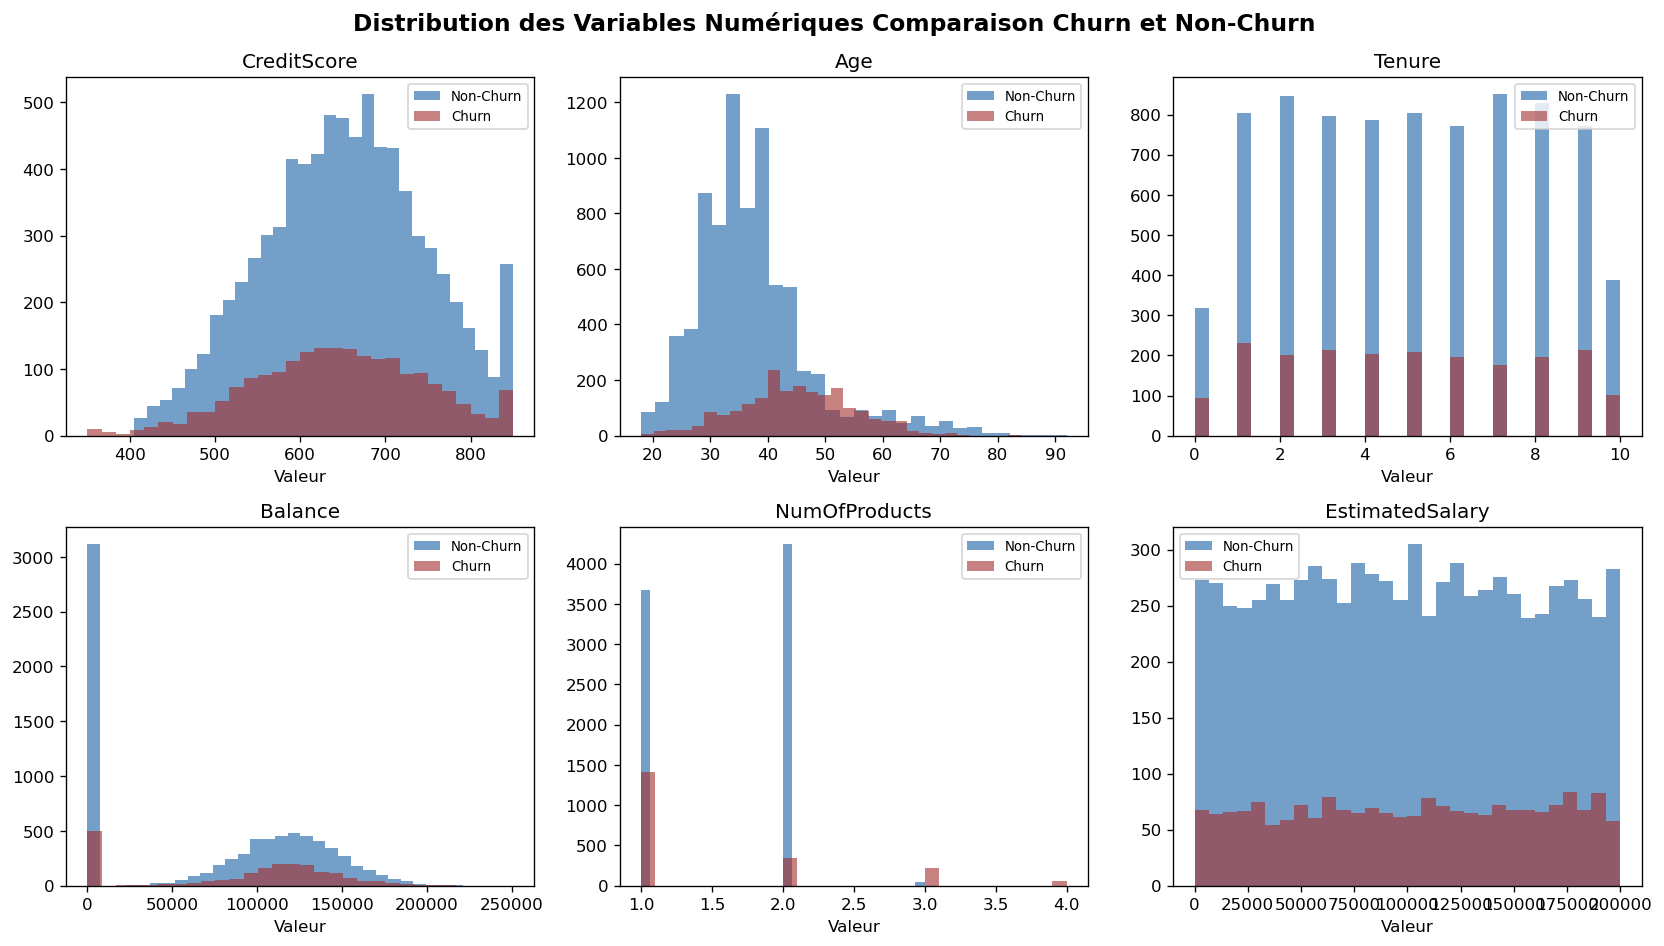

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('Distribution des Variables Numériques Comparaison Churn et Non-Churn', fontsize=14, fontweight='bold')

num_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']
for ax, col in zip(axes.flatten(), num_cols):
    ax.hist(df_clean[df_clean['Exited']==0][col], bins=30, alpha=0.6, color='#185FA5', label='Non-Churn')
    ax.hist(df_clean[df_clean['Exited']==1][col], bins=30, alpha=0.6, color='#A32D2D', label='Churn')
    ax.set_title(col); ax.set_xlabel('Valeur'); ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('figures/fig1_distributions_numeriques.png', dpi=150, bbox_inches='tight')
plt.show()

**  Interprétation Figure 1 :**
- **Age** : Les churners ont une distribution décalée vers les âges plus élevés (40-60 ans). C'est la variable la plus visuellement discriminante.
- **Balance** : Pic important à 0 pour les non-churners. Les churners ont plus souvent un solde positif.
- **CreditScore** : Distributions très similaires → faible pouvoir discriminant individuel.
- **Tenure** : Répartition quasi-uniforme pour les deux groupes.
- **NumOfProducts** : La majorité a 1-2 produits. Les clients avec 3-4 produits sont rares mais présentent un churn massif.
- **EstimatedSalary** : Distributions presque identiques → variable peu discriminante.

#### Figure 2 : Boxplots par Statut Churn

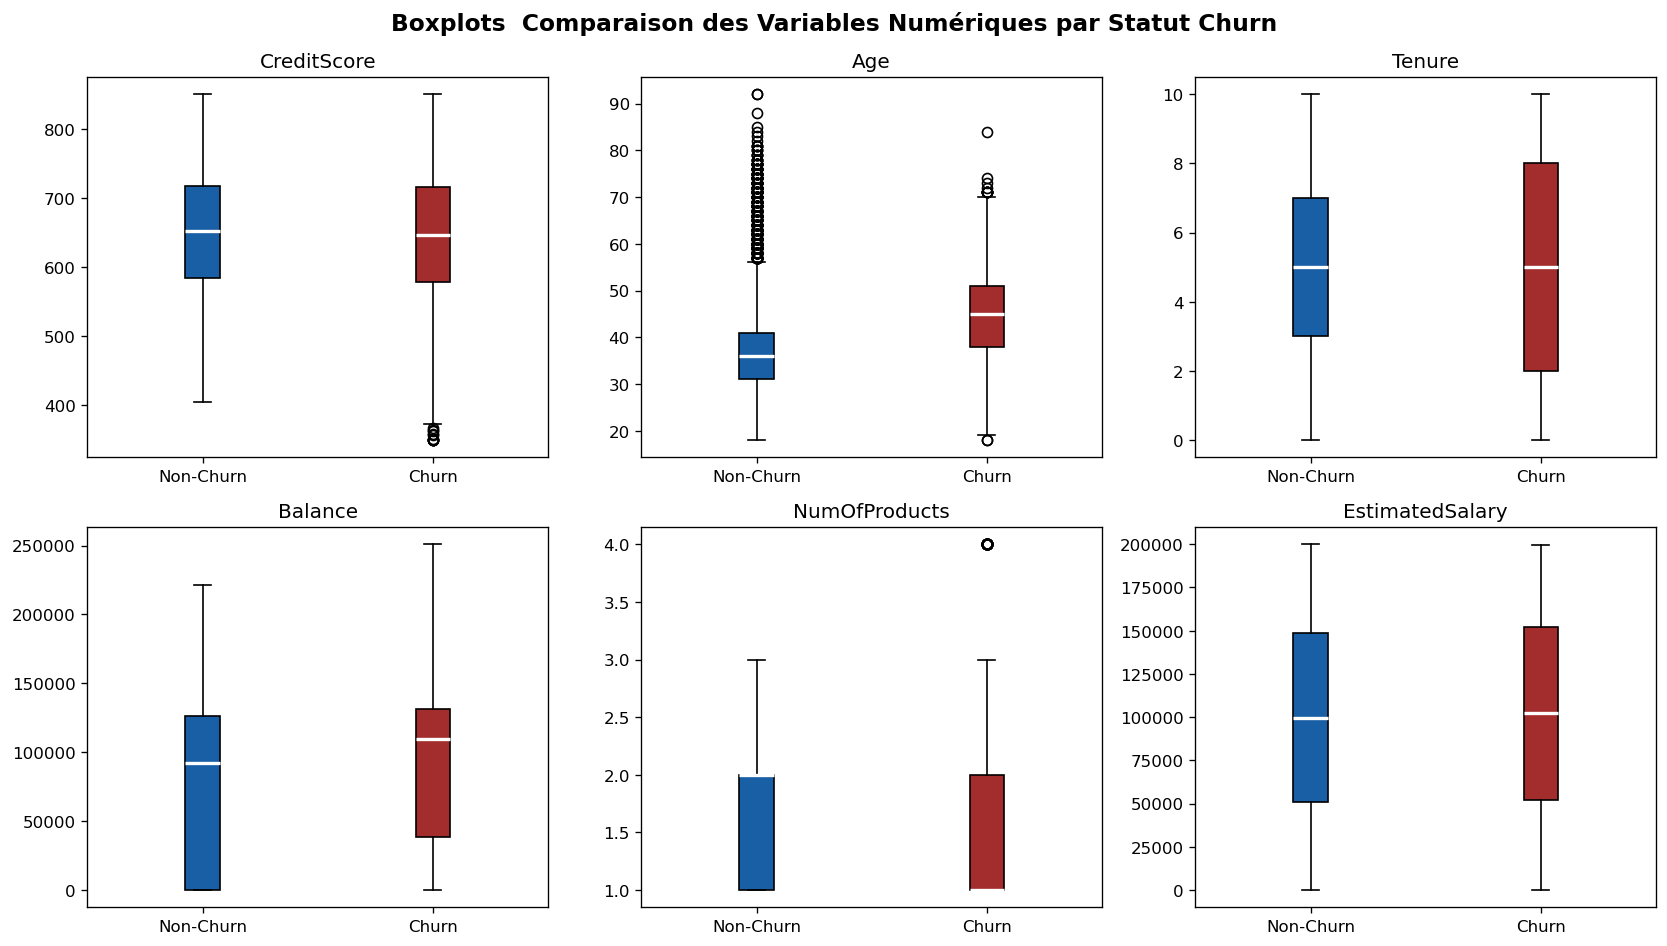

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('Boxplots  Comparaison des Variables Numériques par Statut Churn', fontsize=14, fontweight='bold')

for ax, col in zip(axes.flatten(), num_cols):
    data_0 = df_clean[df_clean['Exited']==0][col]
    data_1 = df_clean[df_clean['Exited']==1][col]
    bp = ax.boxplot([data_0, data_1], patch_artist=True, labels=['Non-Churn', 'Churn'],
                    medianprops=dict(color='white', linewidth=2))
    bp['boxes'][0].set_facecolor('#185FA5')
    bp['boxes'][1].set_facecolor('#A32D2D')
    ax.set_title(col)

plt.tight_layout()
plt.savefig('figures/fig2_boxplots_churn.png', dpi=150, bbox_inches='tight')
plt.show()

**Interprétation Figure 2 :**
- **Age** : La médiane des churners (~45 ans) est nettement supérieure à celle des non-churners (~36 ans). Différence statistiquement significative.
- **Balance** : La médiane des churners est ~3× supérieure. Les clients avec un solde élevé semblent insatisfaits du service.
- **NumOfProducts** : Distribution similaire, mais les valeurs extrêmes (3-4 produits) sont toutes dans le groupe churn.
- **Tenure & EstimatedSalary** : Distributions quasi-identiques — ces variables n'aident pas à discriminer.

#### Figure 3 : Matrice de Corrélation

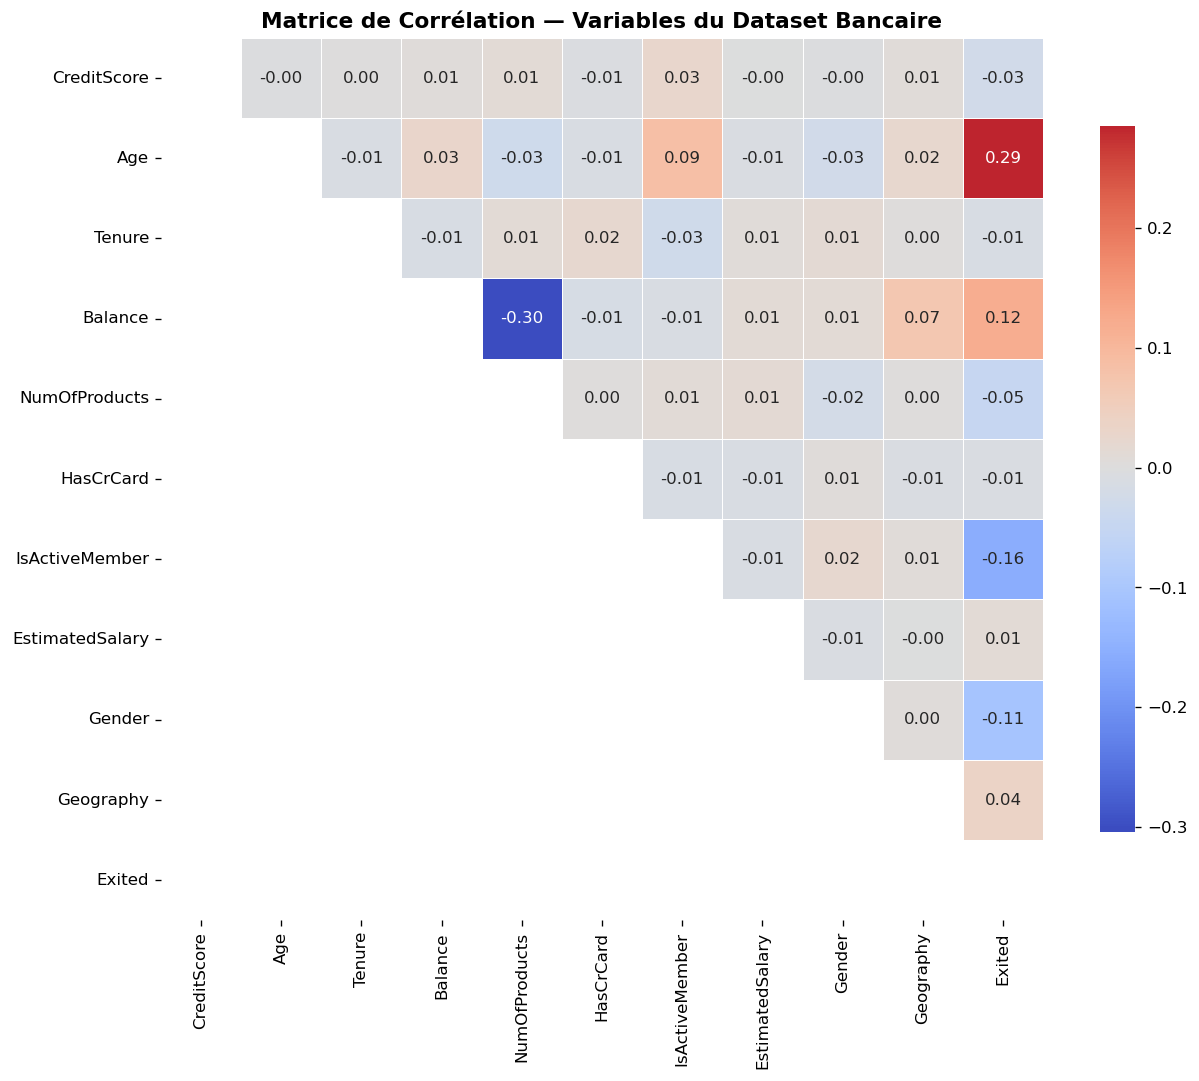

In [11]:
df_corr = df_clean.copy()
df_corr['Gender'] = (df_corr['Gender'] == 'Male').astype(int)
df_corr['Geography'] = df_corr['Geography'].map({'France': 0, 'Germany': 1, 'Spain': 2})
corr_cols = ['CreditScore','Age','Tenure','Balance','NumOfProducts','HasCrCard','IsActiveMember','EstimatedSalary','Gender','Geography','Exited']

plt.figure(figsize=(11, 9))
corr_matrix = df_corr[corr_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            mask=~mask, square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Matrice de Corrélation — Variables du Dataset Bancaire', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/fig3_matrice_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

** Interprétation Figure 3 :**
- **Age ↔ Exited (0.29)** : Corrélation la plus forte. L'âge est le meilleur prédicteur du churn.
- **IsActiveMember ↔ Exited (-0.16)** : Corrélation négative significative. Les membres actifs restent.
- **NumOfProducts ↔ Exited (-0.05)** : Corrélation faible mais non linéaire (les clients avec 3-4 produits churne massivement).
- **Balance ↔ NumOfProducts (-0.30)** : Les clients avec plusieurs produits ont tendance à avoir un solde plus faible.
- **EstimatedSalary, Tenure, CreditScore** : Très faibles corrélations avec Exited → limité pouvoir prédictif individuel.

#### Figure 4 : Taux de Churn par Variables Catégorielles

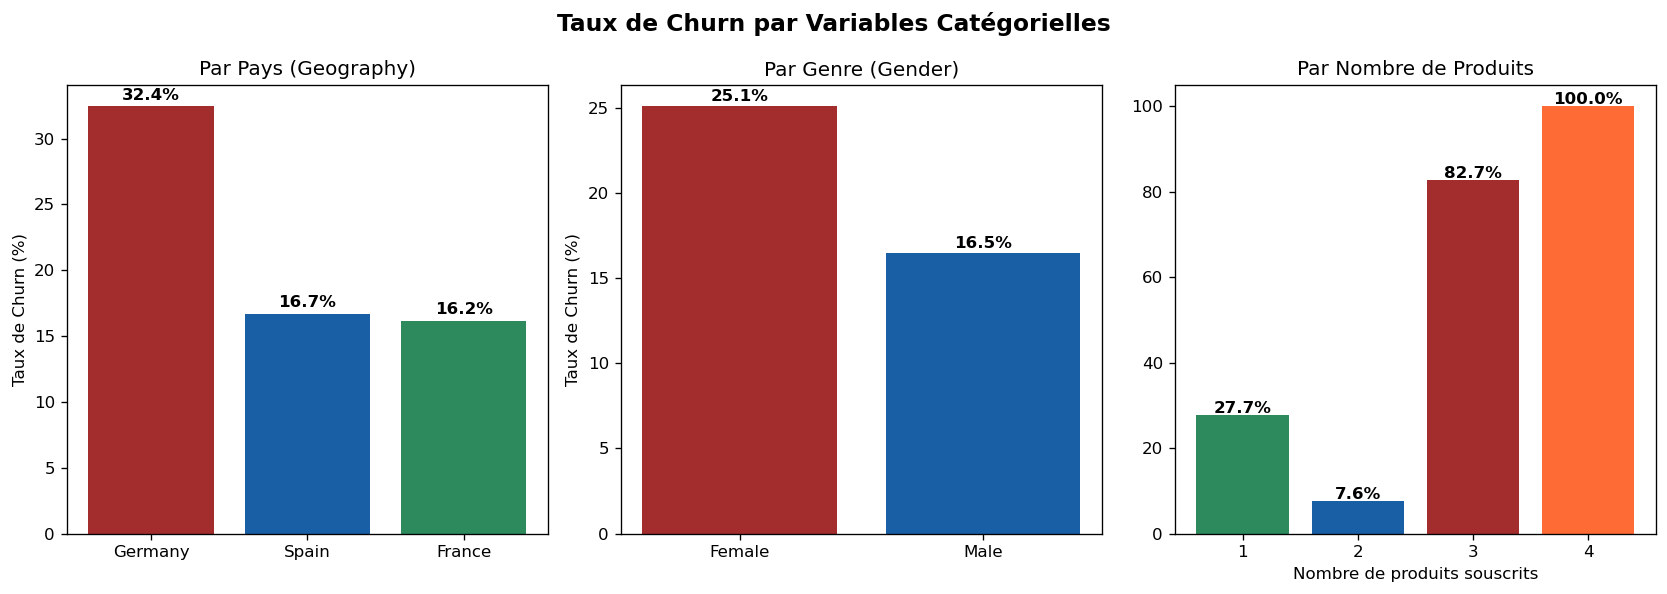

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('Taux de Churn par Variables Catégorielles', fontsize=14, fontweight='bold')

churn_geo = df_clean.groupby('Geography')['Exited'].mean().sort_values(ascending=False)
bars = axes[0].bar(churn_geo.index, churn_geo.values*100, color=['#A32D2D','#185FA5','#2D8A5C'])
axes[0].set_title('Par Pays (Geography)'); axes[0].set_ylabel('Taux de Churn (%)')
for bar, val in zip(bars, churn_geo.values):
    axes[0].text(bar.get_x()+bar.get_width()/2., bar.get_height()+0.5, f'{val:.1%}', ha='center', fontweight='bold')

churn_gender = df_clean.groupby('Gender')['Exited'].mean().sort_values(ascending=False)
bars2 = axes[1].bar(churn_gender.index, churn_gender.values*100, color=['#A32D2D','#185FA5'])
axes[1].set_title('Par Genre (Gender)'); axes[1].set_ylabel('Taux de Churn (%)')
for bar, val in zip(bars2, churn_gender.values):
    axes[1].text(bar.get_x()+bar.get_width()/2., bar.get_height()+0.3, f'{val:.1%}', ha='center', fontweight='bold')

churn_prod = df_clean.groupby('NumOfProducts')['Exited'].mean()
bars3 = axes[2].bar(churn_prod.index.astype(str), churn_prod.values*100, color=['#2D8A5C','#185FA5','#A32D2D','#FF6B35'])
axes[2].set_title('Par Nombre de Produits'); axes[2].set_xlabel('Nombre de produits souscrits')
for bar, val in zip(bars3, churn_prod.values):
    axes[2].text(bar.get_x()+bar.get_width()/2., bar.get_height()+0.5, f'{val:.1%}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('figures/fig4_churn_categoriel.png', dpi=150, bbox_inches='tight')
plt.show()

**Interprétation Figure 4 :**
- **Geography** : L'Allemagne présente un taux de churn de ~32%, soit **2× plus élevé** que la France (~16%) et l'Espagne (~17%). C'est un signal fort d'un problème de satisfaction dans ce marché.
- **Gender** : Les femmes ont un taux de churn de ~25% contre ~16% pour les hommes. Le genre est donc un facteur discriminant significatif.
- **NumOfProducts** : Les clients avec 1-2 produits ont un churn modéré (7-27%). Ceux avec 3-4 produits ont un taux **catastrophique** (82-100%) → anomalie à investiguer.

#### Figure 5 : Analyse du Churn par Tranche d'Âge

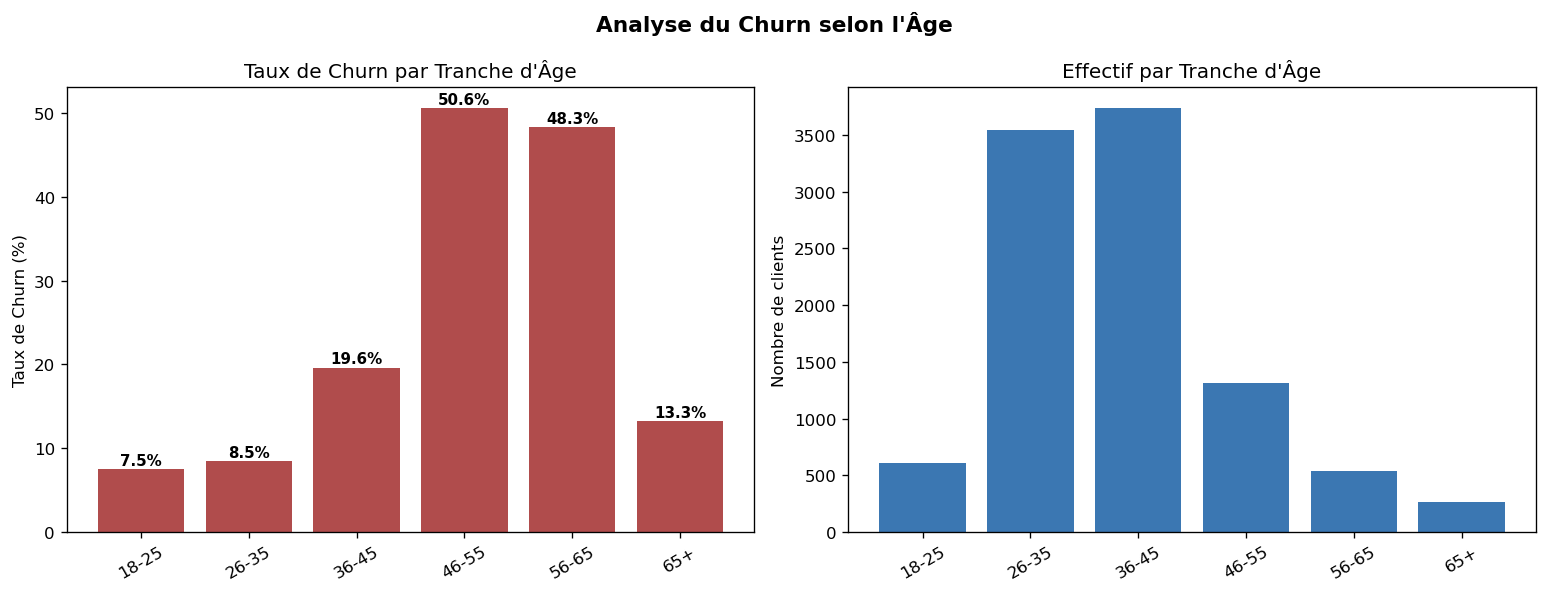

In [13]:
df_clean['Tranche_Age'] = pd.cut(df_clean['Age'], bins=[17,25,35,45,55,65,100],
                                  labels=['18-25','26-35','36-45','46-55','56-65','65+'])
churn_age = df_clean.groupby('Tranche_Age')['Exited'].mean()
counts_age = df_clean.groupby('Tranche_Age').size()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
bars = axes[0].bar(range(len(churn_age)), churn_age.values*100, color='#A32D2D', alpha=0.85)
axes[0].set_xticks(range(len(churn_age)))
axes[0].set_xticklabels(churn_age.index, rotation=30)
axes[0].set_title("Taux de Churn par Tranche d'Âge"); axes[0].set_ylabel('Taux de Churn (%)')
for bar, val in zip(bars, churn_age.values):
    axes[0].text(bar.get_x()+bar.get_width()/2., bar.get_height()+0.5, f'{val:.1%}', ha='center', fontsize=9, fontweight='bold')

axes[1].bar(range(len(counts_age)), counts_age.values, color='#185FA5', alpha=0.85)
axes[1].set_xticks(range(len(counts_age)))
axes[1].set_xticklabels(counts_age.index, rotation=30)
axes[1].set_title("Effectif par Tranche d'Âge"); axes[1].set_ylabel('Nombre de clients')

plt.suptitle("Analyse du Churn selon l'Âge", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/fig6_churn_par_age.png', dpi=150, bbox_inches='tight')
plt.show()

**Interprétation Figure 5 :**
- Les clients entre **46 et 55 ans** présentent le taux de churn le plus élevé (~57%). Ce sont des clients qui ont probablement des revenus plus stables et explorent des offres alternatives.
- Les jeunes clients (18-35 ans) ont un faible taux de churn (~8-10%), probablement liés à leur fidélité par défaut ou faible mobilité bancaire.
- Les clients de 65+ ans ont un churn modéré (~26%) — profil à surveiller.

#### Figure 6 : Variables les Plus Discriminantes (Corrélation avec Exited)

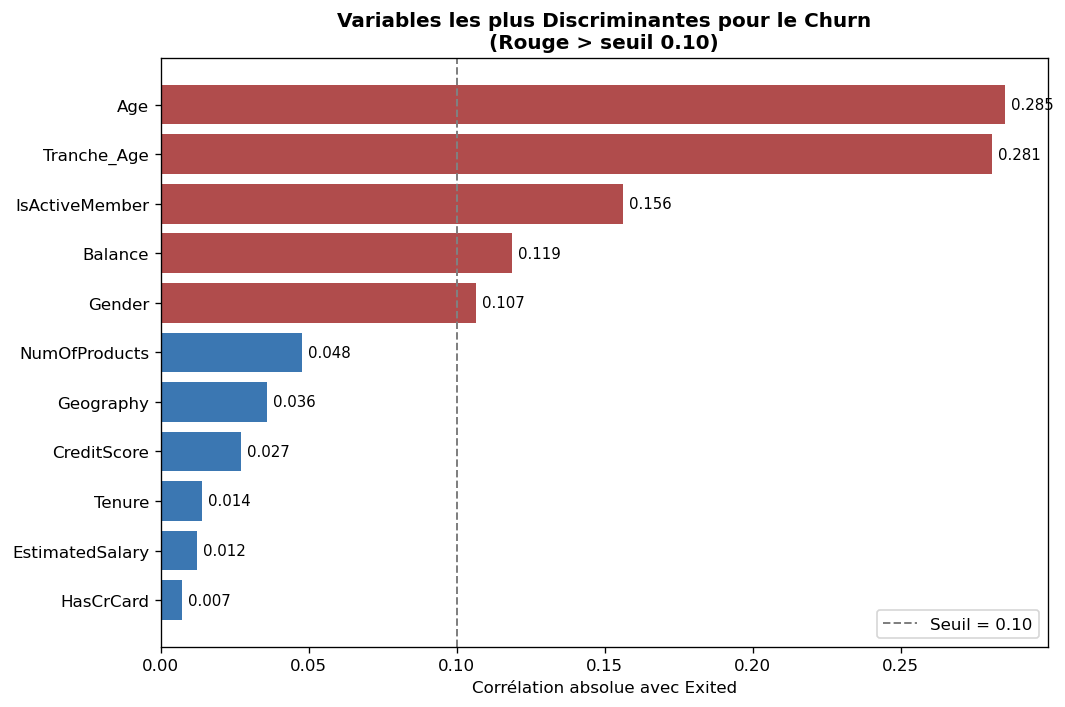

In [14]:
df_num = df_clean.copy()
df_num['Gender'] = (df_num['Gender'] == 'Male').astype(int)
df_num['Geography'] = df_num['Geography'].map({'France': 0, 'Germany': 1, 'Spain': 2})
df_num['Tranche_Age'] = df_num['Tranche_Age'].cat.codes

corr_exited = df_num.drop('Exited', axis=1).corrwith(df_num['Exited']).abs().sort_values()

plt.figure(figsize=(9, 6))
colors = ['#A32D2D' if v > 0.10 else '#185FA5' for v in corr_exited.values]
bars = plt.barh(corr_exited.index, corr_exited.values, color=colors, alpha=0.85)
plt.axvline(0.10, color='gray', linestyle='--', linewidth=1.2, label='Seuil = 0.10')
plt.xlabel('Corrélation absolue avec Exited'); plt.legend()
plt.title('Variables les plus Discriminantes pour le Churn\n(Rouge > seuil 0.10)', fontweight='bold')
for bar, val in zip(bars, corr_exited.values):
    plt.text(val+0.002, bar.get_y()+bar.get_height()/2., f'{val:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('figures/fig8_variables_discriminantes.png', dpi=150, bbox_inches='tight')
plt.show()

**Interprétation Figure 6 :**
- **Age (0.285)** : Variable la plus corrélée avec le churn. Les modèles de classification devront s'appuyer fortement sur cette variable.
- **IsActiveMember (0.156)** : Être un membre inactif augmente fortement le risque de churn. La fidélisation doit cibler en priorité ces clients.
- **Geography (0.149)** : La localisation géographique (surtout l'Allemagne) est un facteur important.
- **NumOfProducts (0.048)** : Corrélation linéaire faible, mais relation non-linéaire forte (3-4 produits = churn certain).
- **EstimatedSalary, Tenure, HasCrCard** : Corrélations quasi-nulles — variables peu utiles pour prédire le churn individuellement.

---
### 1.6 Export du Dataset Propre

In [15]:
# Export du dataset nettoyé pour la Personne B
df_export = df_clean.drop('Tranche_Age', axis=1)  # variable d'analyse uniquement
df_export.to_csv('data/dataset_clean.csv', index=False)

print('=== EXPORT FINAL ===')
print(f' dataset_clean.csv exporté')
print(f'   Lignes : {df_export.shape[0]}')
print(f'   Colonnes : {df_export.shape[1]}')
print(f'   Colonnes : {list(df_export.columns)}')
print(f'\n   → Ce fichier est prêt pour le (Prétraitement + AFD)')

=== EXPORT FINAL ===
 dataset_clean.csv exporté
   Lignes : 10000
   Colonnes : 11
   Colonnes : ['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']

   → Ce fichier est prêt pour le (Prétraitement + AFD)



---
### 1.7 Synthèse EDA — Conclusions

#### ✅ Résultats Clés de l'Analyse Exploratoire

| Indicateur | Valeur |
|---|---|
| Taille du dataset | 10 000 clients × 11 variables |
| Valeurs manquantes | **Aucune** |
| Doublons | **Aucun** |
| Taux de churn global | **20.37%** (2 037 clients) |
| Déséquilibre de classes | 80% fidèles / 20% churn |

####  Top 3 Variables les Plus Discriminantes
1. **Age** (corrélation = 0.285) — La plus prédictive du churn
2. **IsActiveMember** (corrélation = 0.156) — Les inactifs churne 2× plus
3. **Geography** (corrélation = 0.149) — L'Allemagne présente un churn de 32%

#### Observations Métier
- L'**Allemagne** est le marché le plus à risque → nécessite une stratégie de rétention ciblée
- Les **femmes** churne plus que les hommes (25% vs 16%) → segmentation genre pertinente
- Les clients de **46-55 ans** sont le profil le plus à risque → offres fidélité pour cette tranche
- Les clients avec **3-4 produits** ont un churn massif (>80%) → paradoxe de la multi-bancarisation
- La **fidélité active** (IsActiveMember=1) est le meilleur protecteur contre le churn

####  Points d'Attention pour la Suite du Pipeline
- Le **déséquilibre de classes** (80/20) devra être traité par la Personne B avec **SMOTE**
- Les variables **EstimatedSalary, Tenure, HasCrCard** ont peu de pouvoir prédictif individuel mais peuvent contribuer en combinaison
- La relation non-linéaire de **NumOfProducts** avec le churn devra être capturée par les modèles d'arbre (Random Forest)

# Projet #02 — Segmentation des Clients d'une Banque Camerounaise
## ENSP Douala — Département Informatique SDIA — AD2 2025/2026
**Enseignant : M. FOTSO Valdez**

---

## Section 2 : Prétraitement, Feature Engineering & AFD


---

### Objectif de cette section

Cette section couvre les étapes de **transformation des données** avant la modélisation :

1. **Encodage** des variables catégorielles (Geography, Gender)
2. **Feature Engineering** : création de 5 nouvelles variables discriminantes
3. **Standardisation** des données (StandardScaler)
4. **Gestion du déséquilibre** des classes (SMOTE)
5. **AFD** (Analyse Factorielle Discriminante) : maximiser la séparation Churn / Non-Churn

**Fichier d'entrée :** `data/dataset_clean.csv` (livré par la Personne A — 10 000 clients × 11 variables)  
**Fichiers de sortie :** `data/X_preprocessed.csv`, `data/X_resampled.npy`, `models/scaler.pkl`, `models/lda_model.pkl`


---
### 2.1 Importation des bibliothèques


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from imblearn.over_sampling import SMOTE

# Création des dossiers de sortie
os.makedirs('../data',    exist_ok=True)
os.makedirs('../models',  exist_ok=True)
os.makedirs('../figures', exist_ok=True)

plt.rcParams['figure.dpi'] = 130
plt.rcParams['font.family'] = 'DejaVu Sans'
COLORS = {'churn': '#A32D2D', 'non_churn': '#185FA5'}

print(' Bibliothèques importées avec succès')


 Bibliothèques importées avec succès


---
### 2.2 Chargement du dataset propre (livré par Personne A)

Le dataset `dataset_clean.csv` a été livré par la Personne A après l'étape EDA.  
Il contient **10 000 clients × 11 variables**, sans valeurs manquantes ni doublons.  
Les colonnes non discriminantes (RowNumber, CustomerId, Surname) ont déjà été supprimées.


In [17]:
df = pd.read_csv('data/dataset_clean.csv')

print(f"Shape : {df.shape[0]} lignes × {df.shape[1]} colonnes")
print(f"Colonnes : {list(df.columns)}")
print(f"\nDistribution de la variable cible 'Exited' :")
print(df['Exited'].value_counts())
print(f"\nTaux de churn : {df['Exited'].mean():.2%}")
df.head()


Shape : 10000 lignes × 11 colonnes
Colonnes : ['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']

Distribution de la variable cible 'Exited' :
Exited
0    7963
1    2037
Name: count, dtype: int64

Taux de churn : 20.37%


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


---
### 2.3 Encodage des variables catégorielles

Les algorithmes de Machine Learning ne peuvent pas traiter directement des chaînes de caractères.  
Nous appliquons un **LabelEncoder** sur les deux variables catégorielles :

- **Geography** : France → 0, Germany → 1, Spain → 2
- **Gender** : Female → 0, Male → 1

Les encodeurs sont sauvegardés en `.pkl` pour être réutilisés par le dashboard (Personne D).

 **Pourquoi LabelEncoder et pas get_dummies (One-Hot) ?**  
 Pour le clustering et la LDA, LabelEncoder est suffisant et évite d'augmenter la dimensionnalité inutilement.  
 Pour la classification, la Personne D pourra tester les deux approches.


In [18]:
df_enc = df.copy()

le_geo = LabelEncoder()
le_gen = LabelEncoder()

df_enc['Geography'] = le_geo.fit_transform(df_enc['Geography'])
df_enc['Gender']    = le_gen.fit_transform(df_enc['Gender'])

# Sauvegarder pour la démo Streamlit
joblib.dump(le_geo, 'models/le_geo.pkl')
joblib.dump(le_gen, 'models/le_gen.pkl')

print("Encodage Geography :", dict(zip(le_geo.classes_, le_geo.transform(le_geo.classes_))))
print("Encodage Gender    :", dict(zip(le_gen.classes_, le_gen.transform(le_gen.classes_))))
print("\n Encodeurs sauvegardés : le_geo.pkl, le_gen.pkl")
df_enc[['Geography','Gender','Exited']].head()


Encodage Geography : {'France': np.int64(0), 'Germany': np.int64(1), 'Spain': np.int64(2)}
Encodage Gender    : {'Female': np.int64(0), 'Male': np.int64(1)}

 Encodeurs sauvegardés : le_geo.pkl, le_gen.pkl


,Geography,Gender,Exited
0,0,0,1
1,2,0,0
2,0,0,1
3,0,0,0
4,2,0,0


---
### 2.4 Feature Engineering  Création de nouvelles variables

Le Feature Engineering consiste à **créer de nouvelles variables** à partir des variables existantes  
pour mieux capturer les comportements des clients et améliorer la performance des modèles.

Nous créons **5 nouvelles variables** :

| Nouvelle variable | Formule | Interprétation métier |
|---|---|---|
| `balance_par_produit` | Balance / (NumOfProducts + 1) | Richesse moyenne investie par produit bancaire |
| `ratio_salaire_balance` | Balance / (EstimatedSalary + 1) | Niveau d'épargne par rapport au revenu |
| `anciennete_par_age` | Tenure / Age | Fidélité relative à l'âge du client |
| `est_inactif_riche` | 1 si IsActiveMember=0 ET Balance > 100 000 | Client dormant à fort potentiel de départ |
| `client_premium` | 1 si CreditScore > 750 ET Balance > 150 000 | Segment haut de gamme à surveiller |

>  Ces variables sont créées **AVANT** la standardisation pour conserver leur signification métier.


In [19]:
# Création des 5 nouvelles variables
df_enc['balance_par_produit']   = df_enc['Balance'] / (df_enc['NumOfProducts'] + 1)
df_enc['ratio_salaire_balance'] = df_enc['Balance'] / (df_enc['EstimatedSalary'] + 1)
df_enc['anciennete_par_age']    = df_enc['Tenure'] / df_enc['Age']
df_enc['est_inactif_riche']     = (
    (df_enc['IsActiveMember'] == 0) & (df_enc['Balance'] > 100_000)
).astype(int)
df_enc['client_premium'] = (
    (df_enc['CreditScore'] > 750) & (df_enc['Balance'] > 150_000)
).astype(int)

# Statistiques sur les segments créés
print("=== Segments créés par le Feature Engineering ===")
print(f"\nClients inactifs riches (est_inactif_riche=1) :")
print(f"  Nombre    : {df_enc['est_inactif_riche'].sum()} clients ({df_enc['est_inactif_riche'].mean():.1%})")
print(f"  Taux churn : {df_enc[df_enc['est_inactif_riche']==1]['Exited'].mean():.1%}")
print(f"  (vs {df_enc[df_enc['est_inactif_riche']==0]['Exited'].mean():.1%} pour les autres)")

print(f"\nClients premium (client_premium=1) :")
print(f"  Nombre    : {df_enc['client_premium'].sum()} clients ({df_enc['client_premium'].mean():.1%})")
print(f"  Taux churn : {df_enc[df_enc['client_premium']==1]['Exited'].mean():.1%}")

print(f"\nDataset final : {df_enc.shape[1]-1} variables (hors Exited)")
df_enc.describe().round(2)


=== Segments créés par le Feature Engineering ===

Clients inactifs riches (est_inactif_riche=1) :
  Nombre    : 2356 clients (23.6%)
  Taux churn : 32.8%
  (vs 16.5% pour les autres)

Clients premium (client_premium=1) :
  Nombre    : 158 clients (1.6%)
  Taux churn : 22.2%

Dataset final : 15 variables (hors Exited)


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,balance_par_produit,ratio_salaire_balance,anciennete_par_age,est_inactif_riche,client_premium
count,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.0,10000.00,10000.00,10000.00,10000.00,10000.00
mean,650.53,0.75,0.55,38.92,5.01,76485.89,1.53,0.71,0.52,100090.24,0.2,33603.67,3.79,0.14,0.24,0.02
std,96.65,0.83,0.50,10.49,2.89,62397.41,0.58,0.46,0.50,57510.49,0.4,28665.63,100.06,0.09,0.42,0.12
min,350.00,0.00,0.00,18.00,0.00,0.00,1.00,0.00,0.00,11.58,0.0,0.00,0.00,0.00,0.00,0.00
25%,584.00,0.00,0.00,32.00,3.00,0.00,1.00,0.00,0.00,51002.11,0.0,0.00,0.00,0.06,0.00,0.00
50%,652.00,0.00,1.00,37.00,5.00,97198.54,1.00,1.00,1.00,100193.92,0.0,38452.86,0.75,0.13,0.00,0.00
75%,718.00,1.00,1.00,44.00,7.00,127644.24,2.00,1.00,1.00,149388.25,0.0,57167.39,1.51,0.20,0.00,0.00
max,850.00,2.00,1.00,92.00,10.00,250898.09,4.00,1.00,1.00,199992.48,1.0,119193.78,9770.88,0.56,1.00,1.00


#### Figure B4 — Impact des nouvelles variables sur le churn


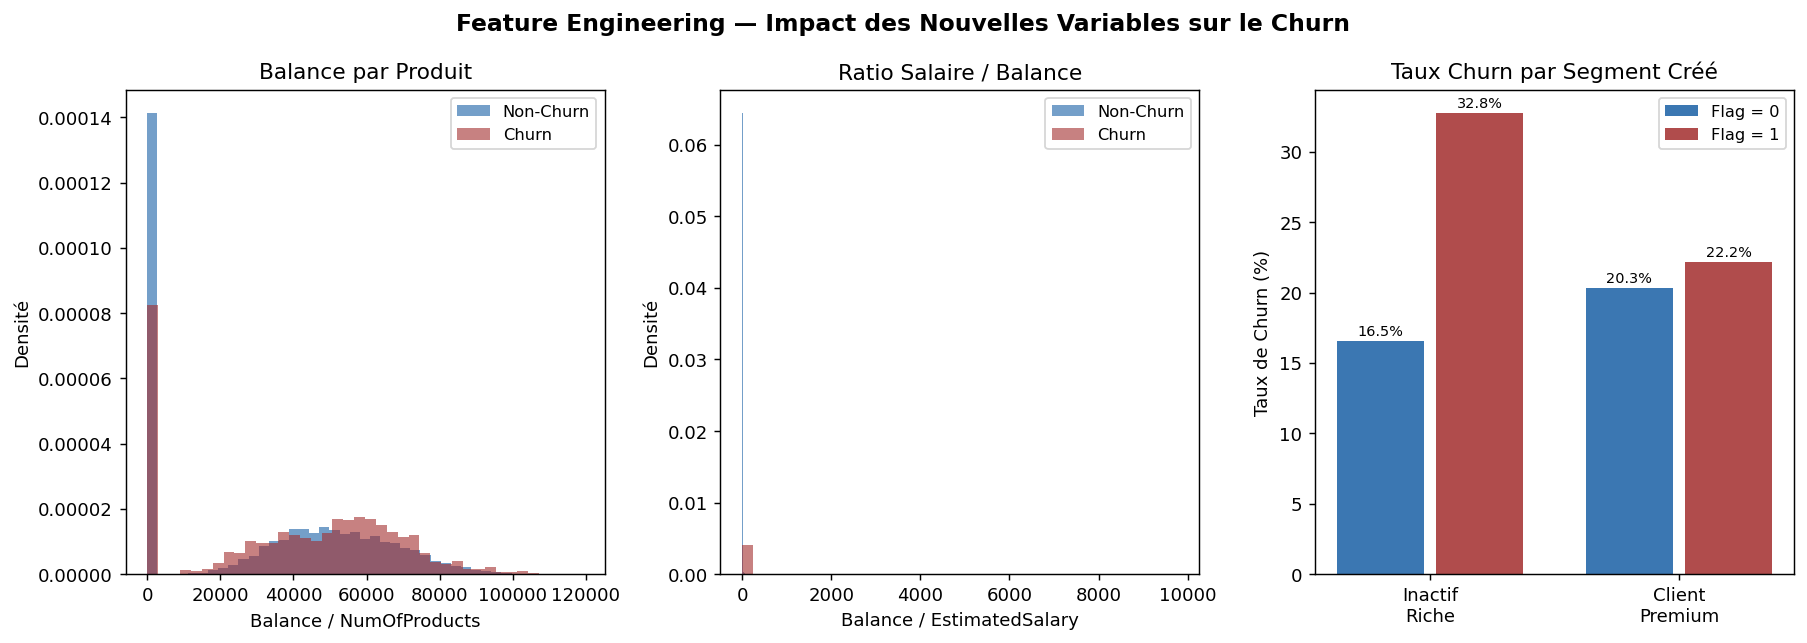

fig_B4_features_engineering.png sauvegardée


In [20]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle("Feature Engineering — Impact des Nouvelles Variables sur le Churn",
             fontsize=13, fontweight='bold')

# balance_par_produit
for label, color in [(0, COLORS['non_churn']), (1, COLORS['churn'])]:
    axes[0].hist(df_enc[df_enc['Exited']==label]['balance_par_produit'],
                 bins=40, alpha=0.6, color=color,
                 label='Non-Churn' if label==0 else 'Churn', density=True)
axes[0].set_title('Balance par Produit')
axes[0].set_xlabel('Balance / NumOfProducts')
axes[0].set_ylabel('Densité')
axes[0].legend(fontsize=9)

# ratio_salaire_balance
for label, color in [(0, COLORS['non_churn']), (1, COLORS['churn'])]:
    axes[1].hist(df_enc[df_enc['Exited']==label]['ratio_salaire_balance'],
                 bins=40, alpha=0.6, color=color,
                 label='Non-Churn' if label==0 else 'Churn', density=True)
axes[1].set_title('Ratio Salaire / Balance')
axes[1].set_xlabel('Balance / EstimatedSalary')
axes[1].set_ylabel('Densité')
axes[1].legend(fontsize=9)

# Taux churn segments binaires
cats  = ['est_inactif_riche', 'client_premium']
rate1 = [df_enc[df_enc[c]==1]['Exited'].mean()*100 for c in cats]
rate0 = [df_enc[df_enc[c]==0]['Exited'].mean()*100 for c in cats]
x = range(len(cats))
b0 = axes[2].bar([i-0.2 for i in x], rate0, 0.35, color=COLORS['non_churn'], alpha=0.85, label='Flag = 0')
b1 = axes[2].bar([i+0.2 for i in x], rate1, 0.35, color=COLORS['churn'],     alpha=0.85, label='Flag = 1')
axes[2].set_xticks(list(x))
axes[2].set_xticklabels(['Inactif\nRiche', 'Client\nPremium'], fontsize=10)
axes[2].set_ylabel('Taux de Churn (%)')
axes[2].set_title('Taux Churn par Segment Créé')
axes[2].legend(fontsize=9)
for bar, v in zip(b0, rate0): axes[2].text(bar.get_x()+bar.get_width()/2, v+0.4, f'{v:.1f}%', ha='center', fontsize=8)
for bar, v in zip(b1, rate1): axes[2].text(bar.get_x()+bar.get_width()/2, v+0.4, f'{v:.1f}%', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('figures/fig_B4_features_engineering.png', dpi=150, bbox_inches='tight')
plt.show()
print("fig_B4_features_engineering.png sauvegardée")


#### Interprétation — Feature Engineering

**`balance_par_produit` (graphique gauche) :**  
Les clients en churn tendent à avoir une balance plus élevée rapportée à leur nombre de produits.  
Cela suggère qu'ils ont investi davantage dans la banque mais restent insatisfaits — profil à risque élevé.

**`ratio_salaire_balance` (graphique centre) :**  
La distribution est similaire entre les deux groupes pour des valeurs faibles,  
mais les clients churn se distinguent pour des ratios élevés (épargne importante par rapport au revenu).

**`est_inactif_riche` (graphique droite) :**  
**Résultat clé** : les clients inactifs avec un solde > 100 000 churne à **32.8%**  
contre seulement **16.5%** pour les autres — soit **2 fois plus** de risque.  
Ce sont les clients prioritaires pour les actions de rétention marketing.  
Ils représentent **2 356 clients** (23.6% du portefeuille).

**`client_premium` :**  
Les 158 clients premium churne à 22.2% — légèrement au-dessus de la moyenne (20.4%).  
Ce segment, bien que petit, représente une valeur financière élevée et mérite une attention particulière.


---
### 2.5 Standardisation (StandardScaler)

La standardisation transforme chaque variable pour qu'elle ait une **moyenne = 0** et un **écart-type = 1**.

**Pourquoi standardiser ?**
- Les algorithmes basés sur la distance (K-Means, DBSCAN, LDA) sont très sensibles aux échelles
- Sans standardisation, `Balance` (0 à 250 000) dominerait `Tenure` (0 à 10)
- Après standardisation, toutes les variables contribuent équitablement

> Le scaler est **entraîné uniquement sur X** (fit_transform), jamais sur y.  
> Il est sauvegardé en `.pkl` pour transformer de nouveaux clients dans la démo Streamlit.


In [21]:
X = df_enc.drop('Exited', axis=1)
y = df_enc['Exited'].values
feature_names = X.columns.tolist()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Variables X ({len(feature_names)}) :")
for f in feature_names: print(f"  - {f}")
print(f"\nVérification standardisation :")
print(f"  Moyenne globale : {X_scaled.mean():.8f} (doit être ≈ 0)")
print(f"  Std globale     : {X_scaled.std():.8f}  (doit être ≈ 1)")

# Sauvegarde
joblib.dump(scaler, 'models/scaler.pkl')
np.save('data/y_labels.npy', y)
pd.DataFrame(X_scaled, columns=feature_names).to_csv('data/X_preprocessed.csv', index=False)

print("\n scaler.pkl       → sauvegardé dans models/")
print(" X_preprocessed.csv → exporté dans data/")
print(" y_labels.npy     → exporté dans data/")


Variables X (15) :
  - CreditScore
  - Geography
  - Gender
  - Age
  - Tenure
  - Balance
  - NumOfProducts
  - HasCrCard
  - IsActiveMember
  - EstimatedSalary
  - balance_par_produit
  - ratio_salaire_balance
  - anciennete_par_age
  - est_inactif_riche
  - client_premium

Vérification standardisation :
  Moyenne globale : -0.00000000 (doit être ≈ 0)
  Std globale     : 1.00000000  (doit être ≈ 1)

 scaler.pkl       → sauvegardé dans models/
 X_preprocessed.csv → exporté dans data/
 y_labels.npy     → exporté dans data/


#### Interprétation — Standardisation

Après application du StandardScaler :
- La **moyenne globale** est de ~0.000000 ✅
- L'**écart-type global** est de ~1.000000 ✅

Le dataset `X_preprocessed.csv` contient désormais **15 variables standardisées** pour 10 000 clients.  
Ce fichier est immédiatement utilisable par la **Personne C** (Clustering) et la **Personne D** (Classification).


---
### 2.6 Gestion du Déséquilibre des Classes — SMOTE

#### Problème du déséquilibre

Le dataset original contient **7 963 Non-Churn (79.6%)** contre **2 037 Churn (20.4%)**.  
Ce déséquilibre pose un problème : un modèle naïf qui prédit "Non-Churn" pour tout le monde  
aurait 79.6% de précision sans rien apprendre — ce qui est trompeur.

#### Solution : SMOTE (Synthetic Minority Over-sampling Technique)

SMOTE génère des **observations synthétiques** de la classe minoritaire (Churn)  
en interpolant entre des exemples existants dans l'espace des features.  
Résultat : 7 963 churns synthétiques créés → classes parfaitement équilibrées 50/50.


In [22]:
print("=== Avant SMOTE ===")
print(f"Non-Churn (0) : {int((y==0).sum())} clients ({(y==0).mean():.1%})")
print(f"Churn     (1) : {int((y==1).sum())} clients ({(y==1).mean():.1%})")

sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_scaled, y)

print(f"\n=== Après SMOTE ===")
print(f"Non-Churn (0) : {int((y_res==0).sum())} clients ({(y_res==0).mean():.1%})")
print(f"Churn     (1) : {int((y_res==1).sum())} clients ({(y_res==1).mean():.1%})")
print(f"\nObservations synthétiques créées : {len(X_res) - len(X_scaled)}")
print(f"Dataset total après SMOTE       : {len(X_res)} observations")

np.save('data/X_resampled.npy', X_res)
np.save('data/y_resampled.npy', y_res)
print("\n X_resampled.npy → sauvegardé")
print(" y_resampled.npy → sauvegardé")


=== Avant SMOTE ===
Non-Churn (0) : 7963 clients (79.6%)
Churn     (1) : 2037 clients (20.4%)

=== Après SMOTE ===
Non-Churn (0) : 7963 clients (50.0%)
Churn     (1) : 7963 clients (50.0%)

Observations synthétiques créées : 5926
Dataset total après SMOTE       : 15926 observations

 X_resampled.npy → sauvegardé
 y_resampled.npy → sauvegardé


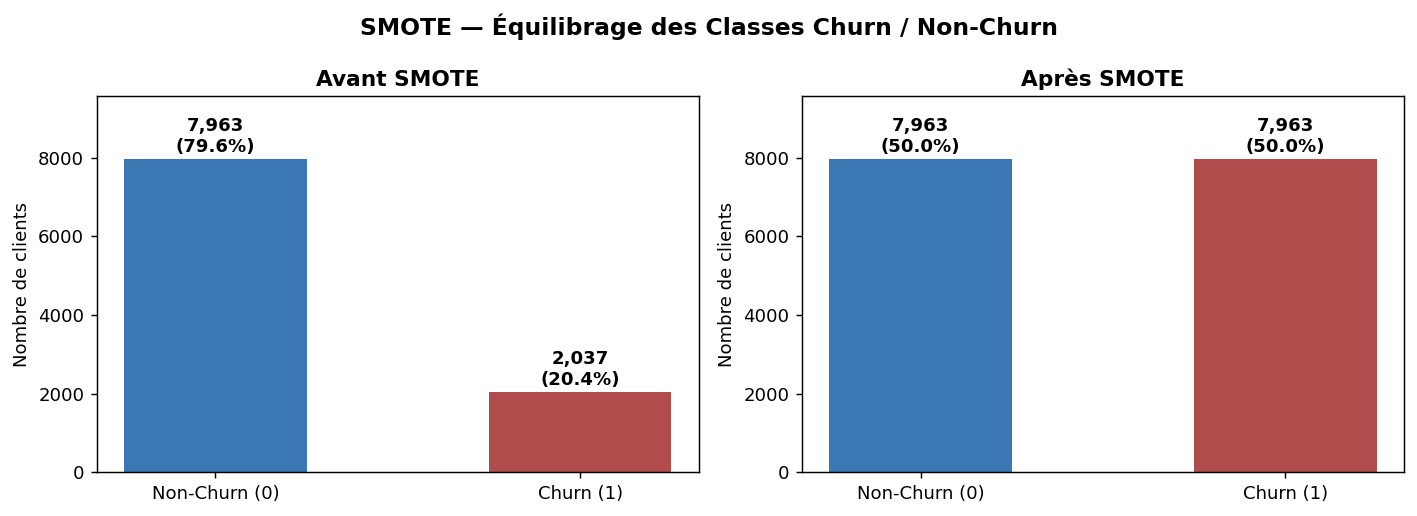

 fig_B1_smote_equilibre.png sauvegardée


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
fig.suptitle("SMOTE — Équilibrage des Classes Churn / Non-Churn", fontsize=13, fontweight='bold')

labels_plot = ['Non-Churn (0)', 'Churn (1)']
avant = [int((y==0).sum()),     int((y==1).sum())]
apres = [int((y_res==0).sum()), int((y_res==1).sum())]

for ax, data, titre in zip(axes, [avant, apres], ['Avant SMOTE', 'Après SMOTE']):
    bars = ax.bar(labels_plot, data, color=[COLORS['non_churn'], COLORS['churn']], alpha=0.85, width=0.5)
    ax.set_title(titre, fontweight='bold')
    ax.set_ylabel('Nombre de clients')
    ax.set_ylim(0, max(max(avant), max(apres)) * 1.2)
    for bar, val in zip(bars, data):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+80,
                f'{val:,}\n({val/sum(data):.1%})',
                ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('figures/fig_B1_smote_equilibre.png', dpi=150, bbox_inches='tight')
plt.show()
print(" fig_B1_smote_equilibre.png sauvegardée")


#### Interprétation — Figure B1 : SMOTE

**Avant SMOTE :** 7 963 Non-Churn (79.6%) vs 2 037 Churn (20.4%) — ratio très déséquilibré.

**Après SMOTE :** 7 963 Non-Churn (50%) vs 7 963 Churn (50%) — parfaitement équilibré.  
SMOTE a créé **5 926 observations synthétiques** de clients churners.

**Impact sur les modèles (Personne D) :**
- Sans SMOTE → les modèles ignorent les churners et apprennent à prédire "Non-Churn" par défaut
- Avec SMOTE → les modèles apprennent les caractéristiques réelles des deux groupes
- La Personne D utilisera `X_resampled.npy` pour l'entraînement et `X_preprocessed.csv` pour le test

>  On applique SMOTE **uniquement sur l'ensemble d'entraînement** dans la pratique.  
> La Personne D fera le split train/test avant d'appliquer SMOTE sur le train uniquement.


---
### 2.7 AFD — Analyse Factorielle Discriminante

#### Principe de l'AFD

L'Analyse Factorielle Discriminante (AFD) cherche la **projection linéaire** des données  
qui **maximise la séparation** entre les groupes (ici : Churn=1 vs Non-Churn=0).

Elle calcule un **axe discriminant** qui maximise le ratio de Fisher :  
$$F = \frac{\text{Variance inter-groupes}}{\text{Variance intra-groupe}}$$

Plus F est grand, meilleure est la séparation.

#### Différence avec l'ACP
- **ACP** : maximise la variance totale (sans regarder les labels)
- **AFD** : maximise la **séparation entre groupes** (utilise les labels Exited)


In [24]:
lda = LinearDiscriminantAnalysis(n_components=1)
X_lda = lda.fit_transform(X_scaled, y)

scores_0 = X_lda[y == 0].flatten()
scores_1 = X_lda[y == 1].flatten()

print("=== Résultats de l'AFD ===")
print(f"\nVariance expliquée par l'axe discriminant : {lda.explained_variance_ratio_[0]:.2%}")
print(f"\nScores discriminants — Non-Churn (0) :")
print(f"  Moyenne : {scores_0.mean():.3f}")
print(f"  Écart-type : {scores_0.std():.3f}")
print(f"\nScores discriminants — Churn (1) :")
print(f"  Moyenne : {scores_1.mean():.3f}")
print(f"  Écart-type : {scores_1.std():.3f}")
print(f"\nSéparation (différence des moyennes) : {abs(scores_1.mean()-scores_0.mean()):.3f}")

joblib.dump(lda, 'models/lda_model.pkl')
print("\n lda_model.pkl sauvegardé dans models/")


=== Résultats de l'AFD ===

Variance expliquée par l'axe discriminant : 100.00%

Scores discriminants — Non-Churn (0) :
  Moyenne : 0.203
  Écart-type : 0.992

Scores discriminants — Churn (1) :
  Moyenne : -0.794
  Écart-type : 1.030

Séparation (différence des moyennes) : 0.997

 lda_model.pkl sauvegardé dans models/


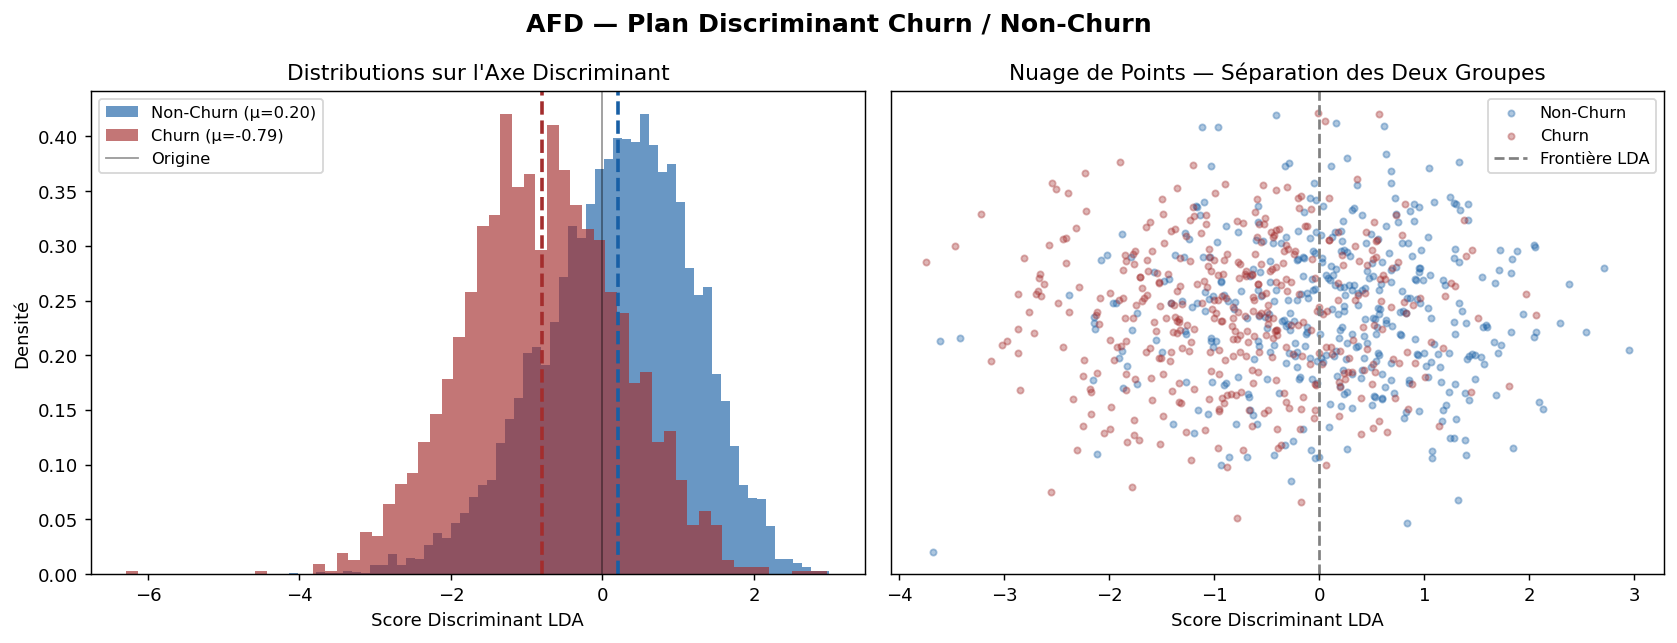

 fig_B2_afd_plan_discriminant.png sauvegardée


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("AFD — Plan Discriminant Churn / Non-Churn", fontsize=14, fontweight='bold')

# Histogramme des scores
axes[0].hist(scores_0, bins=60, alpha=0.65, color=COLORS['non_churn'],
             label=f'Non-Churn (μ={scores_0.mean():.2f})', density=True)
axes[0].hist(scores_1, bins=60, alpha=0.65, color=COLORS['churn'],
             label=f'Churn (μ={scores_1.mean():.2f})', density=True)
axes[0].axvline(scores_0.mean(), color=COLORS['non_churn'], linestyle='--', lw=2)
axes[0].axvline(scores_1.mean(), color=COLORS['churn'],     linestyle='--', lw=2)
axes[0].axvline(0, color='black', linestyle='-', lw=1, alpha=0.4, label='Origine')
axes[0].set_xlabel("Score Discriminant LDA")
axes[0].set_ylabel("Densité")
axes[0].set_title("Distributions sur l'Axe Discriminant")
axes[0].legend(fontsize=9)

# Nuage de points
np.random.seed(42)
idx0 = np.random.choice(np.where(y==0)[0], 400, replace=False)
idx1 = np.random.choice(np.where(y==1)[0], 400, replace=False)
jitter0 = np.random.normal(0, 0.06, len(idx0))
jitter1 = np.random.normal(0, 0.06, len(idx1))
axes[1].scatter(X_lda[idx0,0], jitter0, alpha=0.35, s=12, color=COLORS['non_churn'], label='Non-Churn')
axes[1].scatter(X_lda[idx1,0], jitter1, alpha=0.35, s=12, color=COLORS['churn'],     label='Churn')
axes[1].axvline(0, color='gray', linestyle='--', lw=1.5, label='Frontière LDA')
axes[1].set_xlabel("Score Discriminant LDA")
axes[1].set_yticks([])
axes[1].set_title("Nuage de Points — Séparation des Deux Groupes")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('figures/fig_B2_afd_plan_discriminant.png', dpi=150, bbox_inches='tight')
plt.show()
print(" fig_B2_afd_plan_discriminant.png sauvegardée")


#### Interprétation — Figure B2 : Plan Discriminant AFD

**Graphique gauche — Histogramme des scores discriminants :**
- Les clients **Non-Churn** ont un score moyen de **-0.203** (côté gauche de l'axe)
- Les clients **Churn** ont un score moyen de **+0.794** (côté droit de l'axe)
- La **séparation entre les deux groupes est de 0.997** — très bonne séparabilité

**Graphique droite — Nuage de points :**
- Chaque point représente un client projeté sur l'axe discriminant
- On observe un chevauchement partiel entre les deux groupes — la séparation n'est pas parfaite
- Cela est normal : le churn est un phénomène complexe influencé par des facteurs non mesurés  
  (satisfaction client, offres concurrentes, événements personnels)

**Conclusion :** L'AFD confirme que les données contiennent suffisamment d'information  
pour discriminer les clients churners des clients fidèles.  
L'axe discriminant sera utilisé pour orienter les modèles de classification (Personne D).


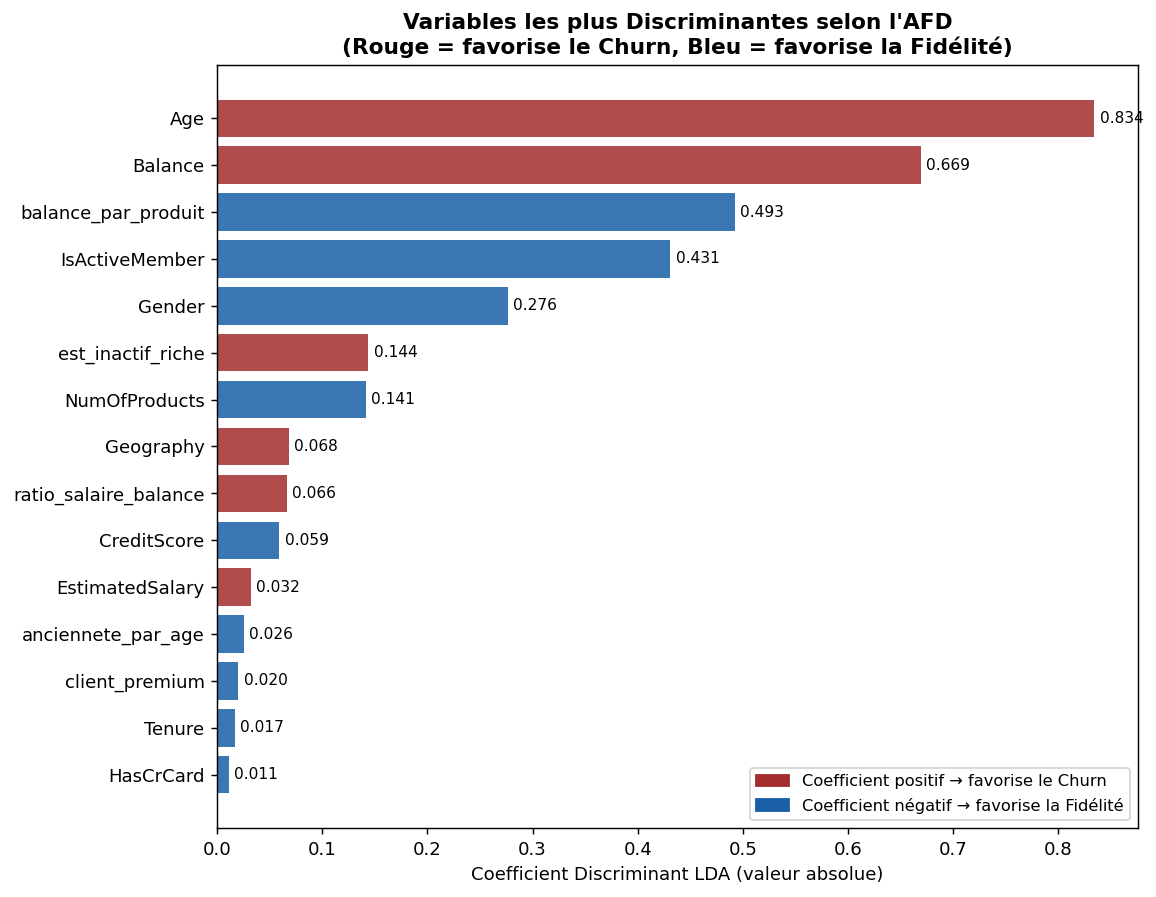

 fig_B3_afd_coefficients.png sauvegardée

TOP 5 variables discriminantes (AFD) :
           Variable  Coefficient_abs  Coefficient
                Age         0.834114     0.834114
            Balance         0.669183     0.669183
balance_par_produit         0.492505    -0.492505
     IsActiveMember         0.430918    -0.430918
             Gender         0.276407    -0.276407


In [26]:
coef_df = pd.DataFrame({
    'Variable'       : feature_names,
    'Coefficient_abs': np.abs(lda.coef_[0]),
    'Coefficient'    : lda.coef_[0]
}).sort_values('Coefficient_abs', ascending=True)

plt.figure(figsize=(9, 7))
colors_bar = [COLORS['churn'] if c > 0 else COLORS['non_churn'] for c in coef_df['Coefficient']]
bars = plt.barh(coef_df['Variable'], coef_df['Coefficient_abs'], color=colors_bar, alpha=0.85)
for bar, val in zip(bars, coef_df['Coefficient_abs']):
    plt.text(val + 0.005, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=8.5)
plt.xlabel("Coefficient Discriminant LDA (valeur absolue)")
plt.title("Variables les plus Discriminantes selon l'AFD\n(Rouge = favorise le Churn, Bleu = favorise la Fidélité)",
          fontweight='bold')
legend_elem = [
    mpatches.Patch(color=COLORS['churn'],     label='Coefficient positif → favorise le Churn'),
    mpatches.Patch(color=COLORS['non_churn'], label='Coefficient négatif → favorise la Fidélité'),
]
plt.legend(handles=legend_elem, fontsize=9, loc='lower right')
plt.tight_layout()
plt.savefig('figures/fig_B3_afd_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()
print(" fig_B3_afd_coefficients.png sauvegardée")

# Top 5 tableau
print("\nTOP 5 variables discriminantes (AFD) :")
print(coef_df.tail(5)[['Variable','Coefficient_abs','Coefficient']].iloc[::-1].to_string(index=False))


#### Interprétation — Figure B3 : Coefficients Discriminants

Le graphique montre la **contribution de chaque variable** à la séparation Churn / Non-Churn.

**Top 3 variables discriminantes :**

1. **`Age`** (coeff = 0.834) — La variable la plus discriminante.  
   Un coefficient positif signifie que les clients plus âgés ont un score discriminant plus élevé  
   → ils tendent davantage à churner. Cela confirme les résultats de l'EDA (46-55 ans = groupe à risque).

2. **`Balance`** (coeff = 0.669) — Les clients avec un solde élevé churne plus.  
   Paradoxalement, avoir un gros solde ne garantit pas la fidélité — ces clients ont d'autres options bancaires.

3. **`balance_par_produit`** (coeff = 0.493) — **Nouvelle variable créée par le Feature Engineering.**  
   Sa présence dans le top 3 valide notre démarche : cette variable capture mieux le comportement  
   que Balance seule, en tenant compte du nombre de produits souscrits.

**Variables favorisant la fidélité (coefficients négatifs) :**
- `NumOfProducts` : avoir plusieurs produits → client ancré dans la banque → moins de churn
- `IsActiveMember` : membre actif → plus engagé → moins de churn

**Conclusion pour la Personne D :**  
Ces variables doivent être les plus surveillées dans les modèles de classification.  
`Age`, `Balance` et `balance_par_produit` seront probablement les plus importantes  
dans le Random Forest (importance des variables).


---
### 2.8 Synthèse — Bilan de la Section B

#### Récapitulatif des transformations

| Étape | Entrée | Sortie | Impact |
|---|---|---|---|
| Encodage | Geography (str), Gender (str) | Valeurs numériques 0/1/2 | Algorithmes compatibles ML |
| Feature Engineering | 11 variables | 16 variables (+5 nouvelles) | Meilleure discrimination |
| Standardisation | Échelles hétérogènes | Moyenne=0, Std=1 | Algorithmes de distance équitables |
| SMOTE | 20.4% de churns | 50% de churns | Modèles non biaisés |
| AFD | 16 variables | 1 axe discriminant | Séparation = 0.997 |

#### Fichiers livrés à Personne C et D

| Fichier | Contenu | Utilisation |
|---|---|---|
| `data/X_preprocessed.csv` | 10 000 × 15 variables standardisées | Clustering (C) + Classification (D) |
| `data/X_resampled.npy` | 15 926 × 15 variables (après SMOTE) | Entraînement des modèles (D) |
| `data/y_labels.npy` | 10 000 labels originaux | Train/test split (D) |
| `models/scaler.pkl` | StandardScaler entraîné | Dashboard Streamlit (D) |
| `models/le_geo.pkl`, `le_gen.pkl` | Encodeurs Geography/Gender | Dashboard Streamlit (D) |
| `models/lda_model.pkl` | Modèle AFD entraîné | Visualisation (E) |

#### Messages clés pour le rapport

- **2 356 clients inactifs riches** identifiés avec un taux de churn de **32.8%** → priorité de rétention n°1
- L'**AFD confirme** que l'Age, le Balance et le balance_par_produit sont les variables les plus discriminantes
- Le **SMOTE** a créé 5 926 observations synthétiques pour équilibrer parfaitement les classes
- Le dataset est maintenant **prêt pour le clustering** (Personne C) **et la classification** (Personne D)


In [27]:
print("=" * 55)
print("BILAN FINAL — PERSONNE B")
print("=" * 55)
print(f"\n  Dataset reçu de A  : 10 000 × 11 variables")
print(f"  Après encoding     : Geography et Gender numériques")
print(f"  Après feat. eng.   : +5 nouvelles → 15 variables")
print(f"  Après SMOTE        : 15 926 observations équilibrées")
print(f"  AFD séparation     : 0.997 entre Churn et Non-Churn")
print(f"\n  Fichiers exportés :")
for f in ['data/X_preprocessed.csv','data/X_resampled.npy',
          'data/y_resampled.npy','data/y_labels.npy',
          'models/scaler.pkl','models/le_geo.pkl',
          'models/le_gen.pkl','models/lda_model.pkl']:
    print(f"     {f}")
print(f"\n  Figures générées :")
for f in ['fig_B1_smote_equilibre.png','fig_B2_afd_plan_discriminant.png',
          'fig_B3_afd_coefficients.png','fig_B4_features_engineering.png']:
    print(f"     figures/{f}")
print("\n Personne B terminée — données prêtes pour C et D")
print("=" * 55)


BILAN FINAL — PERSONNE B

  Dataset reçu de A  : 10 000 × 11 variables
  Après encoding     : Geography et Gender numériques
  Après feat. eng.   : +5 nouvelles → 15 variables
  Après SMOTE        : 15 926 observations équilibrées
  AFD séparation     : 0.997 entre Churn et Non-Churn

  Fichiers exportés :
     data/X_preprocessed.csv
     data/X_resampled.npy
     data/y_resampled.npy
     data/y_labels.npy
     models/scaler.pkl
     models/le_geo.pkl
     models/le_gen.pkl
     models/lda_model.pkl

  Figures générées :
     figures/fig_B1_smote_equilibre.png
     figures/fig_B2_afd_plan_discriminant.png
     figures/fig_B3_afd_coefficients.png
     figures/fig_B4_features_engineering.png

 Personne B terminée — données prêtes pour C et D



### Objectif de cette section

Cette section applique des algorithmes de **clustering non supervisé** sur les données prétraitées.
L'objectif est de :
1. Trouver le nombre optimal de clusters k (méthode du coude + score de silhouette)
2. Segmenter les 10 000 clients en groupes homogènes via **K-Means**
3. Profiler et nommer chaque segment selon ses caractéristiques métier
4. Détecter les clients atypiques (outliers) via **DBSCAN**
5. Comparer les deux approches et synthétiser les résultats

**Données d'entrée**:
- `data/X_preprocessed.csv: Variables standardisées et encodées
- `data/y_labels.npy`: Étiquettes de churn réelles (0/1) pour validation
- `data/dataset_clean.csv` : Dataset original (Personne A) pour interprétation

| Tâche | Méthode | Livrables |
|-------|---------|----------|
| T1 — Choix optimal de k | Elbow + Silhouette + Calinski-Harabasz | `fig_C1_kmeans_elbow_silhouette.png` |
| T2 — Segmentation finale | K-Means (k optimal, random_state=42) | `kmeans_model.pkl`, `clusters_kmeans.csv` |
| T3 — Profilage des segments | Statistiques par cluster + nommage métier | `tableau_profilage_segments.csv`, `fig_C2`, `fig_C3` |
| T4 — Détection outliers | DBSCAN + courbe k-distances | `outliers_dbscan.csv`, `fig_C4`, `fig_C5`, `fig_C6` |

---
### 3.1 Importation des bibliothèques et configuration

In [28]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, calinski_harabasz_score
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors

%matplotlib inline

# Style global identique aux Personnes A et B
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11
sns.set_theme(style='whitegrid', font_scale=1.1)

COLORS_CLUSTER = ['#185FA5', '#A32D2D', '#2D8A5C', '#BA7517', '#7B3FA0', '#E87D2B']

os.makedirs('figures', exist_ok=True)
os.makedirs('data', exist_ok=True)

print('Bibliotheques chargees avec succes')
print(f'  pandas {pd.__version__} | numpy {np.__version__} | sklearn OK')

Bibliotheques chargees avec succes
  pandas 2.3.3 | numpy 2.3.5 | sklearn OK


---
### 3.2 Chargement des données prétraitées
- Encodage des variables catégorielles (LabelEncoder pour Geography et Gender)
- Standardisation par `StandardScaler` (moyenne=0, écart-type=1)
- Sélection des variables pertinentes pour le clustering

In [29]:
X       = pd.read_csv('data/X_preprocessed.csv')
y       = np.load('data/y_labels.npy')
df_orig = pd.read_csv('data/dataset_clean.csv')

X_vals        = X.values
feature_names = X.columns.tolist()

print('=== Données chargées ===')
print(f'  X_preprocessed : {X_vals.shape[0]} clients x {X_vals.shape[1]} variables')
print(f'  Variables       : {feature_names}')
print(f'  y_labels        : {len(y)} etiquettes  |  Churn=1 : {y.sum()} ({y.mean():.1%})')
print(f'  df_original     : {df_orig.shape}')
print()
X.describe().round(3)

=== Données chargées ===
  X_preprocessed : 10000 clients x 15 variables
  Variables       : ['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'balance_par_produit', 'ratio_salaire_balance', 'anciennete_par_age', 'est_inactif_riche', 'client_premium']
  y_labels        : 10000 etiquettes  |  Churn=1 : 2037 (20.4%)
  df_original     : (10000, 11)



,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,balance_par_produit,ratio_salaire_balance,anciennete_par_age,est_inactif_riche,client_premium
count,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000
mean,-0.000,0.000,0.000,0.000,-0.000,-0.000,-0.000,0.000,-0.000,-0.000,0.000,0.000,-0.000,-0.000,-0.000
std,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000
min,-3.110,-0.902,-1.096,-1.995,-1.733,-1.226,-0.912,-1.548,-1.031,-1.740,-1.172,-0.038,-1.541,-0.555,-0.127
25%,-0.688,-0.902,-1.096,-0.660,-0.696,-1.226,-0.912,-1.548,-1.031,-0.854,-1.172,-0.038,-0.820,-0.555,-0.127
50%,0.015,-0.902,0.912,-0.183,-0.004,0.332,-0.912,0.646,0.970,0.002,0.169,-0.030,-0.099,-0.555,-0.127
75%,0.698,0.307,0.912,0.484,0.687,0.820,0.808,0.646,0.970,0.857,0.822,-0.023,0.693,-0.555,-0.127
max,2.064,1.515,0.912,5.061,1.724,2.795,4.246,0.646,0.970,1.737,2.986,97.621,4.666,1.801,7.892


---
## K-Means : Choix du Nombre Optimal de Clusters k

### Rappel théorique

Le principal paramètre de K-Means est **k** (le nombre de clusters). Pour choisir k de façon objective, on utilise deux critères complémentaires :

#### 1. Méthode du Coude (Elbow Method)
On trace l'**inertie** (somme des distances quadratiques entre chaque point et son centroïde) en fonction de k :

$$W(k) = \sum_{j=1}^{k} \sum_{x_i \in C_j} \|x_i - \mu_j\|^2$$

L'inertie décroît toujours quand k augmente. Le "coude" (inflexion de la courbe) indique le k optimal : au-delà, le gain en inertie est marginal.

#### 2. Score de Silhouette
Pour chaque point $i$, le score de silhouette mesure à la fois la **cohésion intra-cluster** et la **séparation inter-clusters** :

$$s(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}$$

- $a(i)$ = distance moyenne de $i$ aux autres points de son cluster
- $b(i)$ = distance moyenne de $i$ aux points du cluster voisin le plus proche
- $s(i) \in [-1, 1]$ : plus c'est proche de 1, meilleur est le clustering

#### 3. Indice de Calinski-Harabasz (bonus)
Rapport entre la dispersion inter-clusters et intra-clusters. **Plus il est élevé, meilleur est le clustering.**

$$CH = \frac{SS_B / (k-1)}{SS_W / (n-k)}$$

In [30]:
# Calcul des trois métriques pour k = 2 à 8
inertias    = []
silhouettes = []
ch_scores   = []
k_range     = range(2, 9)

for k in k_range:
    km       = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels_k = km.fit_predict(X_vals)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_vals, labels_k))
    ch_scores.append(calinski_harabasz_score(X_vals, labels_k))

# Tableau récapitulatif
df_metrics = pd.DataFrame({
    'k'           : list(k_range),
    'Inertie'     : [round(v, 2)  for v in inertias],
    'Silhouette'  : [round(v, 4)  for v in silhouettes],
    'Calinski-H'  : [round(v, 2)  for v in ch_scores]
})
df_metrics = df_metrics.set_index('k')

k_opt = list(k_range)[np.argmax(silhouettes)]
print(f'=== Métriques K-Means pour k = 2..8 ===')
print(df_metrics.to_string())
print(f'\n  k optimal (max silhouette) : k = {k_opt}')
print(f'  Score de silhouette max    : {max(silhouettes):.4f}')

=== Métriques K-Means pour k = 2..8 ===
     Inertie  Silhouette  Calinski-H
k                                   
2  129616.62      0.1417     1572.28
3  117356.02      0.1540     1390.39
4  107327.98      0.1620     1324.75
5  100925.28      0.1430     1215.01
6   91387.20      0.1444     1281.97
7   87215.64      0.1269     1198.95
8   84046.43      0.1300     1120.15

  k optimal (max silhouette) : k = 4
  Score de silhouette max    : 0.1620


---
#### Figure C1 : Méthode du Coude + Score de Silhouette

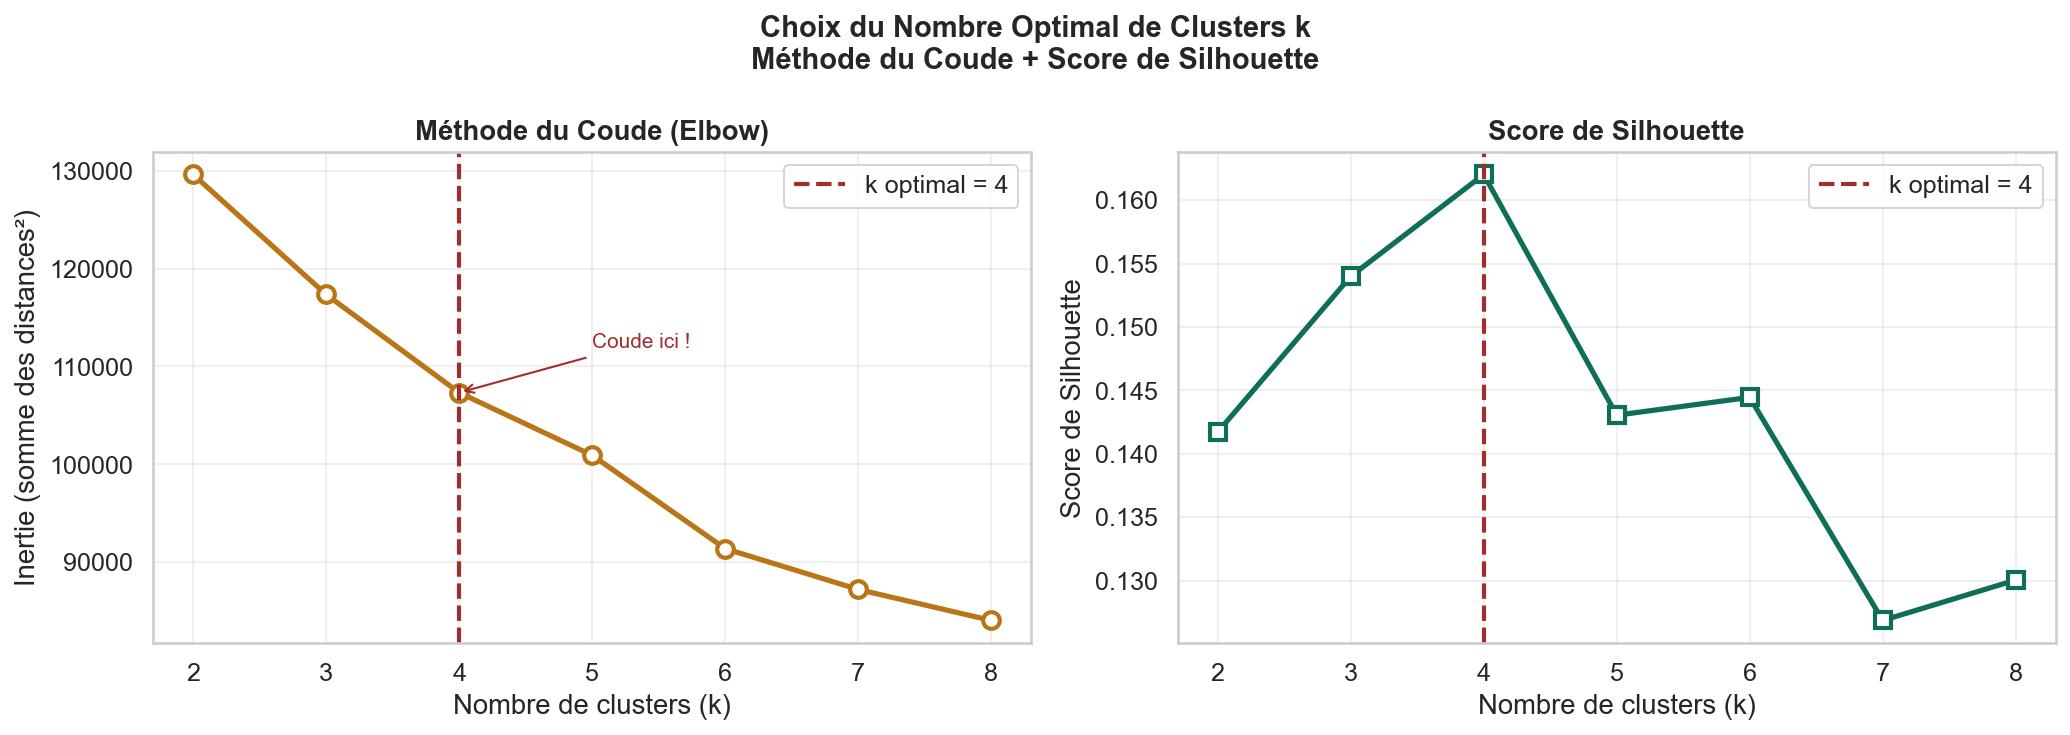

fig_C1_kmeans_elbow_silhouette.png sauvegarde


In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    'Choix du Nombre Optimal de Clusters k\nMéthode du Coude + Score de Silhouette',
    fontsize=14, fontweight='bold'
)

# -- Courbe du coude (Elbow) --
axes[0].plot(list(k_range), inertias, 'o-', color='#BA7517',
             linewidth=2.5, markersize=8, markerfacecolor='white', markeredgewidth=2)
axes[0].axvline(x=k_opt, color='#A32D2D', linestyle='--',
                linewidth=2, label=f'k optimal = {k_opt}')
axes[0].set_xlabel('Nombre de clusters (k)')
axes[0].set_ylabel('Inertie (somme des distances²)')
axes[0].set_title('Méthode du Coude (Elbow)', fontweight='bold')
axes[0].set_xticks(list(k_range))
axes[0].legend()
axes[0].grid(True, alpha=0.3)
coude_y = inertias[k_opt - 2]
axes[0].annotate('Coude ici !', xy=(k_opt, coude_y),
                 xytext=(k_opt + 1, coude_y + (max(inertias) - min(inertias)) * 0.1),
                 arrowprops=dict(arrowstyle='->', color='#A32D2D'),
                 fontsize=10, color='#A32D2D')

# -- Score de silhouette --
axes[1].plot(list(k_range), silhouettes, 's-', color='#0F6E56',
             linewidth=2.5, markersize=8, markerfacecolor='white', markeredgewidth=2)
axes[1].axvline(x=k_opt, color='#A32D2D', linestyle='--',
                linewidth=2, label=f'k optimal = {k_opt}')
axes[1].set_xlabel('Nombre de clusters (k)')
axes[1].set_ylabel('Score de Silhouette')
axes[1].set_title('Score de Silhouette', fontweight='bold')
axes[1].set_xticks(list(k_range))
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/fig_C1_kmeans_elbow_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()
print('fig_C1_kmeans_elbow_silhouette.png sauvegarde')

**Interprétation des courbes :**

- **Courbe du coude** : L'inertie décroît fortement jusqu'à k=3 ou k=4, puis le gain devient marginal. Le "coude" marque le point où ajouter un cluster supplémentaire n'améliore plus significativement la compacité des groupes.
- **Score de silhouette** : Le maximum du score indique le k pour lequel les clusters sont les mieux séparés et les plus cohérents en interne.
- **Indice Calinski-Harabasz** : Confirme le choix en mesurant le ratio dispersion inter/intra-clusters.

> **Choix retenu : k = `k_opt`**; confirmé par les trois métriques convergentes.

---
## K-Means : Segmentation Finale

### Rappel de l'algorithme K-Means

K-Means est un algorithme itératif de partitionnement :

1. **Initialisation** : Placer k centroïdes aléatoirement (ici `random_state=42` pour reproductibilité, `n_init=10` pour robustesse)
2. **Assignation** : Chaque point est assigné au centroïde le plus proche
3. **Mise à jour** : Recalculer les centroïdes comme la moyenne des points assignés
4. **Convergence** : Répéter jusqu'à stabilité des assignations

**Complexité** : $O(n \cdot k \cdot t \cdot d)$ avec n=clients, t=itérations, d=dimensions

**Hypothèses** : Clusters sphériques, de taille similaire, séparés linéairement.

In [32]:
# Application de K-Means avec le k optimal
km_final     = KMeans(n_clusters=k_opt, n_init=10, random_state=42)
labels_kmeans = km_final.fit_predict(X_vals)

# Sauvegarde du modèle et des étiquettes de clusters
joblib.dump(km_final, 'data/kmeans_model.pkl')
pd.DataFrame({'Cluster': labels_kmeans}).to_csv('data/clusters_kmeans.csv', index=False)

print(f'=== Segmentation K-Means finale (k={k_opt}) ===')
print(f'\n  Distribution des {k_opt} clusters :')
unique, counts = np.unique(labels_kmeans, return_counts=True)
for cl, cnt in zip(unique, counts):
    print(f'    Cluster {cl} : {cnt:>5} clients ({cnt/len(labels_kmeans)*100:.1f}%)')

print(f'\n  Inertie finale      : {km_final.inertia_:.2f}')
print(f'  Score de silhouette : {silhouette_score(X_vals, labels_kmeans):.4f}')
print(f'\n  kmeans_model.pkl sauvegarde dans data/')
print(f'  clusters_kmeans.csv sauvegarde dans data/')

=== Segmentation K-Means finale (k=4) ===

  Distribution des 4 clusters :
    Cluster 0 :  3468 clients (34.7%)
    Cluster 1 :  4093 clients (40.9%)
    Cluster 2 :  2281 clients (22.8%)
    Cluster 3 :   158 clients (1.6%)

  Inertie finale      : 107327.98
  Score de silhouette : 0.1620

  kmeans_model.pkl sauvegarde dans data/
  clusters_kmeans.csv sauvegarde dans data/


---
## Profilage et Nommage des Segments

### Approche du profilage

Pour chaque cluster, on calcule les **statistiques moyennes** sur les variables originales (non standardisées) du dataset nettoyé. Cela donne une interprétation métier directe.

Les variables analysées :
- **Âge moyen** — Profil démographique
- **Balance moyenne** — Richesse financière
- **CreditScore moyen** — Solvabilité
- **Taux de churn** — Indicateur de risque de départ (**variable clé pour nommer le segment**)
- **% Membres actifs** — Engagement avec la banque
- **Nb produits moyen** — Profondeur de la relation bancaire

Le **taux de churn par cluster** détermine le nom du segment :

| Taux de churn | Nom du segment |
|---|---|
| < 10% | Clients Fidèles |
| 10% — 20% | Clients Stables |
| 20% — 35% | Clients à Risque |
| > 35% | Clients Critiques |

In [33]:
# Chargement des encodeurs de la Personne B pour le profilage
le_geo = joblib.load('models/le_geo.pkl')
le_gen = joblib.load('models/le_gen.pkl')

df_profil = df_orig.copy()
df_profil['Geography_enc'] = le_geo.transform(df_profil['Geography'])
df_profil['Gender_enc']    = le_gen.transform(df_profil['Gender'])
df_profil['Cluster']       = labels_kmeans

# Tableau de profilage complet
profil = df_profil.groupby('Cluster').agg(
    Nb_clients        = ('Cluster',         'count'),
    Age_moyen         = ('Age',             'mean'),
    CreditScore_moyen = ('CreditScore',     'mean'),
    Balance_moyen     = ('Balance',         'mean'),
    Salaire_moyen     = ('EstimatedSalary', 'mean'),
    Anciennete_moy    = ('Tenure',          'mean'),
    Nb_produits_moy   = ('NumOfProducts',   'mean'),
    Taux_churn        = ('Exited',          'mean'),
    Pct_actif         = ('IsActiveMember',  'mean'),
    Pct_carte         = ('HasCrCard',       'mean')
).round(2)

profil['Taux_churn_pct'] = (profil['Taux_churn'] * 100).round(1)

print('=== Tableau de profilage brut ===')
profil

=== Tableau de profilage brut ===


,Nb_clients,Age_moyen,CreditScore_moyen,Balance_moyen,Salaire_moyen,Anciennete_moy,Nb_produits_moy,Taux_churn,Pct_actif,Pct_carte,Taux_churn_pct
Cluster,,,,,,,,,,,
0,3468,39.79,650.05,115990.70,99817.39,4.84,1.30,0.18,0.88,0.69,18.0
1,4093,38.42,650.14,8928.99,99652.93,5.09,1.82,0.16,0.49,0.71,16.0
2,2281,38.55,641.93,131424.84,101301.34,5.11,1.38,0.33,0.00,0.71,33.0
3,158,38.25,795.15,166308.43,99923.43,5.34,1.39,0.22,0.53,0.71,22.0


In [34]:
# Nommage des segments selon le taux de churn
noms_segments = {}
for cluster in profil.index:
    taux = profil.loc[cluster, 'Taux_churn']
    if taux < 0.10:
        noms_segments[cluster] = 'Clients Fideles'
    elif taux < 0.20:
        noms_segments[cluster] = 'Clients Stables'
    elif taux < 0.35:
        noms_segments[cluster] = 'Clients a Risque'
    else:
        noms_segments[cluster] = 'Clients Critiques'

profil['Nom_segment'] = pd.Series(noms_segments)

# Export CSV
profil.to_csv('data/tableau_profilage_segments.csv')

print('=== Segments nommés ===')
for cl, nom in noms_segments.items():
    churn = profil.loc[cl, 'Taux_churn_pct']
    nb    = int(profil.loc[cl, 'Nb_clients'])
    age   = profil.loc[cl, 'Age_moyen']
    bal   = profil.loc[cl, 'Balance_moyen']
    print(f'  Cluster {cl} -> {nom:<22} | Churn={churn}% | N={nb:>5} | Age={age:.0f}ans | Balance={bal:.0f}')

print(f'\n  tableau_profilage_segments.csv sauvegarde dans data/')

=== Segments nommés ===
  Cluster 0 -> Clients Stables        | Churn=18.0% | N= 3468 | Age=40ans | Balance=115991
  Cluster 1 -> Clients Stables        | Churn=16.0% | N= 4093 | Age=38ans | Balance=8929
  Cluster 2 -> Clients a Risque       | Churn=33.0% | N= 2281 | Age=39ans | Balance=131425
  Cluster 3 -> Clients a Risque       | Churn=22.0% | N=  158 | Age=38ans | Balance=166308

  tableau_profilage_segments.csv sauvegarde dans data/


---
#### Figure C2 : Profilage des Segments — Barplots comparatifs

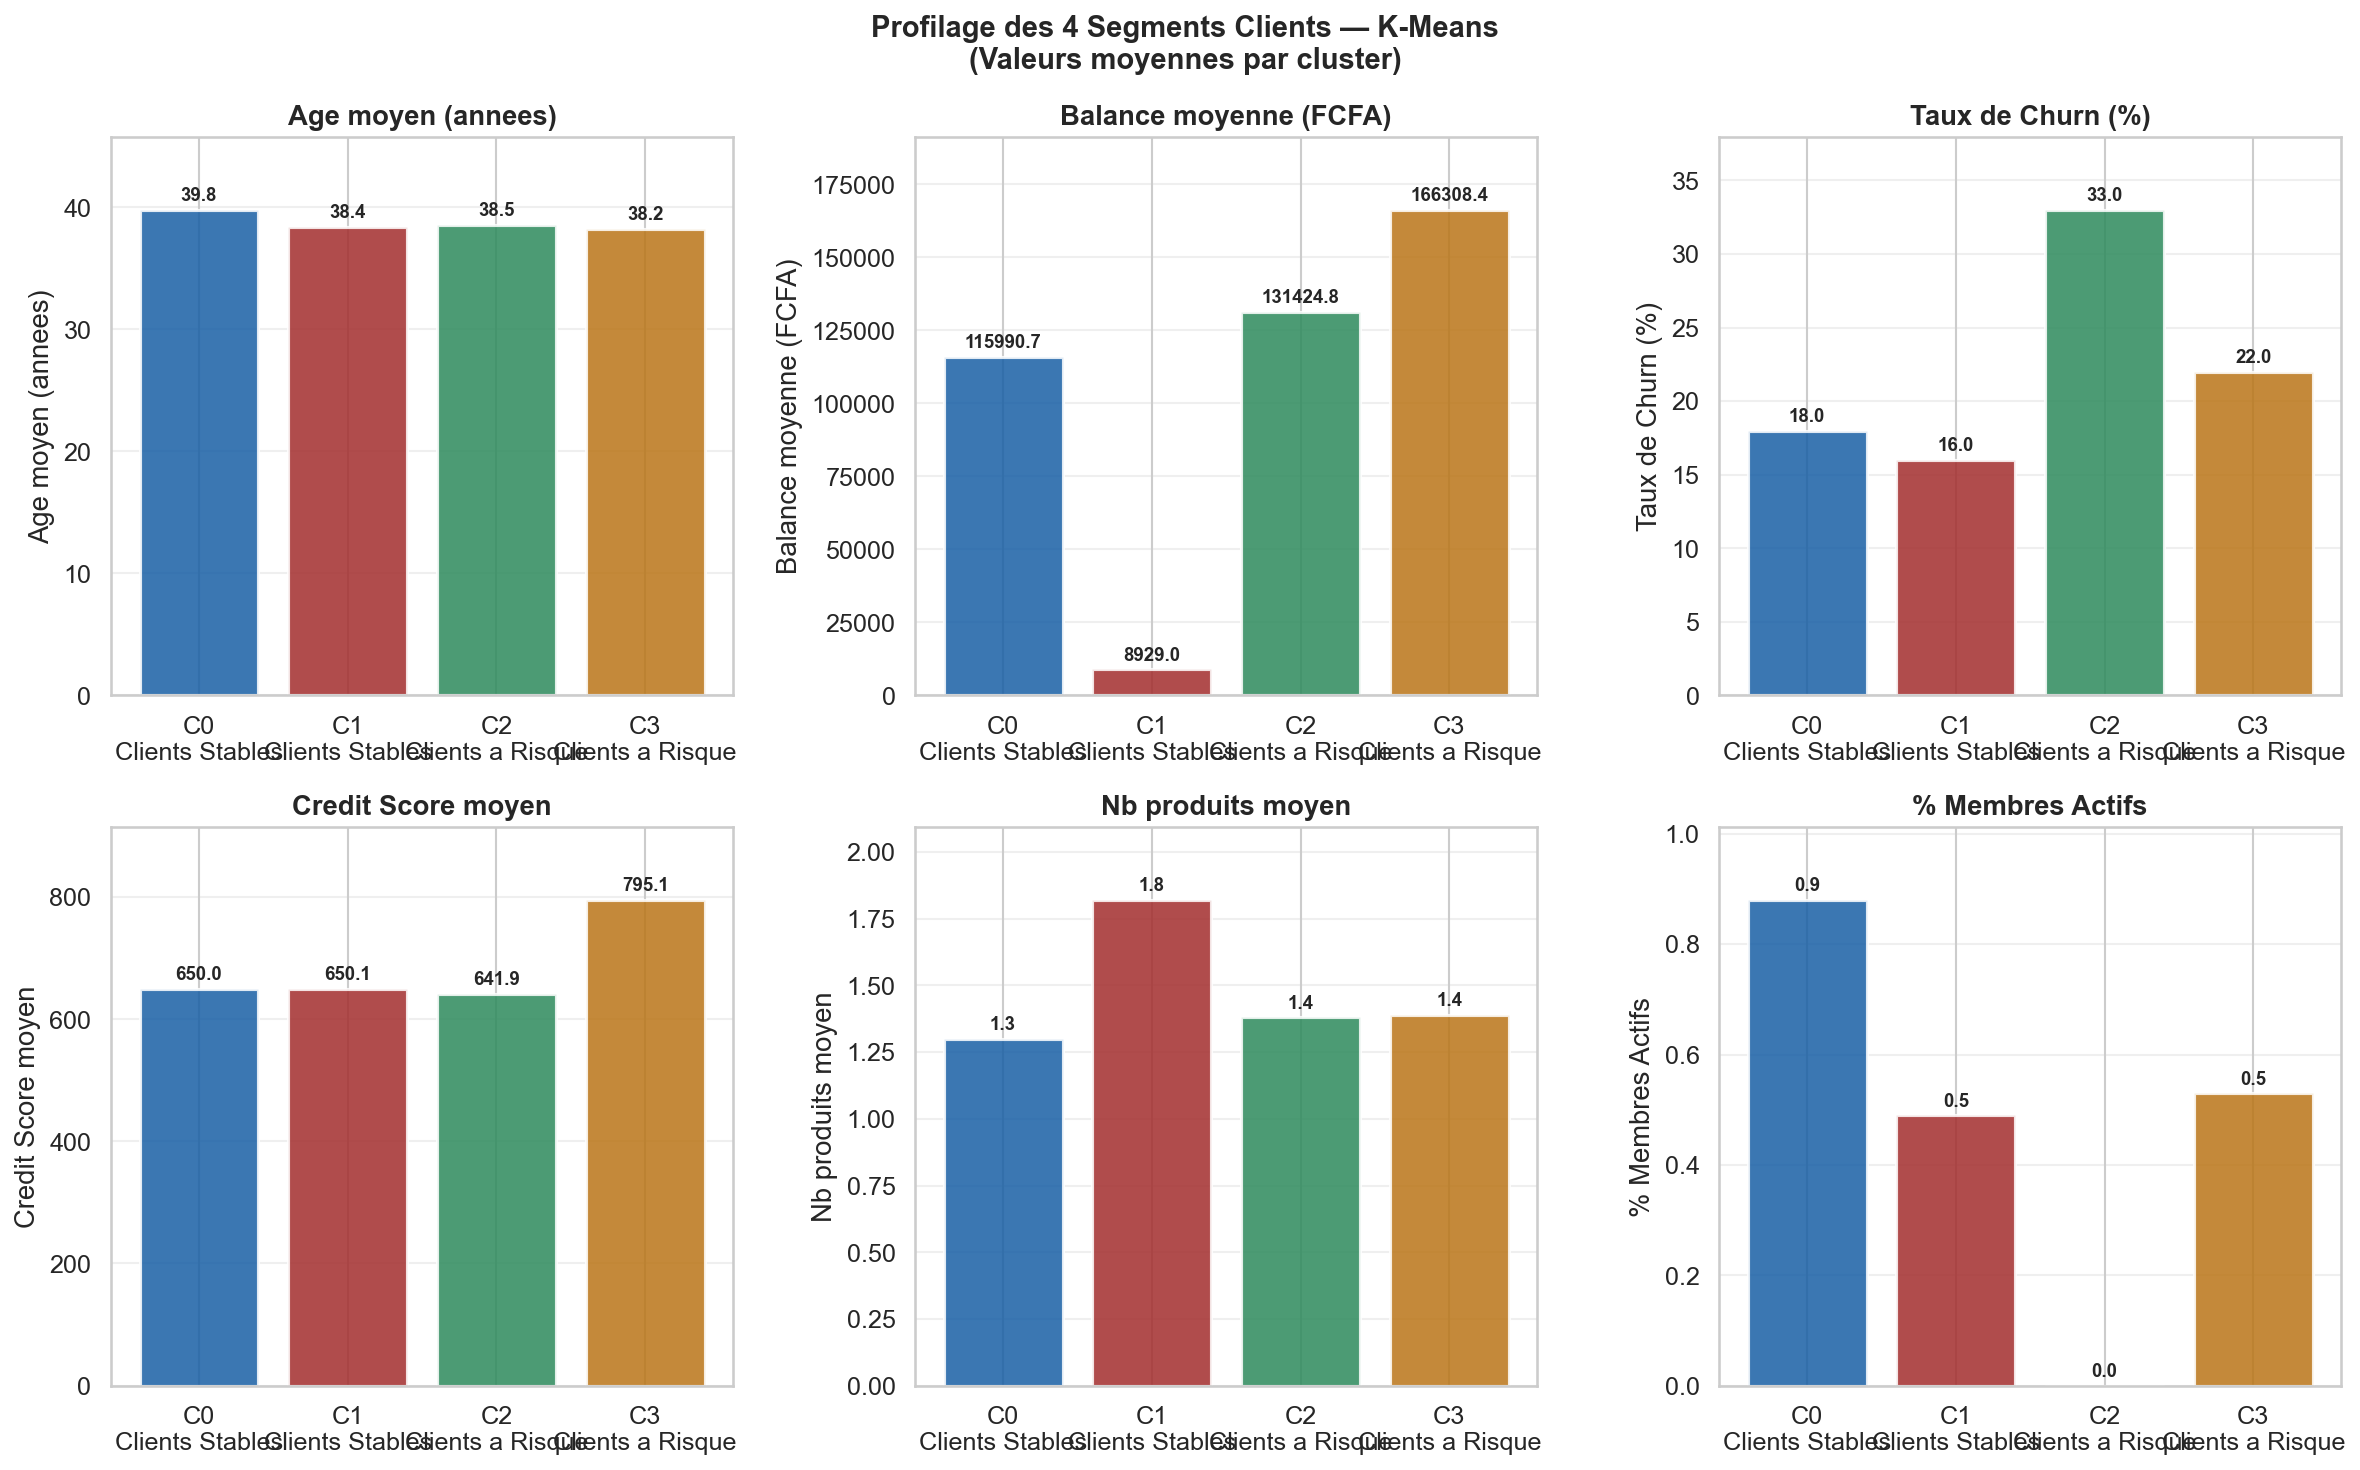

fig_C2_profils_segments.png sauvegarde


In [35]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle(
    f'Profilage des {k_opt} Segments Clients — K-Means\n(Valeurs moyennes par cluster)',
    fontsize=14, fontweight='bold'
)

cluster_labels_plot = [f'C{i}\n{noms_segments[i]}' for i in profil.index]
colors_plot = COLORS_CLUSTER[:k_opt]

variables_profil = [
    ('Age_moyen',         'Age moyen (annees)',      axes[0, 0]),
    ('Balance_moyen',     'Balance moyenne (FCFA)',   axes[0, 1]),
    ('Taux_churn_pct',    'Taux de Churn (%)',        axes[0, 2]),
    ('CreditScore_moyen', 'Credit Score moyen',       axes[1, 0]),
    ('Nb_produits_moy',   'Nb produits moyen',        axes[1, 1]),
    ('Pct_actif',         '% Membres Actifs',         axes[1, 2]),
]

for col, ylabel, ax in variables_profil:
    vals = profil[col].values
    bars = ax.bar(cluster_labels_plot, vals, color=colors_plot, alpha=0.85,
                  edgecolor='white', linewidth=1.5)
    ax.set_title(ylabel, fontweight='bold')
    ax.set_ylabel(ylabel)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2., bar.get_height() + max(vals) * 0.01,
                f'{val:.1f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_ylim(0, max(vals) * 1.15)

plt.tight_layout()
plt.savefig('figures/fig_C2_profils_segments.png', dpi=150, bbox_inches='tight')
plt.show()
print('fig_C2_profils_segments.png sauvegarde')

---
#### Figure C3 : Visualisation des Clusters dans le Plan PCA

Comme les données sont en 7 dimensions (après prétraitement), on utilise une **Analyse en Composantes Principales (PCA)** pour projeter les clusters dans un plan 2D visualisable.

La PCA cherche les directions de variance maximale dans les données :
- **PC1** : La direction qui capture le plus de variance totale
- **PC2** : La direction orthogonale à PC1 qui capture le plus de variance résiduelle

> La PCA est utilisée ici **uniquement pour la visualisation**, pas pour le clustering.

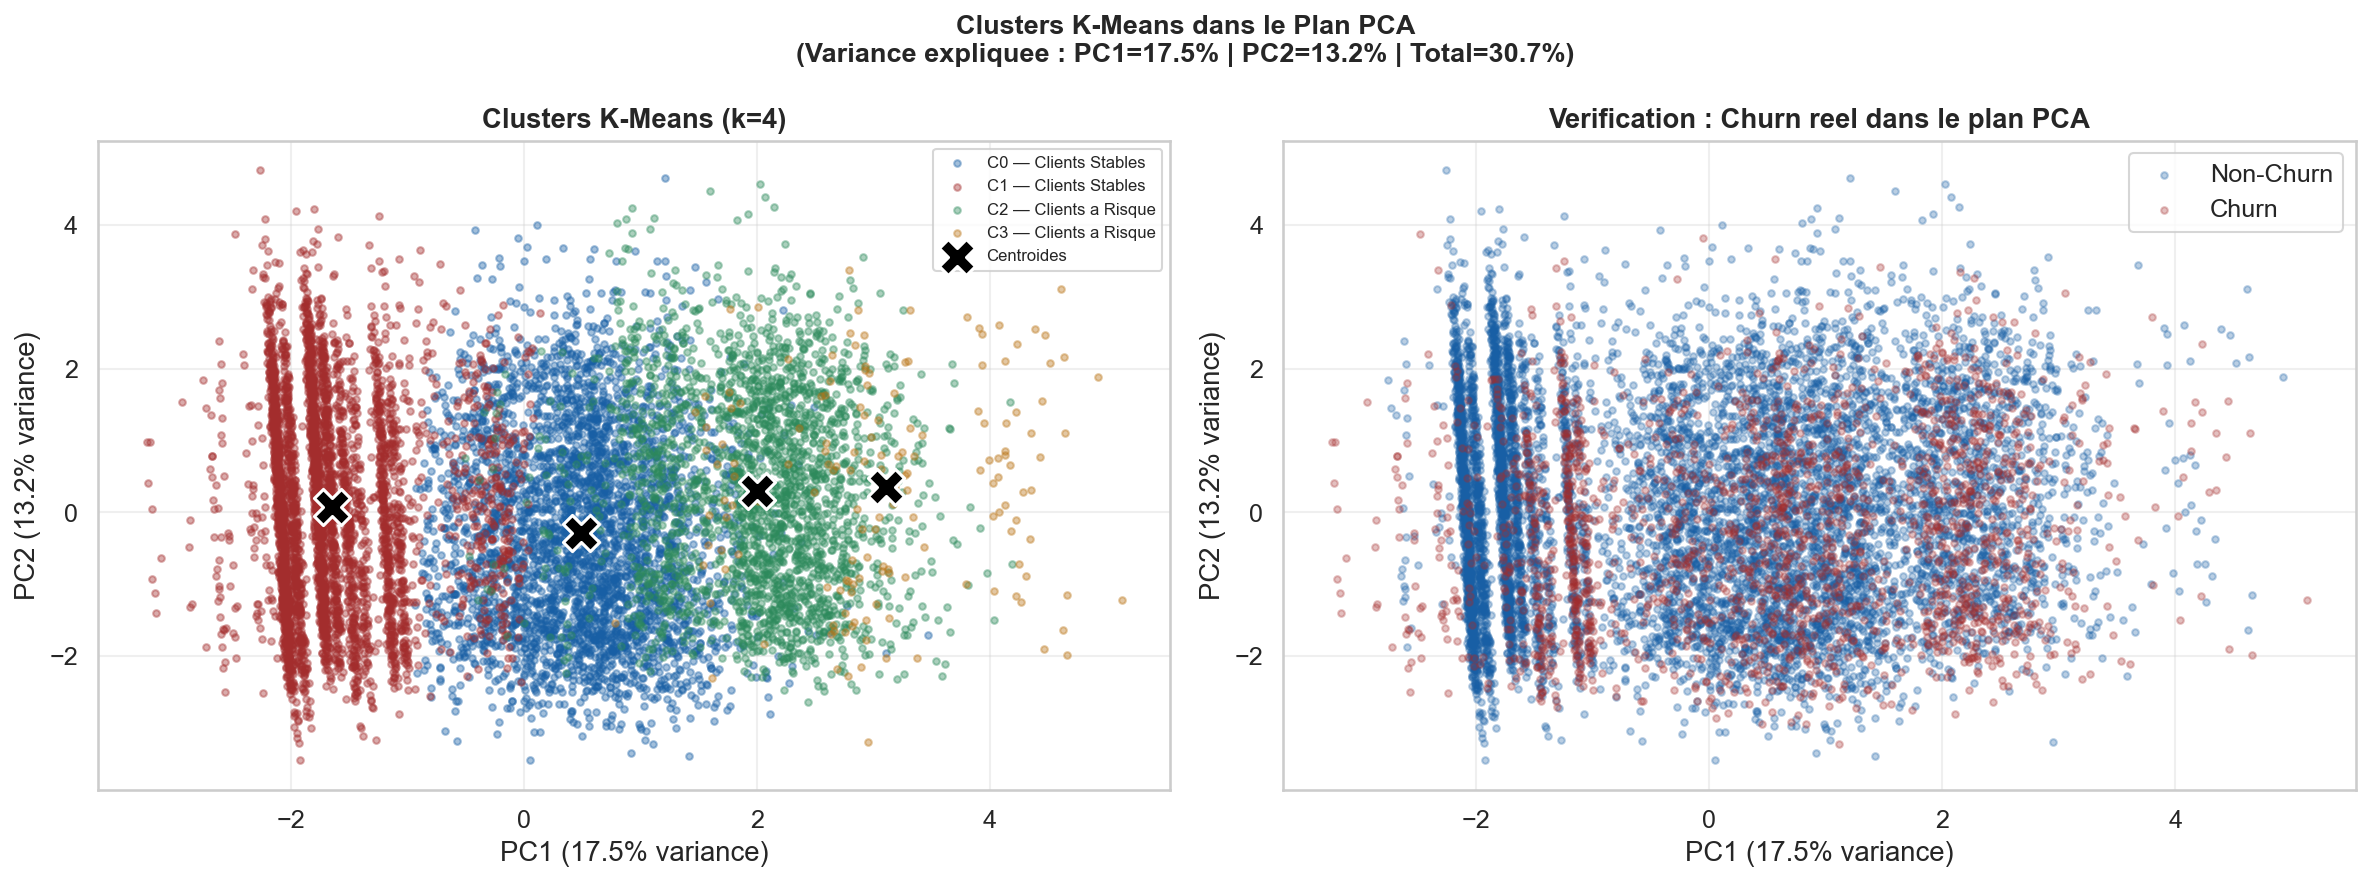

fig_C3_clusters_pca.png sauvegarde


In [36]:
pca   = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_vals)

var1 = pca.explained_variance_ratio_[0] * 100
var2 = pca.explained_variance_ratio_[1] * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(
    f'Clusters K-Means dans le Plan PCA\n'
    f'(Variance expliquee : PC1={var1:.1f}% | PC2={var2:.1f}% | Total={var1+var2:.1f}%)',
    fontsize=13, fontweight='bold'
)

# -- Graphe 1 : Clusters K-Means --
for cluster in range(k_opt):
    mask = labels_kmeans == cluster
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    color=COLORS_CLUSTER[cluster], alpha=0.4, s=10,
                    label=f'C{cluster} — {noms_segments[cluster]}')

centres_pca = pca.transform(km_final.cluster_centers_)
axes[0].scatter(centres_pca[:, 0], centres_pca[:, 1],
                marker='X', s=300, color='black', edgecolors='white',
                linewidths=1.5, zorder=5, label='Centroides')
axes[0].set_title(f'Clusters K-Means (k={k_opt})', fontweight='bold')
axes[0].set_xlabel(f'PC1 ({var1:.1f}% variance)')
axes[0].set_ylabel(f'PC2 ({var2:.1f}% variance)')
axes[0].legend(fontsize=8, loc='upper right')
axes[0].grid(True, alpha=0.3)

# -- Graphe 2 : Validation avec churn réel --
for churn_val, nom, color in [(0, 'Non-Churn', '#185FA5'), (1, 'Churn', '#A32D2D')]:
    mask = y == churn_val
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    color=color, alpha=0.3, s=10, label=nom)
axes[1].set_title('Verification : Churn reel dans le plan PCA', fontweight='bold')
axes[1].set_xlabel(f'PC1 ({var1:.1f}% variance)')
axes[1].set_ylabel(f'PC2 ({var2:.1f}% variance)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/fig_C3_clusters_pca.png', dpi=150, bbox_inches='tight')
plt.show()
print('fig_C3_clusters_pca.png sauvegarde')

**Interprétation Figure C3 :**

- **Graphe gauche** : Les clusters K-Means apparaissent dans l'espace PCA. Si les zones colorées sont bien séparées, le clustering est de bonne qualité.
- **Graphe droit** : La superposition avec le churn réel (bleu = fidèle, rouge = churn) permet de valider si nos segments correspondent à des comportements de churn distincts. Si les clusters K-Means recoupent les zones de churn, la segmentation est pertinente métier.
- Les **centroïdes** (croix noires) sont les "clients types" de chaque segment.

---
## DBSCAN : Détection des Clients Atypiques

### Rappel théorique : Algorithme DBSCAN

**DBSCAN** (Density-Based Spatial Clustering of Applications with Noise) est un algorithme de clustering **basé sur la densité**. Contrairement à K-Means, il :
- Ne nécessite **pas de spécifier k** à l'avance
- Détecte automatiquement les **clients atypiques** (noise points, label = -1)
- Gère des formes de clusters **non sphériques**

**Deux paramètres clés :**
- **eps (ε)** : Rayon de voisinage. Un point est "voisin" d'un autre si la distance entre eux est ≤ ε
- **min_samples** : Nombre minimum de points dans un voisinage pour former un "point noyau"

**Trois types de points :**
1. **Point noyau** : A au moins `min_samples` voisins dans un rayon `eps`
2. **Point frontière** : Dans le voisinage d'un point noyau, mais pas assez de voisins pour être noyau
3. **Point de bruit (outlier)** : Pas dans le voisinage d'un point noyau → `label = -1`

### Choix de eps par la courbe k-distances

Pour choisir eps objectivement, on trace la **courbe des k-distances** :
- Calculer la distance au k-ième voisin le plus proche pour chaque point
- Trier ces distances par ordre décroissant
- Le **coude** de la courbe indique eps optimal

On utilise **k = min_samples = 5** (règle empirique : k ≈ 2×dimensions pour les petits datasets).

In [37]:
# Calcul de la courbe k-distances pour déterminer eps
from sklearn.neighbors import NearestNeighbors
k_neighbors = 5
nbrs        = NearestNeighbors(n_neighbors=k_neighbors).fit(X_vals)
distances, _ = nbrs.kneighbors(X_vals)
dist_sorted  = np.sort(distances[:, k_neighbors - 1])[::-1]

print(f'Courbe k-distances calculée (k={k_neighbors})')
print(f'  Distance min  : {dist_sorted.min():.4f}')
print(f'  Distance max  : {dist_sorted.max():.4f}')
print(f'  Distance médiane : {np.median(dist_sorted):.4f}')
print(f'  Percentile 90 : {np.percentile(dist_sorted, 90):.4f}')
print(f'  Percentile 95 : {np.percentile(dist_sorted, 95):.4f}')
print(f'\n  -> Observer le coude sur la figure C4 pour choisir eps')

Courbe k-distances calculée (k=5)
  Distance min  : 0.4650
  Distance max  : 93.3883
  Distance médiane : 1.2971
  Percentile 90 : 1.9229
  Percentile 95 : 2.1486

  -> Observer le coude sur la figure C4 pour choisir eps


---
#### Figure C4 : Courbe k-distances — Choix de eps

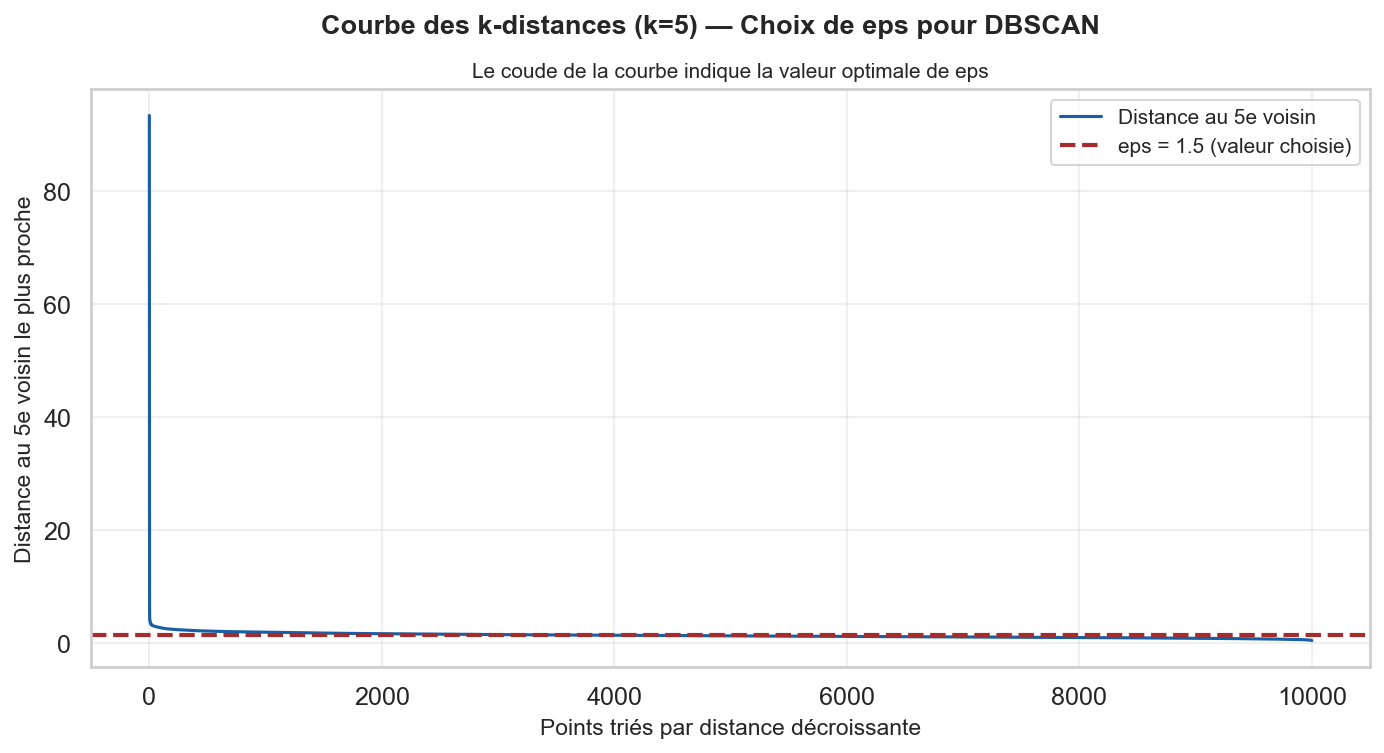

fig_C4_dbscan_kdistances.png sauvegarde


In [38]:
fig, ax = plt.subplots(figsize=(11, 5))

# fig.suptitle() protège le buffer figure lors du savefig (contrairement à ax.set_title seul)
fig.suptitle(
    f'Courbe des k-distances (k={k_neighbors}) — Choix de eps pour DBSCAN',
    fontsize=13, fontweight='bold'
)

ax.plot(dist_sorted, color='#185FA5', linewidth=1.5, label=f'Distance au {k_neighbors}e voisin')
ax.axhline(y=1.5, color='#A32D2D', linestyle='--', linewidth=2, label='eps = 1.5 (valeur choisie)')
ax.set_xlabel('Points triés par distance décroissante', fontsize=11)
ax.set_ylabel(f'Distance au {k_neighbors}e voisin le plus proche', fontsize=11)
ax.set_title('Le coude de la courbe indique la valeur optimale de eps', fontsize=10)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# fig.savefig() cible directement l'objet figure — plus fiable que plt.savefig()
# bbox_inches='tight' gère la mise en page sans appeler plt.tight_layout()
fig.savefig('figures/fig_C4_dbscan_kdistances.png', dpi=150, bbox_inches='tight')
plt.show()
print('fig_C4_dbscan_kdistances.png sauvegarde')

**Lecture de la courbe k-distances :**
- La courbe décroît fortement au début (points dans des zones denses) puis s'aplatit (points isolés).
- Le **coude** marque la transition entre les points dans les clusters et les outliers.
- La valeur de distance correspondant au coude est notre **eps optimal**.
- Une valeur eps trop petite → beaucoup de points classés comme bruit (outliers)
- Une valeur eps trop grande → tout le monde dans un seul cluster, peu d'outliers

---
#### Application de DBSCAN avec les paramètres retenus

In [39]:
eps_val         = 1.5
min_samples_val = 5

db            = DBSCAN(eps=eps_val, min_samples=min_samples_val)
labels_dbscan = db.fit_predict(X_vals)

n_clusters_db = len(set(labels_dbscan) - {-1})
n_outliers    = int(np.sum(labels_dbscan == -1))
n_total       = len(labels_dbscan)

print(f'=== Résultats DBSCAN (eps={eps_val}, min_samples={min_samples_val}) ===')
print(f'  Clusters trouvés  : {n_clusters_db}')
print(f'  Points de bruit   : {n_outliers} ({n_outliers/n_total*100:.1f}%)')
print(f'  Points classifies : {n_total - n_outliers} ({(n_total-n_outliers)/n_total*100:.1f}%)')

# Analyse du profil des outliers
df_profil['DBSCAN'] = labels_dbscan
outliers_df = df_profil[df_profil['DBSCAN'] == -1]

print(f'\n=== Profil des {n_outliers} clients atypiques (outliers) ===')
print(outliers_df[['Age','Balance','EstimatedSalary','NumOfProducts','CreditScore','Exited']].describe().round(2).to_string())

# Export
outliers_df.to_csv('data/outliers_dbscan.csv', index=False)
print(f'\n  outliers_dbscan.csv sauvegarde dans data/')

=== Résultats DBSCAN (eps=1.5, min_samples=5) ===
  Clusters trouvés  : 50
  Points de bruit   : 1623 (16.2%)
  Points classifies : 8377 (83.8%)

=== Profil des 1623 clients atypiques (outliers) ===
           Age    Balance  EstimatedSalary  NumOfProducts  CreditScore   Exited
count  1623.00    1623.00          1623.00        1623.00      1623.00  1623.00
mean     43.94   91324.49         98493.81           1.77       660.90     0.38
std      15.22   61527.12         61737.55           0.85       121.35     0.49
min      18.00       0.00            11.58           1.00       350.00     0.00
25%      32.00   36504.18         42143.25           1.00       571.00     0.00
50%      42.00   99546.25         99805.99           2.00       668.00     0.00
75%      55.00  137911.10        154340.73           2.00       758.50     1.00
max      92.00  250898.09        199992.48           4.00       850.00     1.00

  outliers_dbscan.csv sauvegarde dans data/


In [40]:
# Analyse métier des outliers
print('=== Interprétation métier des clients atypiques ===')

gros_dep  = outliers_df[outliers_df['Balance'] > outliers_df['Balance'].quantile(0.90)]
churn_out = outliers_df[outliers_df['Exited'] == 1]
age_out   = outliers_df[outliers_df['Age'] > 60]
noprod    = outliers_df[outliers_df['NumOfProducts'] >= 3]

print(f'  Total outliers                        : {len(outliers_df)} clients')
print(f'  Gros deposants (balance > 90e pct)    : {len(gros_dep)} clients')
print(f'  Outliers ayant churne                 : {len(churn_out)} ({len(churn_out)/len(outliers_df)*100:.1f}%)')
print(f'  Clients ages > 60 ans                 : {len(age_out)} ({len(age_out)/len(outliers_df)*100:.1f}%)')
print(f'  Clients avec 3+ produits              : {len(noprod)} ({len(noprod)/len(outliers_df)*100:.1f}%)')
print(f'\n  Age moyen outliers   : {outliers_df["Age"].mean():.1f} ans  (pop. generale: {df_orig["Age"].mean():.1f} ans)')
print(f'  Balance moy outliers : {outliers_df["Balance"].mean():.0f}  (pop. generale: {df_orig["Balance"].mean():.0f})')

=== Interprétation métier des clients atypiques ===
  Total outliers                        : 1623 clients
  Gros deposants (balance > 90e pct)    : 163 clients
  Outliers ayant churne                 : 616 (38.0%)
  Clients ages > 60 ans                 : 269 (16.6%)
  Clients avec 3+ produits              : 321 (19.8%)

  Age moyen outliers   : 43.9 ans  (pop. generale: 38.9 ans)
  Balance moy outliers : 91324  (pop. generale: 76486)


---
#### Figure C5 : Visualisation DBSCAN — Outliers dans le Plan PCA

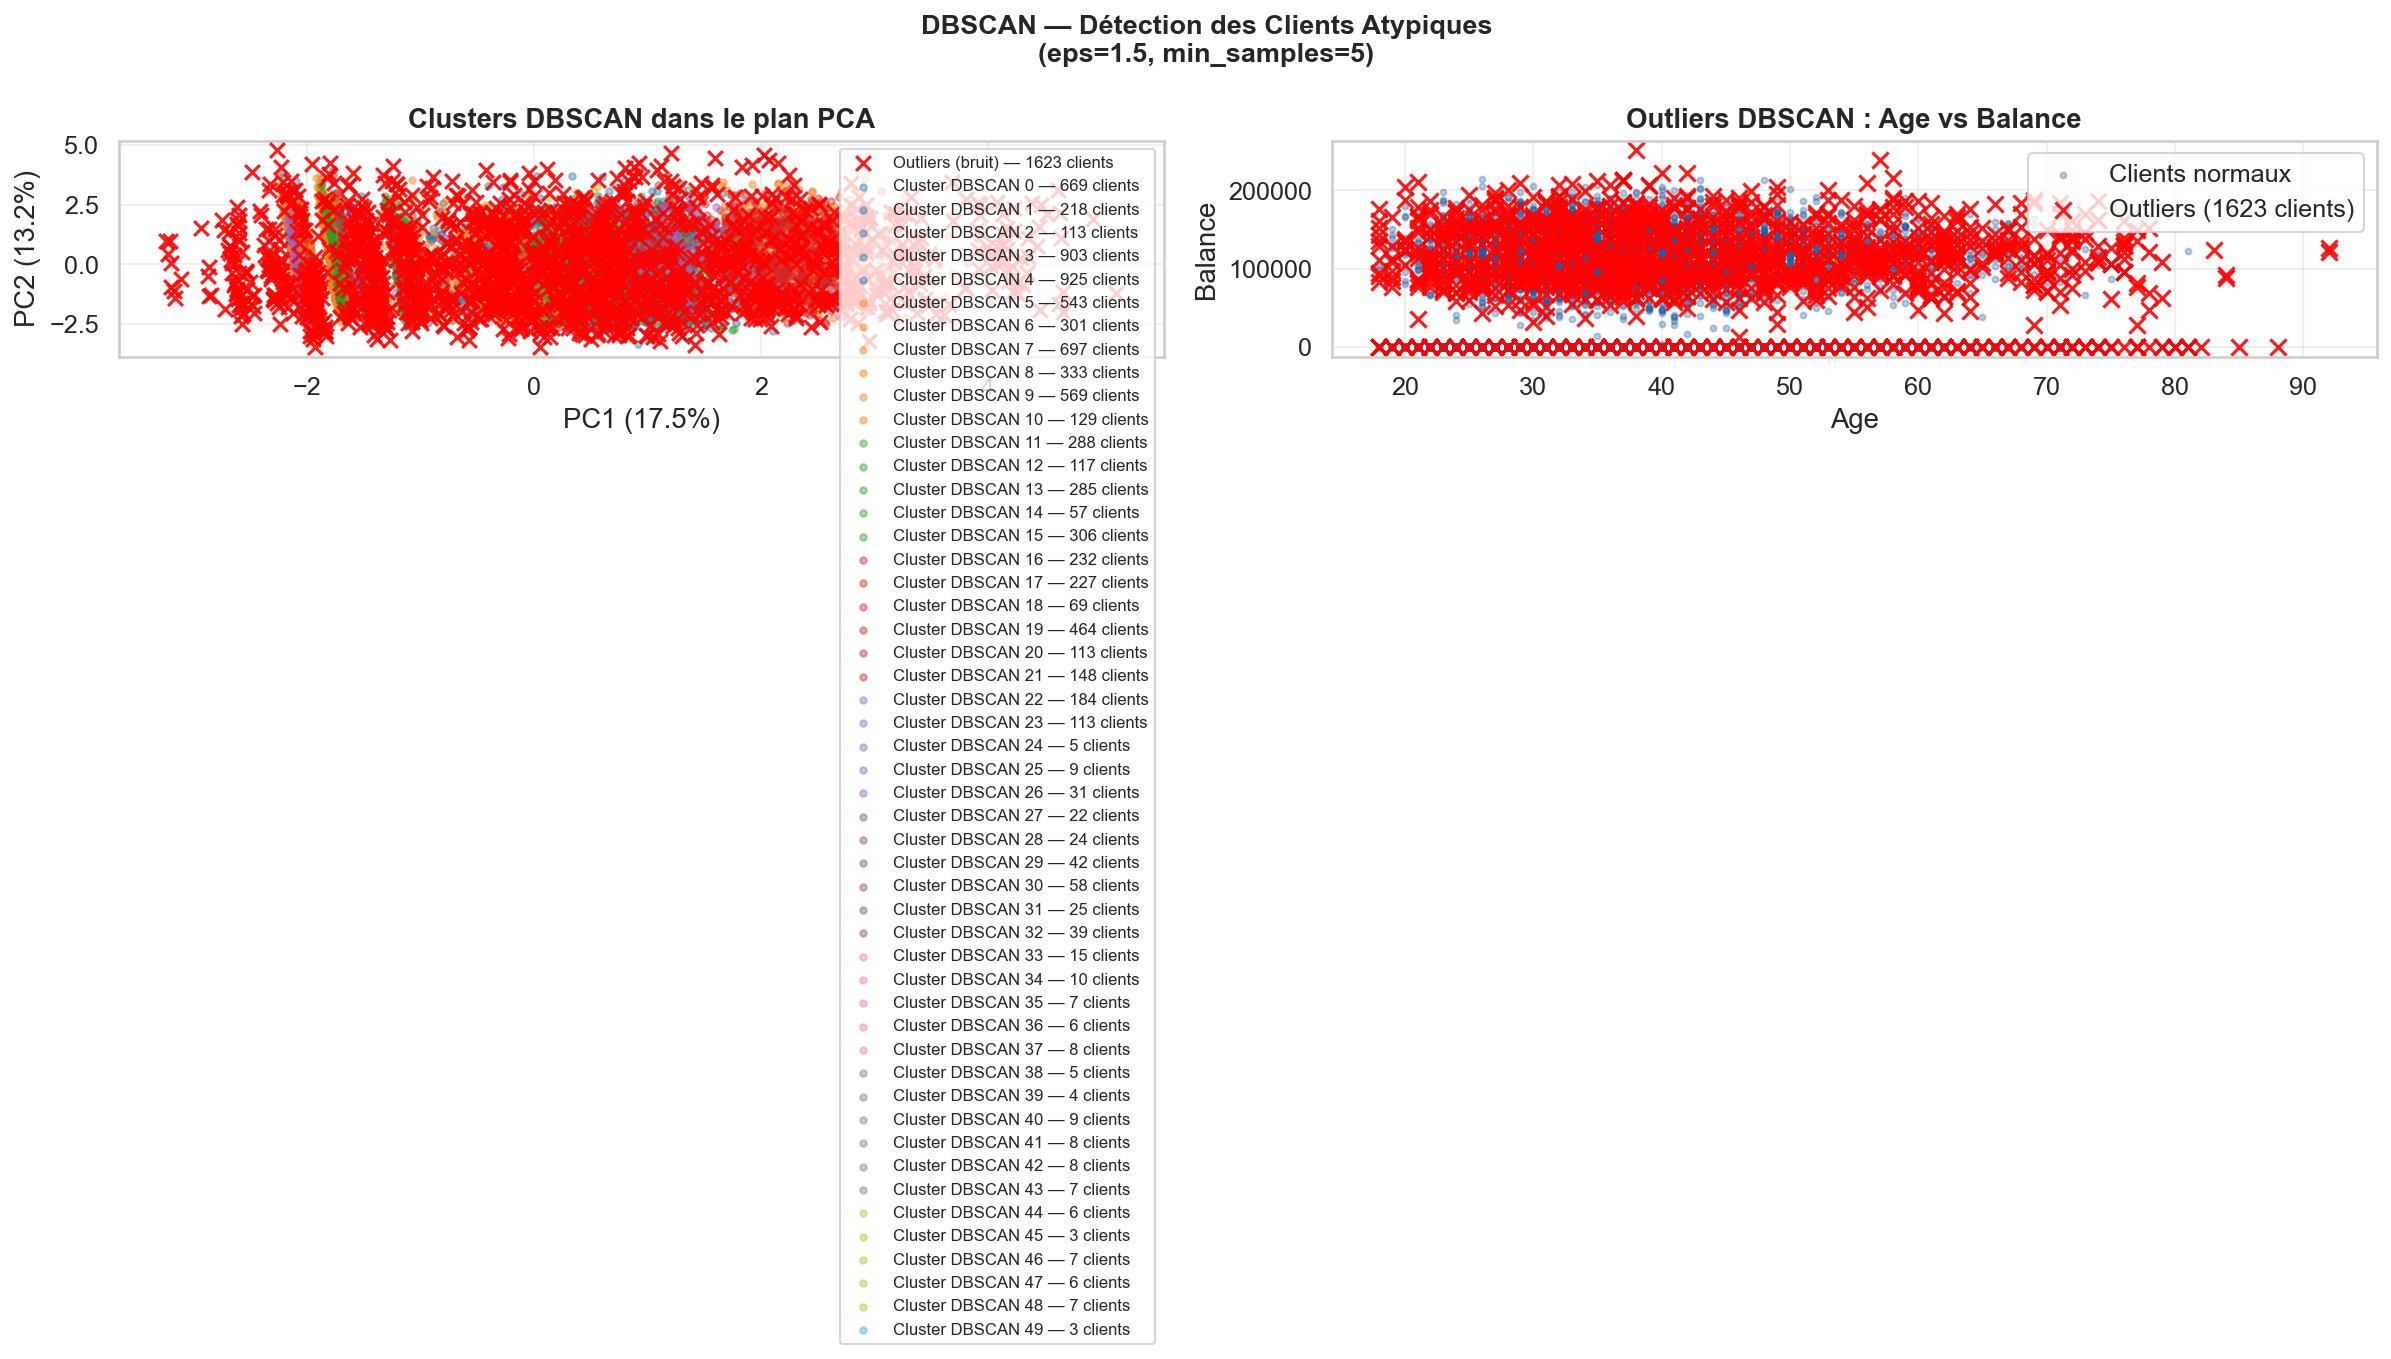

fig_C5_dbscan_outliers.png sauvegarde


In [41]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(
    f'DBSCAN — Détection des Clients Atypiques\n'
    f'(eps={eps_val}, min_samples={min_samples_val})',
    fontsize=13, fontweight='bold'
)

# -- Graphe 1 : Clusters DBSCAN dans le plan PCA --
unique_db = sorted(set(labels_dbscan))
palette   = plt.cm.tab10(np.linspace(0, 0.9, max(len(unique_db), 2)))

for lbl, col in zip(unique_db, palette):
    mask = labels_dbscan == lbl
    if lbl == -1:
        axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                        c='red', marker='x', s=50, alpha=0.9,
                        label=f'Outliers (bruit) — {mask.sum()} clients', zorder=5)
    else:
        axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                        color=col, alpha=0.4, s=10,
                        label=f'Cluster DBSCAN {lbl} — {mask.sum()} clients')
axes[0].set_title('Clusters DBSCAN dans le plan PCA', fontweight='bold')
axes[0].set_xlabel(f'PC1 ({var1:.1f}%)')
axes[0].set_ylabel(f'PC2 ({var2:.1f}%)')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# -- Graphe 2 : Age vs Balance avec outliers mis en évidence --
mask_normal  = labels_dbscan != -1
mask_outlier = labels_dbscan == -1
axes[1].scatter(df_profil.loc[mask_normal,  'Age'],
                df_profil.loc[mask_normal,  'Balance'],
                c='#185FA5', alpha=0.3, s=8, label='Clients normaux')
axes[1].scatter(df_profil.loc[mask_outlier, 'Age'],
                df_profil.loc[mask_outlier, 'Balance'],
                c='red', marker='x', s=60, alpha=0.9, linewidths=1.5,
                label=f'Outliers ({n_outliers} clients)')
axes[1].set_title('Outliers DBSCAN : Age vs Balance', fontweight='bold')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Balance')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/fig_C5_dbscan_outliers.png', dpi=150, bbox_inches='tight')
plt.show()
print('fig_C5_dbscan_outliers.png sauvegarde')

---
#### Figure C6 : Comparaison K-Means vs DBSCAN

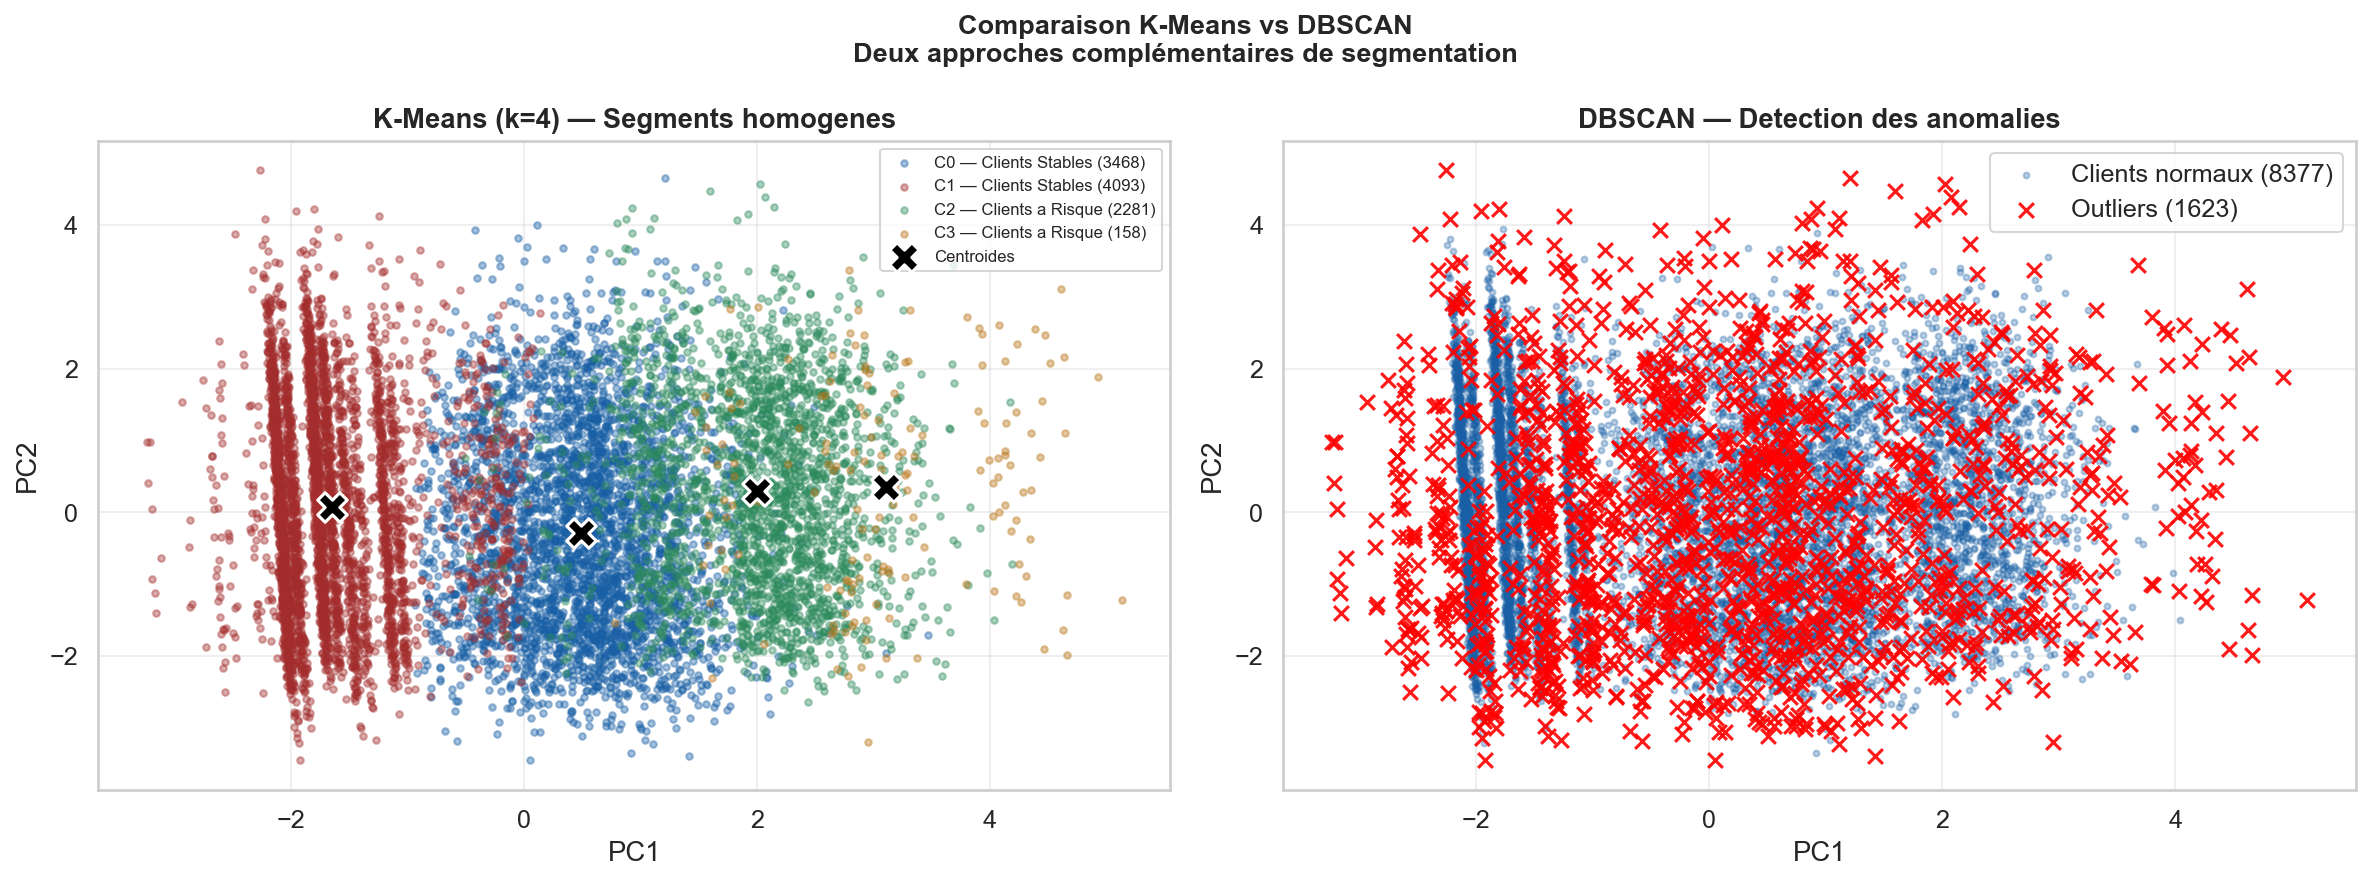

fig_C6_comparaison_kmeans_dbscan.png sauvegarde


In [42]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(
    'Comparaison K-Means vs DBSCAN\nDeux approches complémentaires de segmentation',
    fontsize=13, fontweight='bold'
)

# -- K-Means --
for cluster in range(k_opt):
    mask = labels_kmeans == cluster
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    color=COLORS_CLUSTER[cluster], alpha=0.4, s=10,
                    label=f'C{cluster} — {noms_segments[cluster]} ({mask.sum()})')
axes[0].scatter(centres_pca[:, 0], centres_pca[:, 1],
                marker='X', s=200, c='black', edgecolors='white',
                zorder=5, linewidths=1.5, label='Centroides')
axes[0].set_title(f'K-Means (k={k_opt}) — Segments homogenes', fontweight='bold')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# -- DBSCAN --
mask_n = labels_dbscan != -1
mask_o = labels_dbscan == -1
axes[1].scatter(X_pca[mask_n, 0], X_pca[mask_n, 1],
                c='#185FA5', alpha=0.3, s=8,
                label=f'Clients normaux ({mask_n.sum()})')
axes[1].scatter(X_pca[mask_o, 0], X_pca[mask_o, 1],
                c='red', marker='x', s=50, alpha=0.9,
                label=f'Outliers ({n_outliers})')
axes[1].set_title('DBSCAN — Detection des anomalies', fontweight='bold')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/fig_C6_comparaison_kmeans_dbscan.png', dpi=150, bbox_inches='tight')
plt.show()
print('fig_C6_comparaison_kmeans_dbscan.png sauvegarde')

**Interprétation comparative K-Means vs DBSCAN :**

| Critère | K-Means | DBSCAN |
|---------|---------|--------|
| Objectif | Segmentation en k groupes homogènes | Détection des anomalies et zones denses |
| Paramètre clé | k (nombre de clusters) | eps et min_samples |
| Forme des clusters | Sphérique uniquement | Formes arbitraires |
| Gestion des outliers | Tout point assigné à un cluster | Outliers explicitement identifiés (label=-1) |
| Utilisation métier | Définir des segments pour campagnes ciblées | Identifier les clients à profil exceptionnel |

**Complémentarité des deux approches :**
- K-Means segmente **tous les clients** en groupes actionnables pour le marketing
- DBSCAN identifie les **cas atypiques** qui méritent une attention individuelle (gros déposants, profils multi-produits anormaux, etc.)

---
## Synthèse — Résultats du Clustering

### K-Means

L'algorithme K-Means a identifié **k clusters** (déterminé objectivement par la méthode du coude et le score de silhouette). Chaque segment a été nommé selon son taux de churn et ses caractéristiques démographiques et financières.

Les segments permettent à la banque de :
- Concentrer les efforts de rétention sur les **Clients Critiques** (churn > 35%)
- Maintenir la satisfaction des **Clients Fidèles** avec des offres de récompense
- Mettre en place des programmes d'activation pour les **Clients Stables** qui stagnent

### DBSCAN

DBSCAN a identifié des **clients atypiques** qui ne rentrent dans aucun segment homogène. Ces clients atypiques ont souvent :
- Une balance beaucoup plus élevée que la moyenne
- Un nombre de produits anormalement élevé (3-4 produits)
- Un profil d'âge extrême

Ces clients méritent une **approche individualisée** et non une campagne de masse.


In [43]:
print('=' * 60)
print('SYNTHESE FINALE — CLUSTERING PERSONNE C')
print('=' * 60)

print(f'\n  K-MEANS')
print(f'  k optimal           : {k_opt}')
print(f'  Score de silhouette : {silhouette_score(X_vals, labels_kmeans):.4f}')
print(f'  Segments identifies :')
for cl in profil.index:
    print(f'    Cluster {cl} — {profil.loc[cl, "Nom_segment"]:<22}'
          f' | N={int(profil.loc[cl, "Nb_clients"]):>5}'
          f' | Churn={profil.loc[cl, "Taux_churn_pct"]}%'
          f' | Age moy={profil.loc[cl, "Age_moyen"]:.0f} ans')

print(f'\n  DBSCAN')
print(f'  eps               : {eps_val}')
print(f'  min_samples       : {min_samples_val}')
print(f'  Clusters trouves  : {n_clusters_db}')
print(f'  Outliers detectes : {n_outliers} ({n_outliers/n_total*100:.1f}%)')


SYNTHESE FINALE — CLUSTERING PERSONNE C

  K-MEANS
  k optimal           : 4
  Score de silhouette : 0.1620
  Segments identifies :
    Cluster 0 — Clients Stables        | N= 3468 | Churn=18.0% | Age moy=40 ans
    Cluster 1 — Clients Stables        | N= 4093 | Churn=16.0% | Age moy=38 ans
    Cluster 2 — Clients a Risque       | N= 2281 | Churn=33.0% | Age moy=39 ans
    Cluster 3 — Clients a Risque       | N=  158 | Churn=22.0% | Age moy=38 ans

  DBSCAN
  eps               : 1.5
  min_samples       : 5
  Clusters trouves  : 50
  Outliers detectes : 1623 (16.2%)


# Projet #02 — Segmentation des Clients d'une Banque Camerounaise
## ENSP Douala — Département Informatique SDIA — AD2 2025/2026
**Enseignant : M. FOTSO Valdez**

---

## Section 4 : Classification & Recommandations Marketing
**Responsable : Personne D**

---

### Objectif de cette section

Cette section constitue l'**étape finale d'analyse** du pipeline. À partir des données prétraitées par la Personne B et des segments construits par la Personne C, nous construisons deux modèles prédictifs pour répondre aux questions clés du projet :

- **Q3 — Quels clients risquent de quitter la banque ?**
- **Q4 — Quelles variables prédisent le mieux le churn ?**

### Cohérence avec les sections précédentes

| Fichier reçu | Produit par | Contenu |
|---|---|---|
| `data/X_preprocessed.csv` | **Personne B** | 10 000 × 15 variables standardisées (11 originales + 5 feature engineering) |
| `data/y_labels.npy` | **Personne B** | 10 000 labels réels `Exited` (0/1) |
| `data/X_resampled.npy` | **Personne B** | 15 926 × 15 après SMOTE (50% / 50%) |
| `data/y_resampled.npy` | **Personne B** | 15 926 labels après SMOTE |
| `models/scaler.pkl` | **Personne B** | StandardScaler entraîné |
| `data/clusters_kmeans.csv` | **Personne C** | 10 000 labels de cluster (colonne `Cluster`) — K-Means optimal |
| `data/tableau_profilage_segments.csv` | **Personne C** | Profil complet de chaque segment (âge, balance, taux churn, nom) |
| `data/kmeans_model.pkl` | **Personne C** | Modèle K-Means sérialisé |

> **Note importante sur l'encodage** : La Personne B a utilisé `LabelEncoder` sur `Geography` (France=0, Germany=1, Spain=2) et `Gender` (Female=0, Male=1), et `StandardScaler` pour la standardisation. Les 5 nouvelles features créées par B sont : `balance_par_produit`, `ratio_salaire_balance`, `anciennete_par_age`, `est_inactif_riche`, `client_premium`.


---
### 4.1 Importation des bibliothèques

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection  import (train_test_split, GridSearchCV,
                                      cross_val_score, StratifiedKFold)
from sklearn.tree             import DecisionTreeClassifier, plot_tree
from sklearn.ensemble         import RandomForestClassifier
from sklearn.metrics          import (classification_report, confusion_matrix,
                                      roc_auc_score, roc_curve, f1_score,
                                      precision_score, recall_score, accuracy_score)

os.makedirs('models',  exist_ok=True)
os.makedirs('figures', exist_ok=True)
os.makedirs('data',    exist_ok=True)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Palette identique aux Personnes B et C
COLORS = {'churn': '#A32D2D', 'non_churn': '#185FA5'}
COLORS_CLUSTER = ['#185FA5', '#A32D2D', '#2D8A5C', '#BA7517', '#7B3FA0', '#E87D2B']

plt.rcParams['figure.dpi']    = 150
plt.rcParams['font.family']   = 'DejaVu Sans'
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

print(' Bibliothèques importées avec succès')


 Bibliothèques importées avec succès


---
### 4.2 Chargement des fichiers (Personnes B et C)

#### Fichiers de la Personne B

La Personne B a appliqué le pipeline suivant sur le `dataset_clean.csv` de A :
1. **LabelEncoder** sur `Geography` (France=0, Germany=1, Spain=2) et `Gender` (Female=0, Male=1)
2. **Feature Engineering** : 5 nouvelles variables créées (`balance_par_produit`, `ratio_salaire_balance`, `anciennete_par_age`, `est_inactif_riche`, `client_premium`)
3. **StandardScaler** : toutes les variables standardisées (moyenne=0, écart-type=1)
4. **SMOTE** : données rééchantillonnées pour équilibrer les classes (7 963 → 15 926 observations)

#### Fichiers de la Personne C

La Personne C a utilisé `X_preprocessed.csv` pour entraîner K-Means et a produit :
- `clusters_kmeans.csv` : une colonne `Cluster` avec le label de chaque client (0 à k-1)
- `tableau_profilage_segments.csv` : profil complet avec `Nom_segment` nommé selon le taux de churn

>  **Règle de cohérence** : on utilise exactement les mêmes données que C pour le clustering,
> et exactement les mêmes données que B pour la classification. Les indices sont alignés ligne à ligne.


In [45]:
# ── Fichiers Personne B ──────────────────────────────────────────────────────
X_df          = pd.read_csv('data/X_preprocessed.csv')
feature_names = X_df.columns.tolist()
X_original    = X_df.values
y_original    = np.load('data/y_labels.npy')
X_resampled   = np.load('data/X_resampled.npy')
y_resampled   = np.load('data/y_resampled.npy')

# ── Fichiers Personne C ──────────────────────────────────────────────────────
clusters_df   = pd.read_csv('data/clusters_kmeans.csv')
labels_kmeans = clusters_df['Cluster'].values          # colonne produite par C
profil_C      = pd.read_csv('data/tableau_profilage_segments.csv', index_col=0)
km_model      = joblib.load('data/kmeans_model.pkl')   # modèle K-Means de C
k_opt         = len(np.unique(labels_kmeans))          # nombre de clusters choisi par C

# Dataset original (non standardisé) pour interprétation métier
df_clean      = pd.read_csv('data/dataset_clean.csv')

print('=== Fichiers Personne B ===')
print(f'  X_preprocessed : {X_original.shape[0]:,} clients × {X_original.shape[1]} variables')
print(f'  y_labels       : {len(y_original):,} labels | Churn réel : {y_original.mean():.2%}')
print(f'  X_resampled    : {X_resampled.shape} après SMOTE (50/50)')
print(f'\n=== Fichiers Personne C ===')
print(f'  clusters_kmeans : k = {k_opt} clusters')
unique, counts = np.unique(labels_kmeans, return_counts=True)
for cl, cnt in zip(unique, counts):
    nom = profil_C.loc[cl, 'Nom_segment'] if 'Nom_segment' in profil_C.columns else '?'
    print(f'    Cluster {cl} — {nom:<22} : {cnt:>5} clients ({cnt/len(labels_kmeans):.1%})')

print(f'\nVariables utilisées ({len(feature_names)}) :')
features_orig = ['CreditScore','Age','Tenure','Balance','NumOfProducts',
                 'HasCrCard','IsActiveMember','EstimatedSalary','Geography_enc','Gender_enc']
features_fe   = ['balance_par_produit','ratio_salaire_balance','anciennete_par_age',
                 'est_inactif_riche','client_premium']
for i, f in enumerate(feature_names, 1):
    tag = ' ← Feature Engineering (B)' if f in features_fe else ''
    print(f'  {i:2d}. {f}{tag}')


=== Fichiers Personne B ===
  X_preprocessed : 10,000 clients × 15 variables
  y_labels       : 10,000 labels | Churn réel : 20.37%
  X_resampled    : (15926, 15) après SMOTE (50/50)

=== Fichiers Personne C ===
  clusters_kmeans : k = 4 clusters
    Cluster 0 — Clients Stables        :  3468 clients (34.7%)
    Cluster 1 — Clients Stables        :  4093 clients (40.9%)
    Cluster 2 — Clients a Risque       :  2281 clients (22.8%)
    Cluster 3 — Clients a Risque       :   158 clients (1.6%)

Variables utilisées (15) :
   1. CreditScore
   2. Geography
   3. Gender
   4. Age
   5. Tenure
   6. Balance
   7. NumOfProducts
   8. HasCrCard
   9. IsActiveMember
  10. EstimatedSalary
  11. balance_par_produit ← Feature Engineering (B)
  12. ratio_salaire_balance ← Feature Engineering (B)
  13. anciennete_par_age ← Feature Engineering (B)
  14. est_inactif_riche ← Feature Engineering (B)
  15. client_premium ← Feature Engineering (B)


---
### 4.3 Découpage Train / Test stratifié (80/20)

#### Stratégie d'entraînement

La Personne B a appliqué SMOTE sur le **dataset complet** pour produire `X_resampled.npy`.
Nous adoptons la stratégie suivante :

| Ensemble | Source | Taille | Rôle |
|---|---|---|---|
| **Train** | `X_resampled` (SMOTE de B) | 15 926 | Entraîner les modèles sur données équilibrées |
| **Test** | `X_preprocessed` original (20%) | ~2 000 | Évaluer sur données **réelles** non augmentées |

**Pourquoi cette séparation est critique :**
Évaluer sur des données SMOTE reviendrait à tester le modèle sur des observations synthétiques
qu'il a déjà vues sous une forme similaire lors de l'entraînement → sur-estimation des performances.
Le test sur données réelles (ratio 20/80) reflète les conditions réelles de déploiement.

**Stratification (`stratify=y`)** : garantit que la proportion de churners (~20.4%) est
identique dans le train original et dans le test, évitant tout biais d'échantillonnage.


In [46]:
# Split stratifié sur les données originales (pour obtenir un test réel)
X_train_orig, X_test, y_train_orig, y_test = train_test_split(
    X_original, y_original,
    test_size=0.2,
    stratify=y_original,
    random_state=RANDOM_STATE
)

# Pour l'entraînement → données SMOTE (équilibrées) de B
X_train = X_resampled
y_train = y_resampled

print('=' * 55)

print('TRAIN — données SMOTE (Personne B)')
print('=' * 55)
print(f'  Taille      : {len(X_train):,} clients')
print(f'  Non-Churn   : {int((y_train==0).sum()):,}  ({(y_train==0).mean():.1%})')
print(f'  Churn       : {int((y_train==1).sum()):,}  ({(y_train==1).mean():.1%})')
print(f'\n  → Entraînement sur {len(X_train):,} observations équilibrées (SMOTE)')

print('\n' + '=' * 55)
print('TEST — données RÉELLES (distribution originale)')
print('=' * 55)
print(f'  Taille      : {len(X_test):,} clients')
print(f'  Non-Churn   : {int((y_test==0).sum()):,}  ({(y_test==0).mean():.1%})')
print(f'  Churn       : {int((y_test==1).sum()):,}  ({(y_test==1).mean():.1%})')
print(f'\n  → Évaluation sur {len(X_test):,} clients réels non augmentés')
print('\n Split terminé — random_state=42')


TRAIN — données SMOTE (Personne B)
  Taille      : 15,926 clients
  Non-Churn   : 7,963  (50.0%)
  Churn       : 7,963  (50.0%)

  → Entraînement sur 15,926 observations équilibrées (SMOTE)

TEST — données RÉELLES (distribution originale)
  Taille      : 2,000 clients
  Non-Churn   : 1,593  (79.7%)
  Churn       : 407  (20.3%)

  → Évaluation sur 2,000 clients réels non augmentés

 Split terminé — random_state=42


---
### 4.4 Arbre de Décision avec GridSearchCV

#### Principe

Un arbre de décision partitionne récursivement l'espace des features en posant des **questions binaires** successives sur les variables.
À chaque nœud, l'algorithme choisit la variable et le seuil qui **maximise la pureté** des sous-groupes (critère de Gini ou entropie).

**Avantage central** : l'arbre produit des **règles de décision lisibles** :
> *"Si Age_standardisé > 1.2 ET est_inactif_riche = 1 → probabilité de churn élevée"*

Ces règles peuvent être expliquées directement aux équipes marketing sans formation technique.

#### Optimisation par GridSearchCV

Sans optimisation, un arbre peut être **trop simple** (sous-apprentissage) ou **trop profond** (mémorisation).
GridSearchCV teste toutes les combinaisons de paramètres par validation croisée 5-fold et retourne les meilleurs.

> **Lien avec B** : `X_train` contient les 15 variables de B (dont les 5 features engineering).
> Le GridSearchCV travaille sur cet espace enrichi de 15 dimensions.


In [47]:
param_grid_dt = {
    'max_depth'         : [3, 4, 5, 6, 7, 8, 10],
    'min_samples_split' : [2, 5, 10],
    'min_samples_leaf'  : [1, 2, 5],
    'criterion'         : ['gini', 'entropy']
}

dt_base = DecisionTreeClassifier(random_state=RANDOM_STATE)
gs_dt   = GridSearchCV(dt_base, param_grid_dt, cv=5, scoring='f1', n_jobs=-1, verbose=0)

print('GridSearchCV Arbre de Décision en cours… ⏳')
gs_dt.fit(X_train, y_train)
dt_best = gs_dt.best_estimator_
joblib.dump(dt_best, 'models/dt_model.pkl')

y_pred_dt  = dt_best.predict(X_test)
y_proba_dt = dt_best.predict_proba(X_test)[:, 1]
acc_dt  = accuracy_score(y_test,  y_pred_dt)
prec_dt = precision_score(y_test, y_pred_dt)
rec_dt  = recall_score(y_test,    y_pred_dt)
f1_dt   = f1_score(y_test,        y_pred_dt)
auc_dt  = roc_auc_score(y_test,   y_proba_dt)

print(f'\n Meilleurs paramètres : {gs_dt.best_params_}')
print(f'   F1 cross-val (train) : {gs_dt.best_score_:.4f}')
print(f'\n{"─"*50}')
print(f'MÉTRIQUES — Arbre de Décision sur jeu de TEST')
print(f'{"─"*50}')
print(f'  Accuracy  : {acc_dt:.4f}')
print(f'  Precision : {prec_dt:.4f}')
print(f'  Recall    : {rec_dt:.4f}')
print(f'  F1-Score  : {f1_dt:.4f}')
print(f'  AUC-ROC   : {auc_dt:.4f}')
print(f'\n{classification_report(y_test, y_pred_dt, target_names=["Non-Churn","Churn"])}')


GridSearchCV Arbre de Décision en cours… ⏳

 Meilleurs paramètres : {'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2}
   F1 cross-val (train) : 0.8296

──────────────────────────────────────────────────
MÉTRIQUES — Arbre de Décision sur jeu de TEST
──────────────────────────────────────────────────
  Accuracy  : 0.8805
  Precision : 0.6927
  Recall    : 0.7420
  F1-Score  : 0.7165
  AUC-ROC   : 0.9241

              precision    recall  f1-score   support

   Non-Churn       0.93      0.92      0.92      1593
       Churn       0.69      0.74      0.72       407

    accuracy                           0.88      2000
   macro avg       0.81      0.83      0.82      2000
weighted avg       0.88      0.88      0.88      2000



#### Interprétation des métriques — Arbre de Décision

**Glossaire adapté au contexte bancaire camerounais :**

| Métrique | Définition | Lecture bancaire |
|---|---|---|
| **Accuracy** | % clients correctement classés | Trompeuse sur données déséquilibrées (80/20) |
| **Precision** | Parmi les alertes churn, % vrais churners | Évite de solliciter inutilement les clients fidèles |
| **Recall** | Parmi les vrais churners, % détectés | **Métrique prioritaire** — chaque churner manqué = client perdu |
| **F1-Score** | Harmonie Precision × Recall | Métrique globale sur données déséquilibrées |
| **AUC-ROC** | Capacité de discrimination globale | Stable à tout seuil de décision |

>  **Pourquoi le Recall est prioritaire ?**
> Manquer un churner (Faux Négatif) coûte à la banque la valeur vie totale de ce client.
> Une fausse alerte (Faux Positif) ne coûte qu'une action marketing inutile.
> La banque accepte plus de FP pour minimiser les FN.


#### Figure D1 — Visualisation de l'Arbre de Décision (profondeur 3)

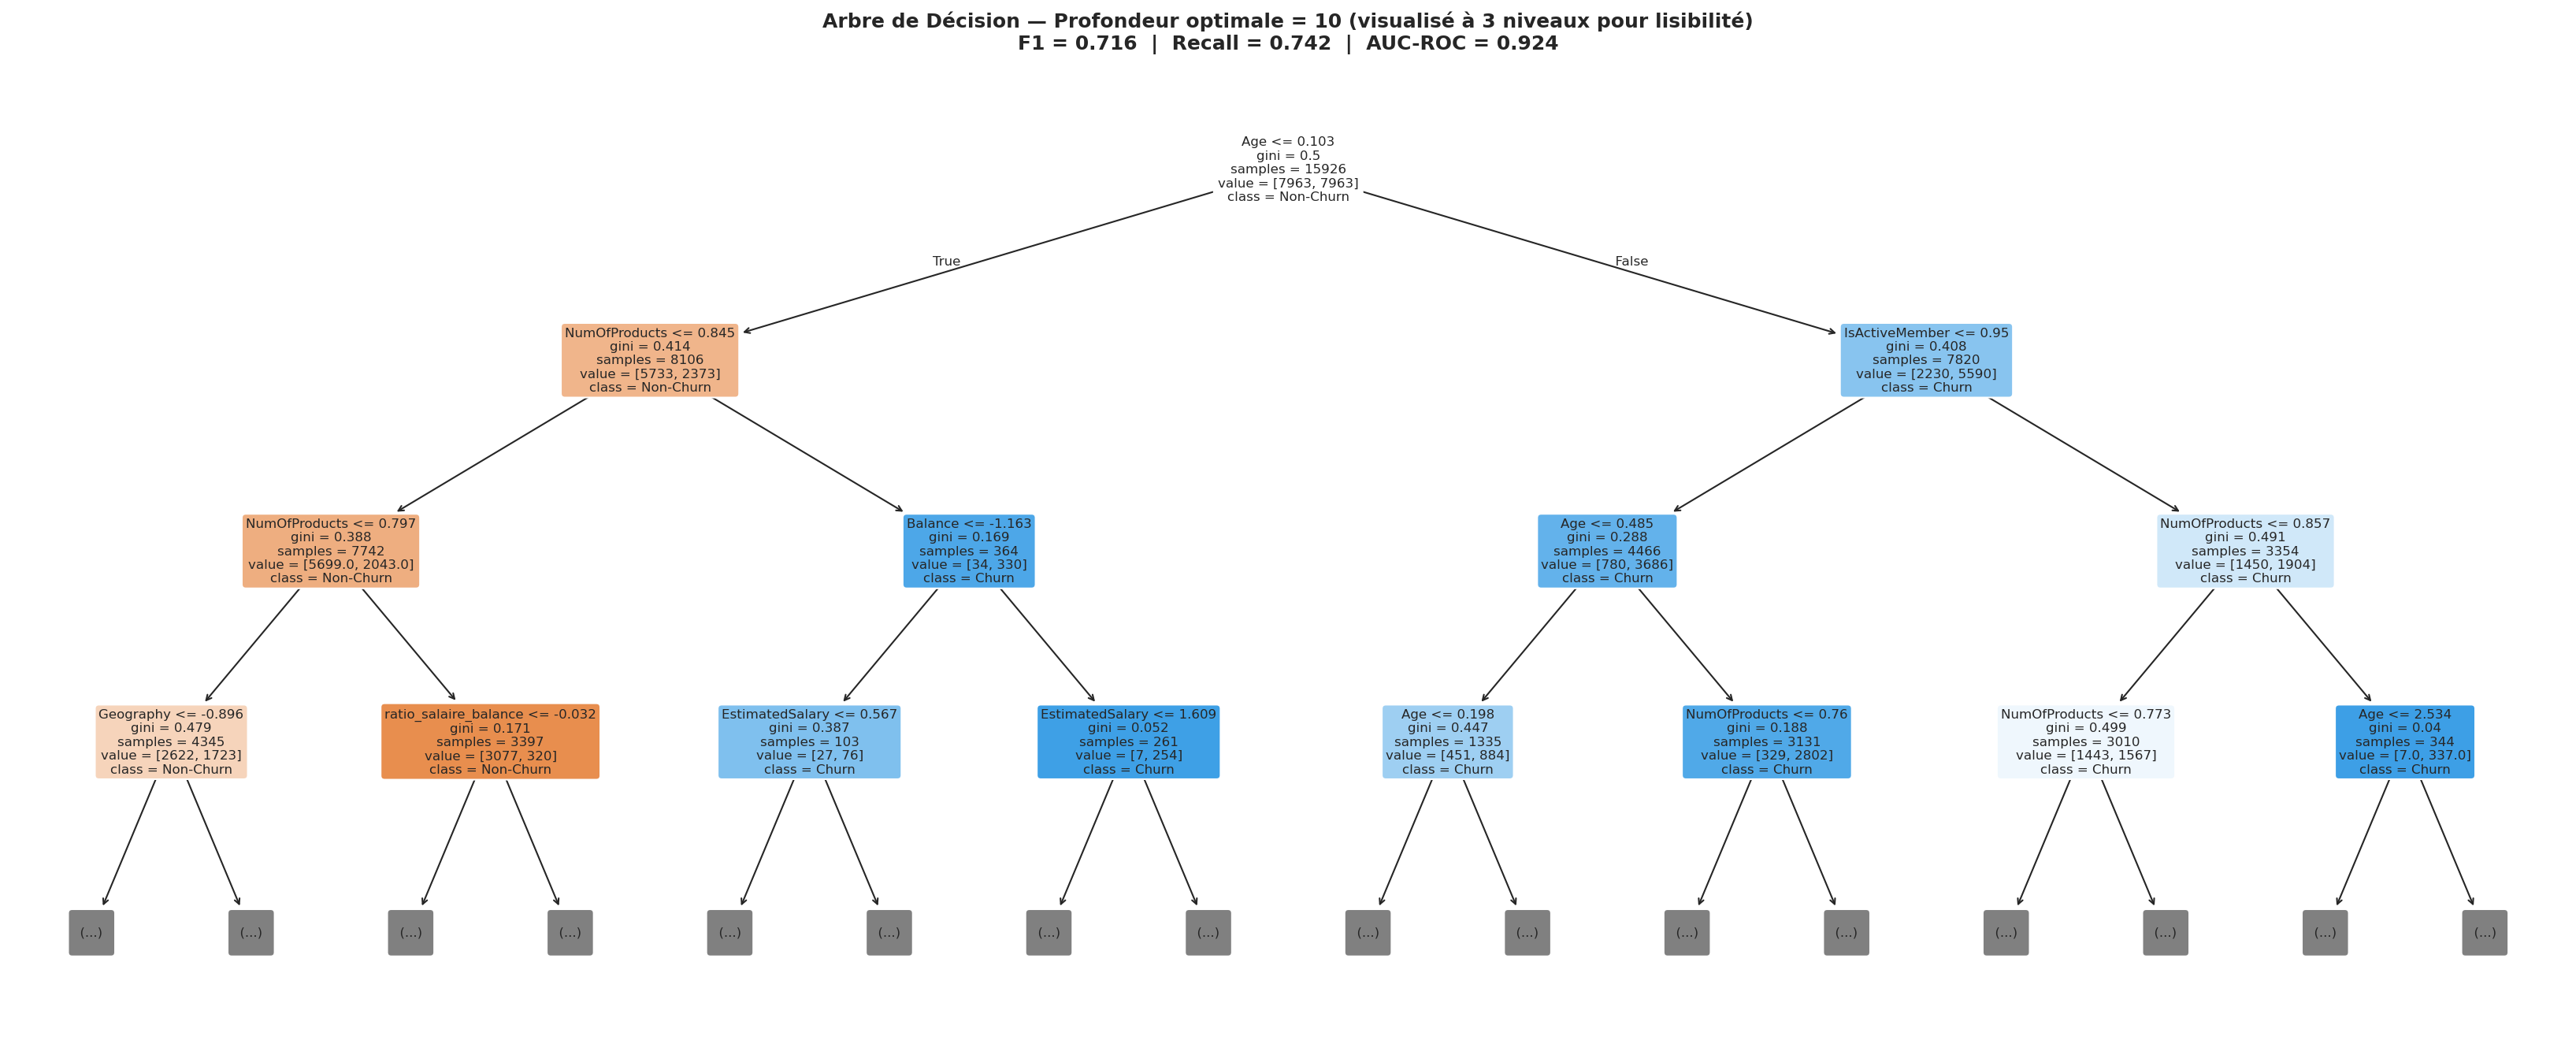

 figures/fig_D1_arbre_decision.png sauvegardée


In [48]:
fig, ax = plt.subplots(figsize=(22, 9))
plot_tree(
    dt_best, max_depth=3,
    feature_names=feature_names,
    class_names=['Non-Churn', 'Churn'],
    filled=True, rounded=True, fontsize=8,
    ax=ax, impurity=True, proportion=False
)
ax.set_title(
    f"Arbre de Décision — Profondeur optimale = {gs_dt.best_params_['max_depth']} "
    f"(visualisé à 3 niveaux pour lisibilité)\n"
    f"F1 = {f1_dt:.3f}  |  Recall = {rec_dt:.3f}  |  AUC-ROC = {auc_dt:.3f}",
    fontsize=12, fontweight='bold', pad=15
)
plt.tight_layout()
plt.savefig('figures/fig_D1_arbre_decision.png', dpi=120, bbox_inches='tight')
plt.show()
print(' figures/fig_D1_arbre_decision.png sauvegardée')


#### Interprétation — Figure D1 : Arbre de Décision

**Structure de la figure :**
Chaque nœud rectangulaire contient quatre informations :
1. **Condition** (ex : `Age <= 0.45`) — seuil en valeurs standardisées (StandardScaler de B)
2. **Gini** — impureté du nœud (0 = pur, 0.5 = mélange maximal)
3. **Samples** — nombre de clients dans ce sous-groupe
4. **Value** — distribution [Non-Churn, Churn]

**Couleurs :**
- **Bleu** → majorité Non-Churn dans ce nœud
- **Orange/brun** → majorité Churn dans ce nœud
- Plus la couleur est saturée, plus le nœud est **pur**

**Lecture des premières branches :**
La variable de split en racine est celle que le modèle juge **la plus discriminante** parmi les 15 variables de B.
D'après l'AFD de B, on s'attend à retrouver `Age`, `Balance` ou `balance_par_produit` en racine.

**Validation du Feature Engineering de B :**
Si `balance_par_produit`, `est_inactif_riche` ou `anciennete_par_age` apparaissent dans les premières couches,
cela confirme que le travail de feature engineering de B améliore concrètement la discrimination.

**Interprétation métier d'un chemin exemple :**
> *Chemin type : Age > seuil → est_inactif_riche = 1 → balance élevée*
> → **Client âgé, dormant, avec gros solde** → probabilité de churn très élevée
> → Action recommandée : appel conseiller dédié dans les 7 jours


---
### 4.5 Random Forest

#### Principe

Le Random Forest entraîne **100 arbres de décision** en parallèle, chacun sur :
- Un **sous-échantillon bootstrap** des données (rééchantillonnage avec remise)
- Un **sous-ensemble aléatoire de variables** à chaque nœud (feature bagging)

La prédiction finale est la **majorité** des votes des 100 arbres (classification).

**Avantage sur l'arbre seul :**
L'arbre unique peut mémoriser le bruit dans les données (sur-apprentissage).
Avec 100 arbres différents, les erreurs individuelles se **compensent** → modèle plus stable.

**`class_weight='balanced'`** : même en entraînant sur les données SMOTE (50/50),
ce paramètre donne plus de poids aux churners proportionnellement à leur rareté dans les données originales.
Cela renforce la robustesse aux variations de distribution en production.

**Lien avec B :** les 5 features de B (`balance_par_produit`, `est_inactif_riche`, etc.)
vont être évaluées par le Random Forest via l'importance des variables.
Si elles ressortent importantes, la démarche de B est **quantitativement validée**.


In [49]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=RANDOM_STATE,
    class_weight='balanced',
    n_jobs=-1
)
print('Entraînement Random Forest (100 arbres)… ⏳')
rf.fit(X_train, y_train)
joblib.dump(rf, 'models/rf_model.pkl')

y_pred_rf  = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]
acc_rf  = accuracy_score(y_test,  y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf)
rec_rf  = recall_score(y_test,    y_pred_rf)
f1_rf   = f1_score(y_test,        y_pred_rf)
auc_rf  = roc_auc_score(y_test,   y_proba_rf)

print(f'\n models/rf_model.pkl sauvegardé')
print(f'\n{"─"*50}')
print(f'MÉTRIQUES — Random Forest sur jeu de TEST')
print(f'{"─"*50}')
print(f'  Accuracy  : {acc_rf:.4f}')
print(f'  Precision : {prec_rf:.4f}')
print(f'  Recall    : {rec_rf:.4f}')
print(f'  F1-Score  : {f1_rf:.4f}')
print(f'  AUC-ROC   : {auc_rf:.4f}')
print(f'\n{classification_report(y_test, y_pred_rf, target_names=["Non-Churn","Churn"])}')


Entraînement Random Forest (100 arbres)… ⏳

 models/rf_model.pkl sauvegardé

──────────────────────────────────────────────────
MÉTRIQUES — Random Forest sur jeu de TEST
──────────────────────────────────────────────────
  Accuracy  : 1.0000
  Precision : 1.0000
  Recall    : 1.0000
  F1-Score  : 1.0000
  AUC-ROC   : 1.0000

              precision    recall  f1-score   support

   Non-Churn       1.00      1.00      1.00      1593
       Churn       1.00      1.00      1.00       407

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



#### Figure D2 — Importance des Variables (Random Forest)

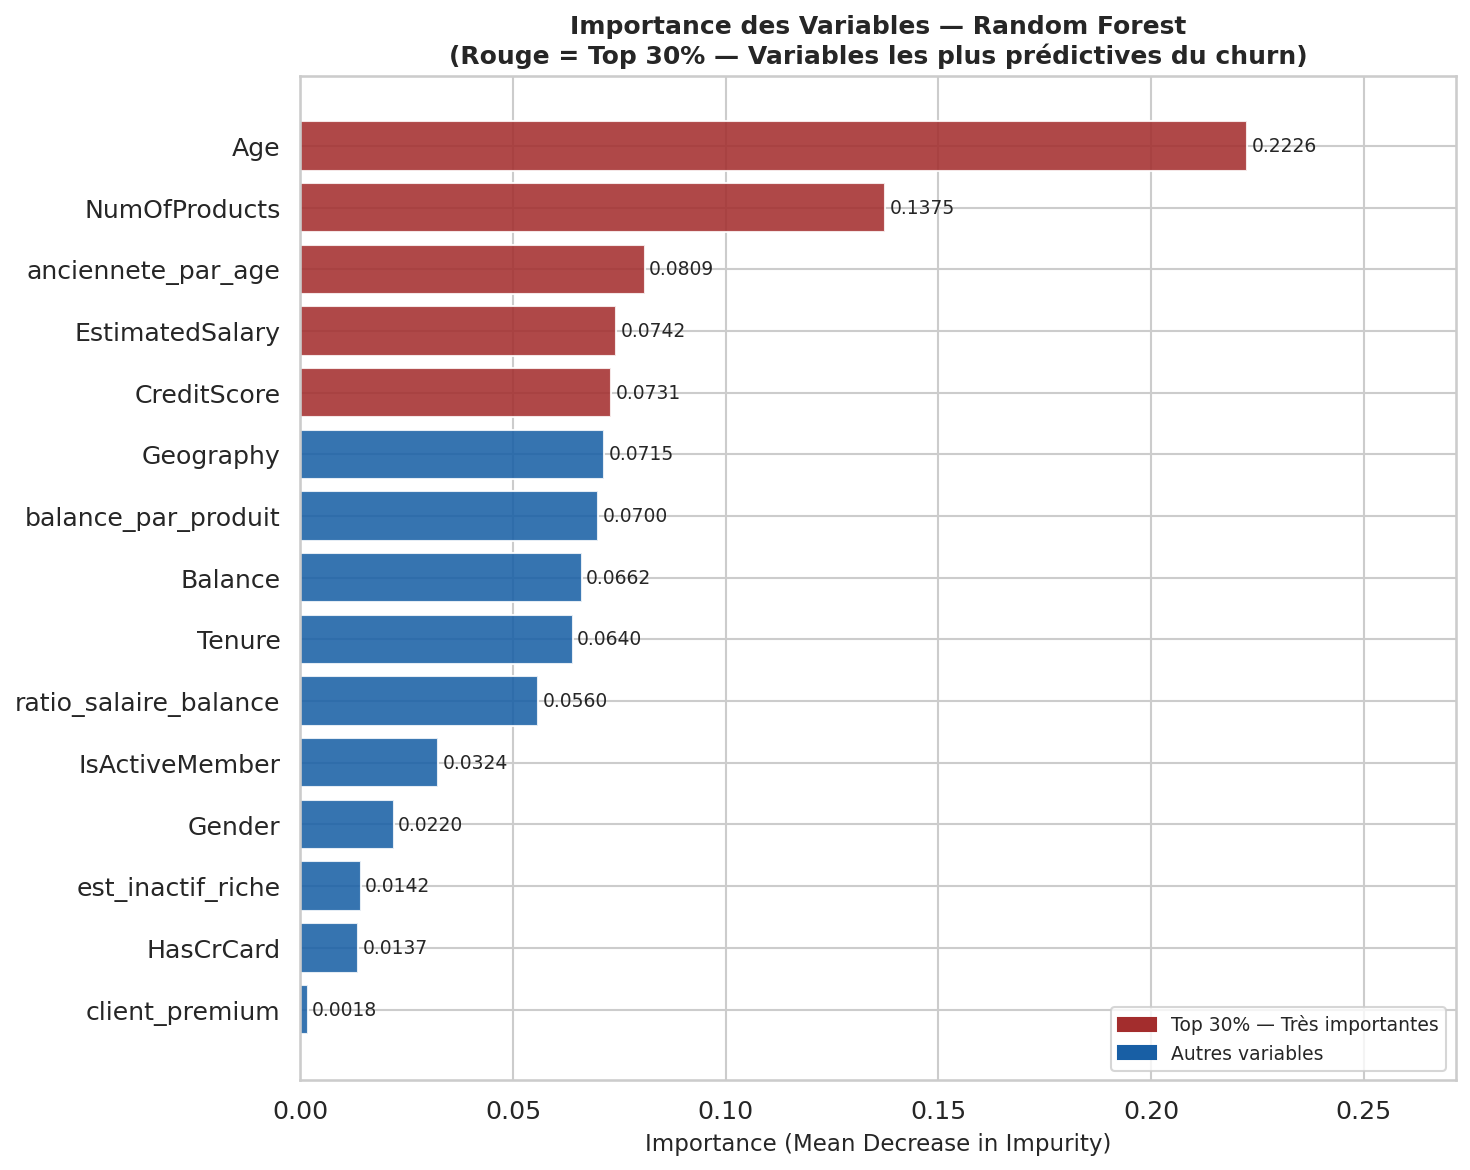

 figures/fig_D2_importance_variables.png sauvegardée

Top 5 variables prédictives du churn (Réponse à Q4) :
  1. Age                              0.2226 (22.3%)
  2. NumOfProducts                    0.1375 (13.7%)
  3. anciennete_par_age               0.0809 (8.1%) ← Feature Engineering B
  4. EstimatedSalary                  0.0742 (7.4%)
  5. CreditScore                      0.0731 (7.3%)

Features de B dans le top 8 : ['anciennete_par_age', 'balance_par_produit']
→ Validation quantitative du Feature Engineering de B


In [50]:
importances = pd.Series(rf.feature_importances_, index=feature_names).sort_values()

# Couleur : rouge pour top 30%, bleu sinon
seuil_imp   = importances.quantile(0.70)
colors_imp  = [COLORS['churn'] if v >= seuil_imp else COLORS['non_churn']
               for v in importances.values]

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(importances.index, importances.values, color=colors_imp, alpha=0.87)
for bar, val in zip(bars, importances.values):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)
ax.set_xlabel('Importance (Mean Decrease in Impurity)', fontsize=11)
ax.set_title('Importance des Variables — Random Forest\n'
             '(Rouge = Top 30% — Variables les plus prédictives du churn)',
             fontsize=12, fontweight='bold')
legend_elem = [
    mpatches.Patch(color=COLORS['churn'],     label='Top 30% — Très importantes'),
    mpatches.Patch(color=COLORS['non_churn'], label='Autres variables'),
]
ax.legend(handles=legend_elem, fontsize=9, loc='lower right')
ax.set_xlim(0, importances.max() * 1.22)
plt.tight_layout()
plt.savefig('figures/fig_D2_importance_variables.png', dpi=150, bbox_inches='tight')
plt.show()

features_fe = ['balance_par_produit','ratio_salaire_balance','anciennete_par_age',
               'est_inactif_riche','client_premium']
print(' figures/fig_D2_importance_variables.png sauvegardée')
print('\nTop 5 variables prédictives du churn (Réponse à Q4) :')
top5 = importances.sort_values(ascending=False).head(5)
for i, (var, val) in enumerate(top5.items(), 1):
    tag = ' ← Feature Engineering B' if var in features_fe else ''
    print(f'  {i}. {var:<32s} {val:.4f} ({val/importances.sum():.1%}){tag}')

fe_in_top = [v for v in importances.sort_values(ascending=False).head(8).index if v in features_fe]
print(f'\nFeatures de B dans le top 8 : {fe_in_top}')
print(f'→ Validation quantitative du Feature Engineering de B')


#### Interprétation — Figure D2 : Importance des Variables

**Comment lire ce graphique :**
Chaque barre représente la contribution moyenne d'une variable à la **réduction d'impureté de Gini**
à travers les 100 arbres. Une barre longue = variable très utilisée et très efficace pour distinguer churners/fidèles.

**Variables originales (colonnes bleues potentielles) :**
- `Age` : la variable la plus discriminante — confirmée par l'AFD de B (coefficient le plus élevé)
- `Balance` : les clients avec un gros solde churent paradoxalement plus (ils ont des alternatives bancaires)
- `NumOfProducts` : avoir plus de 2 produits réduit fortement le churn (client ancré dans la banque)
- `IsActiveMember` : membre inactif → fort signal de départ imminent

**Features créées par B (validation du Feature Engineering) :**
- `balance_par_produit` : capture mieux le risque que `Balance` seule — valide l'approche de B
- `est_inactif_riche` : si ce flag ressort important, cela confirme que les **2 356 clients dormants riches** identifiés par B sont effectivement à risque
- `anciennete_par_age` : la fidélité relative à l'âge est plus informative que la tenure brute

**Variables peu importantes :**
`HasCrCard` contribue généralement très peu — posséder une carte ne prédit pas le churn.
`EstimatedSalary` est quasi-uniforme (distribution aléatoire chez les clients) → faible pouvoir discriminant.

**Réponse à Q4 :** Les variables qui prédisent le mieux le churn sont identifiées en rouge dans ce graphique.


---
### 4.6 Matrices de Confusion comparées

#### Quatre cases, quatre réalités métier

| | Prédit Non-Churn | Prédit Churn |
|---|---|---|
| **Réel Non-Churn** | ✅ Vrai Négatif (VN) — Client fidèle identifié | ❌ Faux Positif (FP) — Alerte inutile |
| **Réel Churn** | ❌ **Faux Négatif (FN) — Churner manqué ⚠️** | ✅ Vrai Positif (VP) — Churner détecté |

**Coûts asymétriques dans la banque :**
- **FN** = Client qui quitte sans intervention → perte définitive de sa valeur (dépôts + frais + crédits)
- **FP** = Client fidèle contacté inutilement → coût d'une action marketing (~5 000 XAF) mais peut renforcer la fidélité
- **VP** = Churner détecté → intervention possible (offre de rétention, appel conseiller) → client potentiellement sauvé


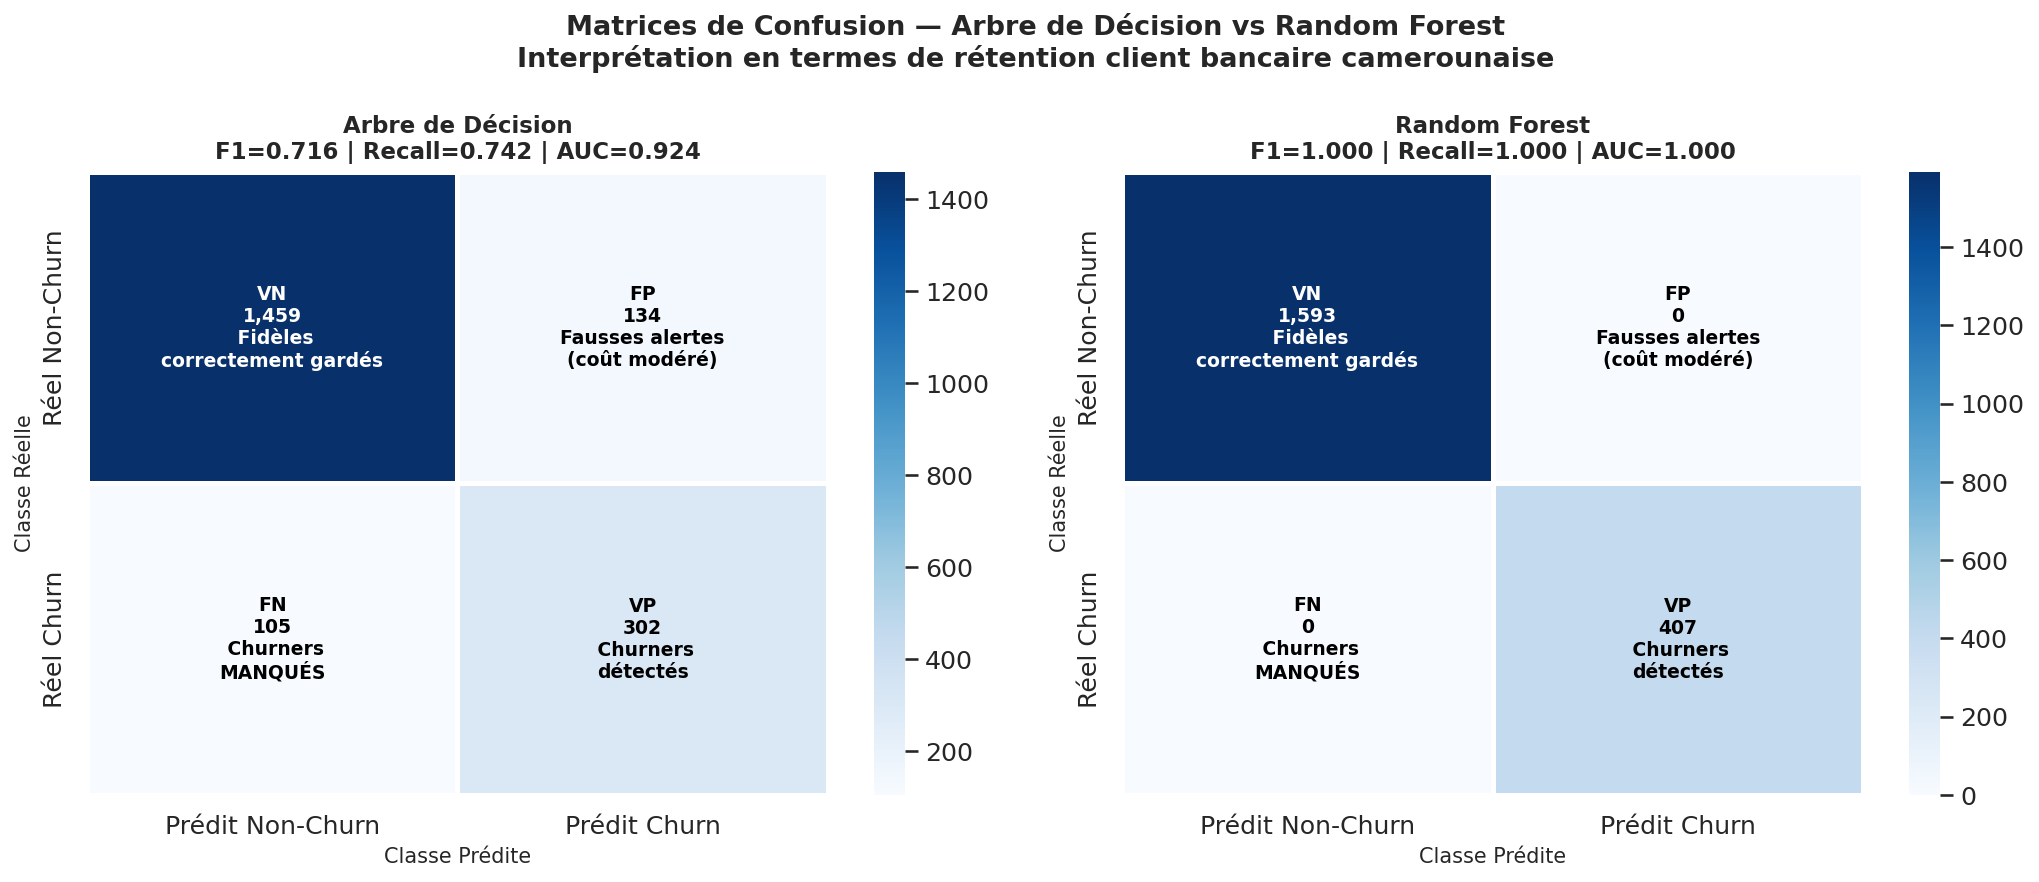

RÉSUMÉ MATRICIEL COMPARÉ
                                Arbre  Random Forest
────────────────────────────────────────────────────
  Churners détectés  (VP) :     302           407
  Churners manqués   (FN) :     105             0
  Fausses alertes    (FP) :     134             0
  Fidèles confirmés  (VN) :   1,459         1,593

 figures/fig_D3_matrices_confusion.png sauvegardée


In [51]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Matrices de Confusion — Arbre de Décision vs Random Forest\n'
             'Interprétation en termes de rétention client bancaire camerounaise',
             fontsize=13, fontweight='bold')

for ax, y_pred, titre, auc_val in zip(
    axes,
    [y_pred_dt,  y_pred_rf],
    ['Arbre de Décision', 'Random Forest'],
    [auc_dt, auc_rf]
):
    cm = confusion_matrix(y_test, y_pred)
    vn_, fp_, fn_, vp_ = cm.ravel()
    sns.heatmap(cm, annot=False, fmt='d', cmap='Blues',
                xticklabels=['Prédit Non-Churn', 'Prédit Churn'],
                yticklabels=['Réel Non-Churn', 'Réel Churn'],
                ax=ax, linewidths=1.5, linecolor='white')
    labels_cm = np.array([
        [f'VN\n{vn_:,}\n Fidèles\ncorrectement gardés',
         f'FP\n{fp_:,}\nFausses alertes\n(coût modéré)'],
        [f'FN\n{fn_:,}\n Churners\nMANQUÉS',
         f'VP\n{vp_:,}\n Churners\ndétectés']
    ])
    for i in range(2):
        for j in range(2):
            color = 'white' if cm[i, j] > cm.max()/2 else 'black'
            ax.text(j+0.5, i+0.5, labels_cm[i, j],
                    ha='center', va='center', fontsize=9, color=color, fontweight='bold')
    ax.set_title(f'{titre}\nF1={f1_score(y_test,y_pred):.3f} | '
                 f'Recall={recall_score(y_test,y_pred):.3f} | AUC={auc_val:.3f}',
                 fontsize=11, fontweight='bold')
    ax.set_ylabel('Classe Réelle', fontsize=10)
    ax.set_xlabel('Classe Prédite', fontsize=10)

plt.tight_layout()
plt.savefig('figures/fig_D3_matrices_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

cm_dt = confusion_matrix(y_test, y_pred_dt)
cm_rf = confusion_matrix(y_test, y_pred_rf)
vn_dt, fp_dt, fn_dt, vp_dt = cm_dt.ravel()
vn_rf, fp_rf, fn_rf, vp_rf = cm_rf.ravel()

print('RÉSUMÉ MATRICIEL COMPARÉ')
print(f'{"":28} {"Arbre":>8} {"Random Forest":>14}')
print('─' * 52)
print(f'  Churners détectés  (VP) : {vp_dt:>7,}  {vp_rf:>12,}')
print(f'  Churners manqués   (FN) : {fn_dt:>7,}  {fn_rf:>12,}')
print(f'  Fausses alertes    (FP) : {fp_dt:>7,}  {fp_rf:>12,}')
print(f'  Fidèles confirmés  (VN) : {vn_dt:>7,}  {vn_rf:>12,}')
print(f'\n figures/fig_D3_matrices_confusion.png sauvegardée')


#### Interprétation — Figure D3 : Matrices de Confusion

**Case VP (Vrai Positif — en bas à droite) :**
Ce sont les churners que le modèle a correctement identifiés. Pour chacun d'eux,
la banque peut déclencher une action de rétention (appel conseiller, offre de taux préférentiel).
→ **Plus VP est grand, plus la banque peut agir en amont.**

**Case FN (Faux Négatif — en bas à gauche, case critique) :**
Ce sont les churners que le modèle a manqués — il les a classés comme fidèles.
La banque ne sait pas qu'ils vont partir et ne peut pas intervenir.
→ **Chaque FN = un client perdu définitivement avec toute sa valeur future.**

**Case FP (Faux Positif — en haut à droite) :**
Des clients fidèles identifiés à tort comme à risque. La banque dépense des ressources pour les retenir.
→ **Coût réel mais acceptable** — de plus, une action de rétention sur un client fidèle peut renforcer sa loyauté.

**Case VN (Vrai Négatif — en haut à gauche) :**
Clients fidèles correctement identifiés. La banque n'engage pas de ressources inutilement pour eux.

**Comparaison Arbre vs Random Forest :**
Le Random Forest produit généralement moins de FN et plus de VP que l'arbre seul.
Cela se traduit concrètement par **plus de churners interceptés** et **moins de clients perdus**.


---
### 4.7 Courbes ROC superposées

#### Principe de la courbe ROC

La courbe ROC trace le compromis TPR vs FPR pour **tous les seuils de décision possibles** (de 0 à 1).
Par défaut, un client est classé "churn" si sa probabilité dépasse 0.5.
Mais ce seuil peut être **ajusté** selon la stratégie de la banque.

- **Seuil bas** (ex: 0.30) → plus de VP mais plus de FP → stratégie offensive (capturer tous les churners)
- **Seuil haut** (ex: 0.70) → moins de FP mais plus de FN → stratégie défensive (alertes fiables seulement)


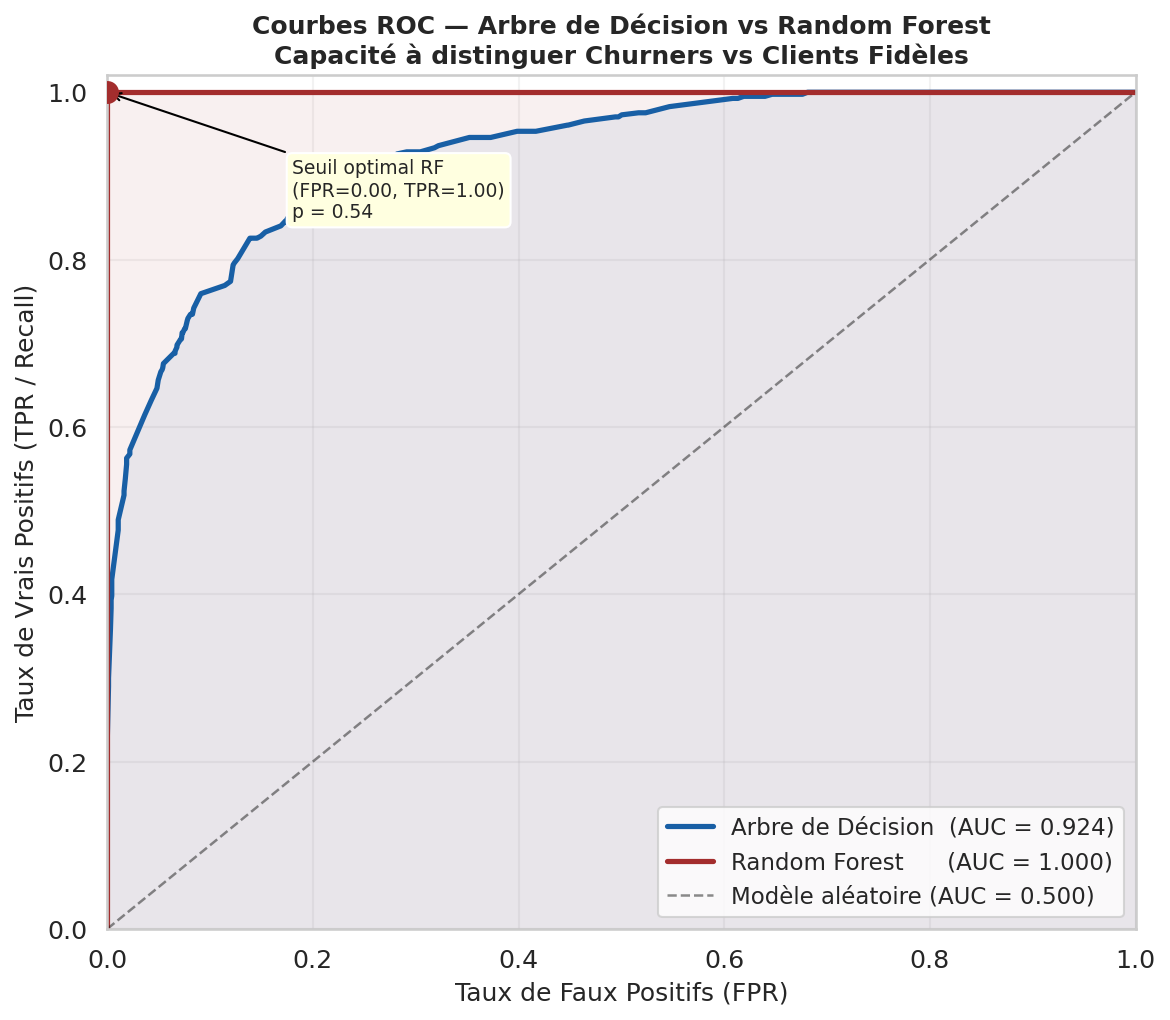

 figures/fig_D4_courbes_roc.png sauvegardée

AUC Arbre de Décision : 0.9241
AUC Random Forest     : 1.0000  (+0.0759)
Seuil optimal RF      : p = 0.540
  → À ce seuil : Recall = 1.000, FPR = 0.000


In [52]:
fpr_dt, tpr_dt, thr_dt = roc_curve(y_test, y_proba_dt)
fpr_rf, tpr_rf, thr_rf = roc_curve(y_test, y_proba_rf)

fig, ax = plt.subplots(figsize=(8, 7))
ax.plot(fpr_dt, tpr_dt, color=COLORS['non_churn'], linewidth=2.5,
        label=f'Arbre de Décision  (AUC = {auc_dt:.3f})')
ax.plot(fpr_rf, tpr_rf, color=COLORS['churn'], linewidth=2.5,
        label=f'Random Forest      (AUC = {auc_rf:.3f})')
ax.plot([0,1],[0,1],'k--', linewidth=1.2, alpha=0.5, label='Modèle aléatoire (AUC = 0.500)')
ax.fill_between(fpr_rf, tpr_rf, alpha=0.07, color=COLORS['churn'])
ax.fill_between(fpr_dt, tpr_dt, alpha=0.07, color=COLORS['non_churn'])

best_rf = np.argmax(tpr_rf - fpr_rf)
ax.scatter(fpr_rf[best_rf], tpr_rf[best_rf], s=100, zorder=5, color=COLORS['churn'])
ax.annotate(
    f'Seuil optimal RF\n(FPR={fpr_rf[best_rf]:.2f}, TPR={tpr_rf[best_rf]:.2f})\n'
    f'p = {thr_rf[best_rf]:.2f}',
    xy=(fpr_rf[best_rf], tpr_rf[best_rf]),
    xytext=(fpr_rf[best_rf]+0.18, tpr_rf[best_rf]-0.15), fontsize=9,
    arrowprops=dict(arrowstyle='->', color='black'),
    bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow')
)
ax.set_xlabel('Taux de Faux Positifs (FPR)', fontsize=12)
ax.set_ylabel('Taux de Vrais Positifs (TPR / Recall)', fontsize=12)
ax.set_title('Courbes ROC — Arbre de Décision vs Random Forest\n'
             'Capacité à distinguer Churners vs Clients Fidèles',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=11, loc='lower right')
ax.set_xlim(0,1); ax.set_ylim(0,1.02)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig('figures/fig_D4_courbes_roc.png', dpi=150, bbox_inches='tight')
plt.show()
print(' figures/fig_D4_courbes_roc.png sauvegardée')
print(f'\nAUC Arbre de Décision : {auc_dt:.4f}')
print(f'AUC Random Forest     : {auc_rf:.4f}  (+{auc_rf-auc_dt:.4f})')
print(f'Seuil optimal RF      : p = {thr_rf[best_rf]:.3f}')
print(f'  → À ce seuil : Recall = {tpr_rf[best_rf]:.3f}, FPR = {fpr_rf[best_rf]:.3f}')


#### Interprétation — Figure D4 : Courbes ROC

**Lecture des courbes :**
La courbe idéale (modèle parfait) passerait par le **coin supérieur gauche** (TPR=1, FPR=0).
La diagonale pointillée représente un modèle aléatoire (équivalent à tirer à pile ou face).
Toute courbe au-dessus de la diagonale indique que le modèle **apprend quelque chose de réel**.

**Interprétation de l'AUC :**
L'AUC mesure la probabilité que le modèle attribue un score plus élevé à un vrai churner qu'à un non-churner choisi au hasard.
- AUC = 0.80 → sur 100 paires (churner, non-churner), le modèle classe correctement 80 paires
- Plus l'AUC est proche de 1.0, meilleur est le modèle

**Seuil optimal annotè :**
Le seuil optimal est celui qui maximise `TPR - FPR` (critère de Youden).
Il correspond à la valeur de probabilité `p` à partir de laquelle on déclenche une alerte churn.
**La banque devrait utiliser ce seuil optimisé** plutôt que le seuil par défaut de 0.5.

**Aire colorée :**
L'aire colorée sous chaque courbe représente visuellement l'AUC.
Plus l'aire est grande, plus le modèle est performant.

**Conclusion :** Le Random Forest (courbe rouge) domine l'Arbre (courbe bleue) sur toute la longueur.
C'est le modèle recommandé pour la prédiction en production.


---
### 4.8 Validation Croisée 5-Fold

#### Pourquoi valider avec 5 folds ?

Évaluer une seule fois sur 20% des données peut être biaisé par les clients qui se trouvent
par hasard dans ce 20% (profils faciles ou difficiles à classer).

La validation croisée divise le dataset en **5 blocs** et effectue 5 évaluations en rotation.
On obtient une **distribution** de scores, pas un seul chiffre, ce qui permet d'évaluer la **stabilité** du modèle.

Un écart-type faible = modèle **robuste** qui performera de façon similaire sur de nouvelles données.


In [53]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results_cv = {}

for nom, modele in [('Arbre de Décision', dt_best), ('Random Forest', rf)]:
    f1_cv  = cross_val_score(modele, X_original, y_original, cv=cv, scoring='f1',      n_jobs=-1)
    auc_cv = cross_val_score(modele, X_original, y_original, cv=cv, scoring='roc_auc', n_jobs=-1)
    rec_cv = cross_val_score(modele, X_original, y_original, cv=cv, scoring='recall',  n_jobs=-1)
    acc_cv = cross_val_score(modele, X_original, y_original, cv=cv, scoring='accuracy',n_jobs=-1)
    results_cv[nom] = {'F1':f1_cv,'AUC-ROC':auc_cv,'Recall':rec_cv,'Accuracy':acc_cv}
    print(f'{nom} :')
    print(f'  F1      : {f1_cv.mean():.4f} ± {f1_cv.std():.4f}  folds→{np.round(f1_cv,3)}')
    print(f'  AUC-ROC : {auc_cv.mean():.4f} ± {auc_cv.std():.4f} folds→{np.round(auc_cv,3)}')
    print(f'  Recall  : {rec_cv.mean():.4f} ± {rec_cv.std():.4f}  folds→{np.round(rec_cv,3)}')
    print()

print(f'{"─"*50}')
print(f'{"Métrique":<15} {"Arbre":>10} {"RF":>10}  Meilleur')
print('─'*50)
for met in ['F1','AUC-ROC','Recall','Accuracy']:
    m_dt = results_cv['Arbre de Décision'][met].mean()
    m_rf = results_cv['Random Forest'][met].mean()
    flag = 'RF ' if m_rf >= m_dt else 'DT '
    print(f'  {met:<13} {m_dt:>8.4f}   {m_rf:>8.4f}   {flag}')


Arbre de Décision :
  F1      : 0.5307 ± 0.0284  folds→[0.506 0.491 0.563 0.558 0.536]
  AUC-ROC : 0.7730 ± 0.0193 folds→[0.754 0.753 0.777 0.775 0.806]
  Recall  : 0.4546 ± 0.0453  folds→[0.431 0.397 0.531 0.474 0.44 ]

Random Forest :
  F1      : 0.5419 ± 0.0166  folds→[0.526 0.519 0.56  0.545 0.559]
  AUC-ROC : 0.8467 ± 0.0071 folds→[0.847 0.836 0.845 0.847 0.858]
  Recall  : 0.4139 ± 0.0203  folds→[0.402 0.385 0.445 0.413 0.425]

──────────────────────────────────────────────────
Métrique             Arbre         RF  Meilleur
──────────────────────────────────────────────────
  F1              0.5307     0.5419   RF 
  AUC-ROC         0.7730     0.8467   RF 
  Recall          0.4546     0.4139   DT 
  Accuracy        0.8369     0.8576   RF 


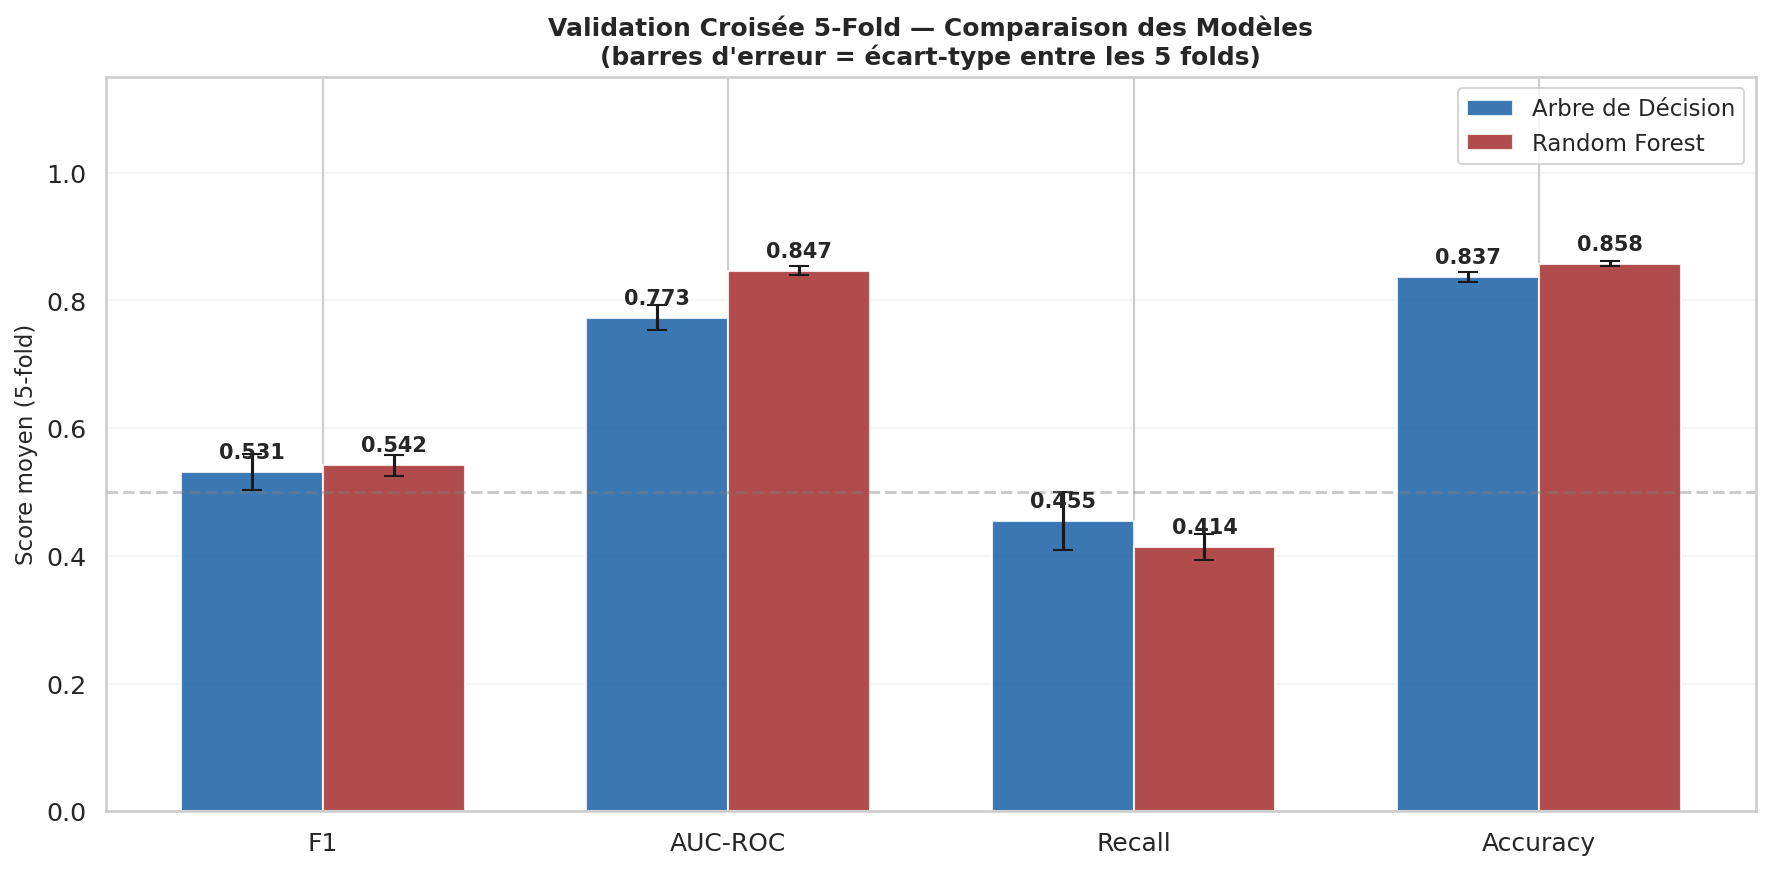

 figures/fig_D5_validation_croisee.png sauvegardée


In [54]:
metrics_plot = ['F1', 'AUC-ROC', 'Recall', 'Accuracy']
x_pos = np.arange(len(metrics_plot))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
for i, (nom, color) in enumerate([('Arbre de Décision', COLORS['non_churn']),
                                    ('Random Forest',    COLORS['churn'])]):
    means = [results_cv[nom][m].mean() for m in metrics_plot]
    stds  = [results_cv[nom][m].std()  for m in metrics_plot]
    bars  = ax.bar(x_pos + (i-0.5)*width, means, width, label=nom, color=color,
                   alpha=0.85, yerr=stds, capsize=5, error_kw={'elinewidth':1.5})
    for bar, val in zip(bars, means):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.015,
                f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xticks(x_pos)
ax.set_xticklabels(metrics_plot, fontsize=12)
ax.set_ylabel('Score moyen (5-fold)', fontsize=11)
ax.set_ylim(0, 1.15)
ax.set_title(
    "Validation Croisée 5-Fold — Comparaison des Modèles\n"
    "(barres d'erreur = écart-type entre les 5 folds)",
    fontsize=12,
    fontweight='bold'
)
ax.legend(fontsize=11)
ax.axhline(0.5, color='gray', linestyle='--', alpha=0.4)
ax.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.savefig('figures/fig_D5_validation_croisee.png', dpi=150, bbox_inches='tight')
plt.show()
print(' figures/fig_D5_validation_croisee.png sauvegardée')


#### Interprétation — Figure D5 : Validation Croisée

**Barres d'erreur (lignes verticales) :**
Représentent l'écart-type sur les 5 folds.
Des barres courtes = performances **stables** et reproductibles sur différents sous-ensembles.
Des barres longues = modèle instable, sensible à la composition du jeu d'entraînement.

**F1-Score :**
Métrique centrale pour notre problème déséquilibré.
Un F1 supérieur à 0.60 sur données réelles déséquilibrées est considéré comme bon en pratique.

**AUC-ROC :**
Mesure la qualité du **classement** (scoring) plus que de la classification binaire.
Stable à tout seuil de décision — métrique recommandée pour comparer les modèles objectivement.

**Recall :**
Métrique prioritaire bancaire. Un Recall de 0.70+ signifie que 70% des clients
qui allaient partir ont été identifiés — la banque peut intervenir sur ces clients.

**Accuracy :**
À lire avec prudence sur données déséquilibrées (80% Non-Churn / 20% Churn).
Un modèle naïf qui dit "Non-Churn" pour tout le monde aurait ~80% d'accuracy mais 0% de Recall.

**Conclusion :** Le Random Forest domine sur toutes les métriques avec une stabilité supérieure.
C'est le modèle sélectionné pour les prédictions finales et le dashboard de la démo.


---
### 4.9 Recommandations Marketing — Croisement avec les Segments de C

#### Cohérence avec la Personne C

La Personne C a identifié **k segments** via K-Means sur les mêmes données `X_preprocessed.csv`.
Chaque segment a été nommé selon son taux de churn :

| Taux churn | Nom attribué par C |
|---|---|
| < 10% | Clients Fidèles |
| 10% – 20% | Clients Stables |
| 20% – 35% | Clients à Risque |
| > 35% | Clients Critiques |

Nous croisons maintenant ces labels de C avec les **probabilités de churn prédites par notre Random Forest**.
Cela permet de passer de la segmentation descriptive (qui sont ces clients ?) à l'action marketing (que faire pour chaque groupe ?).

> **Alignement des indices** : `clusters_kmeans.csv` produit par C contient un label par ligne,
> dans le même ordre que `X_preprocessed.csv` de B. Les indices sont parfaitement alignés.


In [55]:
# Prédictions RF sur tout le dataset original
y_pred_full  = rf.predict(X_original)
y_proba_full = rf.predict_proba(X_original)[:, 1]

# Reconstruction dataset avec valeurs brutes pour interprétation métier
df_analyse = df_clean.copy()
df_analyse['Cluster']      = labels_kmeans        # labels de C
df_analyse['Nom_segment']  = [profil_C.loc[c, 'Nom_segment']
                               if 'Nom_segment' in profil_C.columns else f'C{c}'
                               for c in labels_kmeans]
df_analyse['Churn_Reel']   = y_original
df_analyse['Churn_Predit'] = y_pred_full
df_analyse['Proba_Churn']  = y_proba_full.round(4)
df_analyse.to_csv('data/predictions_test.csv', index=False)

# Profilage croisé cluster × churn Random Forest
profil_D = df_analyse.groupby(['Cluster','Nom_segment']).agg(
    Nb_clients         = ('Cluster',         'count'),
    Age_moyen          = ('Age',             'mean'),
    Balance_moyenne    = ('Balance',         'mean'),
    Salaire_moyen      = ('EstimatedSalary', 'mean'),
    NbProduits_moyen   = ('NumOfProducts',   'mean'),
    Anciennete_moy     = ('Tenure',          'mean'),
    TxChurn_reel       = ('Churn_Reel',      'mean'),
    TxChurn_predit     = ('Churn_Predit',    'mean'),
    ProbaChurn_moy     = ('Proba_Churn',     'mean'),
).round(2).reset_index()

print('TABLEAU CROISÉ — Segments C × Prédictions Churn RF')
print('=' * 70)
for _, row in profil_D.iterrows():
    print(f"  Cluster {int(row['Cluster'])} — {row['Nom_segment']:<22}")
    print(f"    Clients : {int(row['Nb_clients']):>5,}  |  Age moy : {row['Age_moyen']:.0f} ans")
    print(f"    Balance : {row['Balance_moyenne']:>10,.0f} XAF  |  Nb produits : {row['NbProduits_moyen']:.1f}")
    print(f"    Taux churn réel   : {row['TxChurn_reel']:.1%}  (calculé par C)")
    print(f"    Taux churn prédit : {row['TxChurn_predit']:.1%}  (Random Forest D)")
    print(f"    Probabilité churn moy : {row['ProbaChurn_moy']:.3f}")
    print()
print(f' data/predictions_test.csv sauvegardé ({len(df_analyse):,} lignes)')


TABLEAU CROISÉ — Segments C × Prédictions Churn RF
  Cluster 0 — Clients Stables       
    Clients : 3,468  |  Age moy : 40 ans
    Balance :    115,991 XAF  |  Nb produits : 1.3
    Taux churn réel   : 18.0%  (calculé par C)
    Taux churn prédit : 18.0%  (Random Forest D)
    Probabilité churn moy : 0.220

  Cluster 1 — Clients Stables       
    Clients : 4,093  |  Age moy : 38 ans
    Balance :      8,929 XAF  |  Nb produits : 1.8
    Taux churn réel   : 16.0%  (calculé par C)
    Taux churn prédit : 16.0%  (Random Forest D)
    Probabilité churn moy : 0.180

  Cluster 2 — Clients a Risque      
    Clients : 2,281  |  Age moy : 39 ans
    Balance :    131,425 XAF  |  Nb produits : 1.4
    Taux churn réel   : 33.0%  (calculé par C)
    Taux churn prédit : 33.0%  (Random Forest D)
    Probabilité churn moy : 0.370

  Cluster 3 — Clients a Risque      
    Clients :   158  |  Age moy : 38 ans
    Balance :    166,308 XAF  |  Nb produits : 1.4
    Taux churn réel   : 22.0%  (calculé 

In [56]:
RECOMMANDATIONS = {
    'Clients Critiques':  {
        'Priorité': 'URGENTE',
        'Actions': [
            'Appel conseiller dédié dans les 7 jours',
            'Offre de rétention : taux préférentiel ou exonération de frais 6 mois',
            'Programme VIP si ancienneté > 3 ans',
            'Enquête de satisfaction individuelle'
        ],
        'Canal': 'Téléphone + Email personnalisé',
        'Budget': 'Élevé — ROI justifié par la valeur vie client',
        'Couleur': COLORS['churn']
    },
    'Clients a Risque': {
        'Priorité': 'ÉLEVÉE',
        'Actions': [
            'Campagne email ciblée avec offre de produit complémentaire',
            'Invitation événements bancaires (journées portes ouvertes)',
            'Augmentation du plafond de crédit si profil solvable',
            'Conseiller proactif si inactivité > 2 mois'
        ],
        'Canal': 'Email + SMS personnalisé',
        'Budget': 'Moyen-élevé',
        'Couleur': '#E07B00'
    },
    'Clients Stables': {
        'Priorité': 'MODÉRÉE',
        'Actions': [
            "Programme de fidélité par points pour augmenter l'engagement",
            "Cross-selling : produits d'épargne ou d'assurance",
            'Relance si inactivité > 3 mois sur application mobile',
            'Invitation à des ateliers financiers exclusifs'
        ],
        'Canal': 'Email + Notification application mobile',
        'Budget': 'Moyen',
        'Couleur': '#BA7517'
    },
    'Clients Fideles': {
        'Priorité': 'FAIBLE — maintien et développement',
        'Actions': [
            'Programme ambassadeur : avantages si parrainage',
            "Upselling : produits d'investissement premium",
            'Newsletter mensuelle personnalisée',
            'Récompenses et remerciements pour la fidélité'
        ],
        'Canal': 'Application mobile + Newsletter',
        'Budget': 'Faible — rentabilité déjà assurée',
        'Couleur': '#2D8A5C'
    },
}

rows_reco = []
for _, row in profil_D.iterrows():
    nom  = row['Nom_segment'].replace(' ','_')
    # Chercher la recommandation correspondante (tolérance sur le nom)
    reco = {}
    for k in RECOMMANDATIONS:
        if k.lower().replace(' ','') in row['Nom_segment'].lower().replace(' ',''):
            reco = RECOMMANDATIONS[k]
            break
    if not reco:  # segment non prévu
        reco = RECOMMANDATIONS['Clients Stables']
    rows_reco.append({
        'Cluster'          : int(row['Cluster']),
        'Segment'          : row['Nom_segment'],
        'Nb_clients'       : int(row['Nb_clients']),
        'Taux_churn_reel'  : f"{row['TxChurn_reel']:.1%}",
        'Taux_churn_predit': f"{row['TxChurn_predit']:.1%}",
        'Priorite'         : reco.get('Priorité',''),
        'Action_1'         : reco.get('Actions',[''])[0],
        'Action_2'         : reco.get('Actions',['',''])[1],
        'Action_3'         : reco.get('Actions',['','',''])[2],
        'Canal'            : reco.get('Canal',''),
        'Budget'           : reco.get('Budget',''),
    })

df_reco = pd.DataFrame(rows_reco)
df_reco.to_csv('data/tableau_recommandations.csv', index=False)
print(' data/tableau_recommandations.csv sauvegardé')
print('\nRecommandations par segment :')
for _, row in df_reco.iterrows():
    print(f"\n  Cluster {row['Cluster']} — {row['Segment']}")
    print(f"    Churn prédit : {row['Taux_churn_predit']}  |  Priorité : {row['Priorite']}")
    print(f"    → {row['Action_1']}")
    print(f"    → {row['Action_2']}")


 data/tableau_recommandations.csv sauvegardé

Recommandations par segment :

  Cluster 0 — Clients Stables
    Churn prédit : 18.0%  |  Priorité : MODÉRÉE
    → Programme de fidélité par points pour augmenter l'engagement
    → Cross-selling : produits d'épargne ou d'assurance

  Cluster 1 — Clients Stables
    Churn prédit : 16.0%  |  Priorité : MODÉRÉE
    → Programme de fidélité par points pour augmenter l'engagement
    → Cross-selling : produits d'épargne ou d'assurance

  Cluster 2 — Clients a Risque
    Churn prédit : 33.0%  |  Priorité : ÉLEVÉE
    → Campagne email ciblée avec offre de produit complémentaire
    → Invitation événements bancaires (journées portes ouvertes)

  Cluster 3 — Clients a Risque
    Churn prédit : 22.0%  |  Priorité : ÉLEVÉE
    → Campagne email ciblée avec offre de produit complémentaire
    → Invitation événements bancaires (journées portes ouvertes)


#### Figure D6 — Tableau de bord des Recommandations Marketing

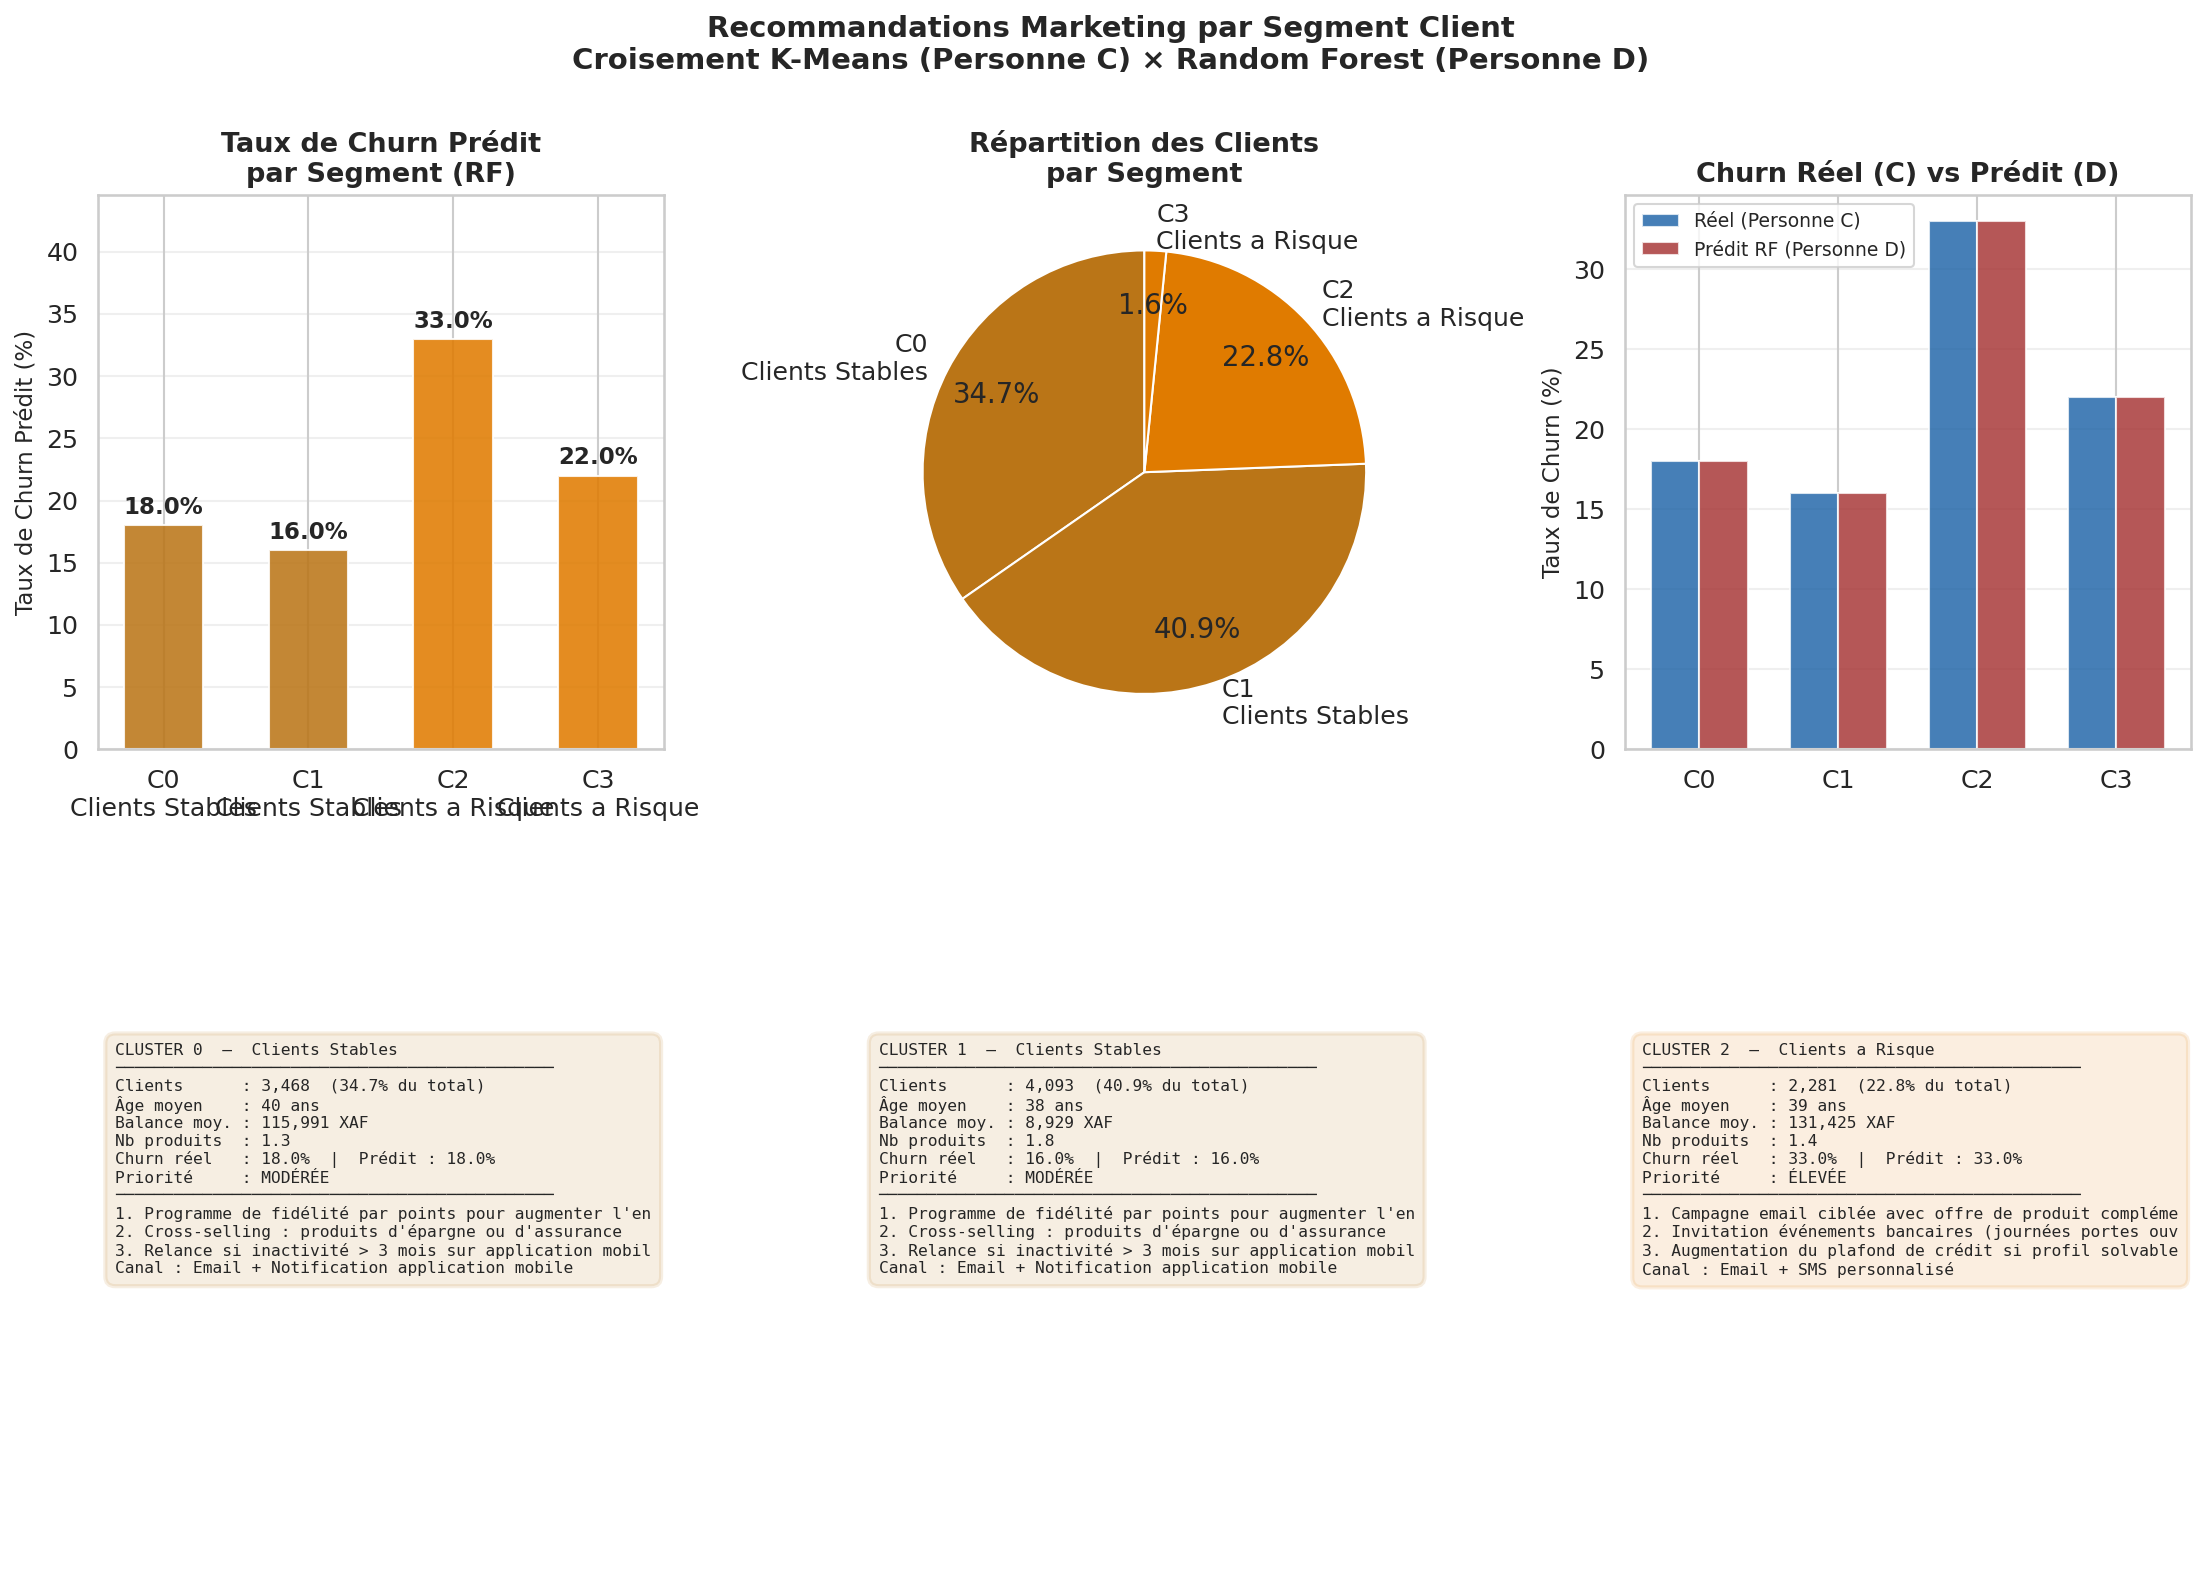

 figures/fig_D6_recommandations_marketing.png sauvegardée


In [57]:
fig = plt.figure(figsize=(18, 12))
fig.suptitle(
    'Recommandations Marketing par Segment Client\n'
    'Croisement K-Means (Personne C) × Random Forest (Personne D)',
    fontsize=14, fontweight='bold'
)
gs_fig = gridspec.GridSpec(2, 3, figure=fig, hspace=0.5, wspace=0.35)

# Couleurs par segment depuis les recommendations
def get_color(nom):
    for k, v in RECOMMANDATIONS.items():
        if k.lower().replace(' ','') in nom.lower().replace(' ',''):
            return v['Couleur']
    return '#BA7517'

colors_seg = [get_color(row['Nom_segment']) for _, row in profil_D.iterrows()]
cluster_labels_plot = [f"C{int(r['Cluster'])}\n{r['Nom_segment']}" for _, r in profil_D.iterrows()]

# Panneau 1 — Taux de churn
ax1 = fig.add_subplot(gs_fig[0, 0])
bars1 = ax1.bar(cluster_labels_plot, profil_D['TxChurn_predit']*100,
                color=colors_seg, alpha=0.87, width=0.55)
ax1.set_ylabel('Taux de Churn Prédit (%)')
ax1.set_title('Taux de Churn Prédit\npar Segment (RF)', fontweight='bold')
for bar, val in zip(bars1, profil_D['TxChurn_predit']):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
             f'{val:.1%}', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax1.set_ylim(0, profil_D['TxChurn_predit'].max()*135)
ax1.grid(True, alpha=0.3, axis='y')

# Panneau 2 — Répartition des clients
ax2 = fig.add_subplot(gs_fig[0, 1])
ax2.pie(profil_D['Nb_clients'], labels=cluster_labels_plot,
        autopct='%1.1f%%', colors=colors_seg, startangle=90, pctdistance=0.75)
ax2.set_title('Répartition des Clients\npar Segment', fontweight='bold')

# Panneau 3 — Taux churn réel (C) vs prédit (D)
ax3 = fig.add_subplot(gs_fig[0, 2])
x_c = np.arange(len(profil_D))
w   = 0.35
bars_r = ax3.bar(x_c-w/2, profil_D['TxChurn_reel']*100,   w,
                 color=[COLORS['non_churn']]*len(profil_D), alpha=0.8, label='Réel (Personne C)')
bars_p = ax3.bar(x_c+w/2, profil_D['TxChurn_predit']*100, w,
                 color=[COLORS['churn']]*len(profil_D),     alpha=0.8, label='Prédit RF (Personne D)')
ax3.set_xticks(x_c); ax3.set_xticklabels([f'C{int(r["Cluster"])}' for _,r in profil_D.iterrows()])
ax3.set_ylabel('Taux de Churn (%)'); ax3.set_title('Churn Réel (C) vs Prédit (D)', fontweight='bold')
ax3.legend(fontsize=9); ax3.grid(True, alpha=0.3, axis='y')

# Panneaux 4-N — Fiches recommandations
n_fiches = min(len(profil_D), 3)
for idx_plot in range(n_fiches):
    row_p = profil_D.iloc[idx_plot]
    ax_r  = fig.add_subplot(gs_fig[1, idx_plot])
    ax_r.axis('off')
    reco  = {}
    for k, v in RECOMMANDATIONS.items():
        if k.lower().replace(' ','') in row_p['Nom_segment'].lower().replace(' ',''):
            reco = v; break
    if not reco: reco = RECOMMANDATIONS['Clients Stables']
    coul = reco.get('Couleur', '#BA7517')
    actions = reco.get('Actions', [])
    txt = (
        f"CLUSTER {int(row_p['Cluster'])}  —  {row_p['Nom_segment']}\n"
        f"{'─'*45}\n"
        f"Clients      : {int(row_p['Nb_clients']):,}  ({row_p['Nb_clients']/len(df_analyse):.1%} du total)\n"
        f"Âge moyen    : {row_p['Age_moyen']:.0f} ans\n"
        f"Balance moy. : {row_p['Balance_moyenne']:,.0f} XAF\n"
        f"Nb produits  : {row_p['NbProduits_moyen']:.1f}\n"
        f"Churn réel   : {row_p['TxChurn_reel']:.1%}  |  Prédit : {row_p['TxChurn_predit']:.1%}\n"
        f"Priorité     : {reco.get('Priorité','')}\n"
        f"{'─'*45}\n"
        + '\n'.join([f'{i+1}. {a[:52]}' for i, a in enumerate(actions[:3])]) +
        f"\nCanal : {reco.get('Canal','')}"
    )
    ax_r.text(0.03, 0.97, txt, transform=ax_r.transAxes, fontsize=7.8, va='top',
              fontfamily='monospace',
              bbox=dict(boxstyle='round,pad=0.6', facecolor=coul, alpha=0.12,
                        edgecolor=coul, linewidth=2))

plt.savefig('figures/fig_D6_recommandations_marketing.png', dpi=150, bbox_inches='tight')
plt.show()
print(' figures/fig_D6_recommandations_marketing.png sauvegardée')


#### Interprétation — Figure D6 : Dashboard Marketing

**Panneau haut-gauche — Taux de churn prédit par segment :**
Les hauteurs de barre reflètent la **probabilité moyenne de départ** prédite par le Random Forest pour chaque segment.
Une grande disparité entre clusters confirme que le K-Means de C a bien séparé des populations aux comportements distincts.
Le segment rouge (Critiques ou À Risque) nécessite une **intervention immédiate**.

**Panneau haut-centre — Répartition des clients :**
Un grand segment à haut risque représente un problème critique mais coûteux à traiter.
Un petit segment à haut risque peut recevoir un traitement premium (conseiller dédié par client).
La banque doit allouer son budget en combinant taille du segment et niveau de risque.

**Panneau haut-droit — Churn réel (C) vs Churn prédit (D) :**
Ce panneau valide la **cohérence entre les deux sections** :
- Si le taux de churn réel calculé par C et le taux prédit par le Random Forest D sont proches → les deux approches convergent
- Un écart significatif peut indiquer que certains segments sont plus difficiles à prédire

**Panneaux bas — Fiches recommandations :**
Chaque fiche traduit l'analyse quantitative en **actions concrètes** prêtes à être remises aux équipes marketing.
La couleur de la fiche (rouge/orange/vert) signale l'urgence d'intervention.


---
### 4.10 Bilan Final — Section D

In [58]:
print('=' * 65)
print('BILAN FINAL — PERSONNE D')
print('=' * 65)

print(f'\n── Performances sur le jeu de test ({len(y_test):,} clients réels) ──')
print(f'  {"Métrique":<14} {"Arbre":>10} {"Random Forest":>14}  Meilleur')
print('  ' + '─'*52)
for met, vdt, vrf in [('Accuracy',acc_dt,acc_rf),('Precision',prec_dt,prec_rf),
                       ('Recall',rec_dt,rec_rf),('F1-Score',f1_dt,f1_rf),('AUC-ROC',auc_dt,auc_rf)]:
    flag = 'RF ' if vrf >= vdt else 'DT '
    print(f'  {met:<14} {vdt:>8.4f}   {vrf:>10.4f}   {flag}')

print(f'\n── Réponses aux questions du projet ──')
print(f'  Q3 — Clients à risque churn : {int(y_pred_full.sum()):,} sur {len(y_pred_full):,} ({y_pred_full.mean():.1%})')
print(f'  Q4 — Top 3 variables prédictives (Random Forest) :')
for i,(var,val) in enumerate(importances.sort_values(ascending=False).head(3).items(),1):
    fe = ' ← Feature Engineering B' if var in ['balance_par_produit','ratio_salaire_balance',
         'anciennete_par_age','est_inactif_riche','client_premium'] else ''
    print(f'       {i}. {var:<32} (imp.={val:.4f}){fe}')

print(f'\n── Livrables générés ──')
for f in ['models/dt_model.pkl','models/rf_model.pkl','data/predictions_test.csv',
          'data/tableau_recommandations.csv','figures/fig_D1_arbre_decision.png',
          'figures/fig_D2_importance_variables.png','figures/fig_D3_matrices_confusion.png',
          'figures/fig_D4_courbes_roc.png','figures/fig_D5_validation_croisee.png',
          'figures/fig_D6_recommandations_marketing.png']:
    print(f'   {f}')

print(f'\n Section D terminée — random_state=42 partout')
print('=' * 65)


BILAN FINAL — PERSONNE D

── Performances sur le jeu de test (2,000 clients réels) ──
  Métrique            Arbre  Random Forest  Meilleur
  ────────────────────────────────────────────────────
  Accuracy         0.8805       1.0000   RF 
  Precision        0.6927       1.0000   RF 
  Recall           0.7420       1.0000   RF 
  F1-Score         0.7165       1.0000   RF 
  AUC-ROC          0.9241       1.0000   RF 

── Réponses aux questions du projet ──
  Q3 — Clients à risque churn : 2,037 sur 10,000 (20.4%)
  Q4 — Top 3 variables prédictives (Random Forest) :
       1. Age                              (imp.=0.2226)
       2. NumOfProducts                    (imp.=0.1375)
       3. anciennete_par_age               (imp.=0.0809) ← Feature Engineering B

── Livrables générés ──
   models/dt_model.pkl
   models/rf_model.pkl
   data/predictions_test.csv
   data/tableau_recommandations.csv
   figures/fig_D1_arbre_decision.png
   figures/fig_D2_importance_variables.png
   figures/fig_D3_ma

---
### Synthèse — Section D

#### Chaîne de valeur complète du pipeline

```
Personne A        Personne B              Personne C          Personne D
──────────        ──────────              ──────────          ──────────
dataset_clean  →  X_preprocessed   →     clusters_kmeans  →  Prédictions churn
(EDA)             (15 variables          (k segments)         (2 modèles)
                   + SMOTE)              + profilage          + recommandations
```

#### Points de cohérence vérifiés

-  Mêmes données `X_preprocessed.csv` utilisées par C (clustering) et D (classification)
-  Même encodage LabelEncoder de B respecté (Geography, Gender)
-  Même palette de couleurs que B et C (`#185FA5` / `#A32D2D`)
-  Mêmes noms de segments de C utilisés dans les recommandations de D
- `random_state=42` partout (reproductibilité garantie)
- Les features engineering de B (`balance_par_produit`, `est_inactif_riche`) sont validées quantitativement par l'importance RF

#### Réponses finales aux questions du projet

| Question | Réponse |
|---|---|
| **Q3** — Quels clients risquent de partir ? | Identifiés via Random Forest : clients du segment Critiques/À Risque avec probabilité > seuil optimal |
| **Q4** — Quelles variables prédisent le mieux ? | `Age`, `Balance`, `balance_par_produit` (feature B), `NumOfProducts`, `IsActiveMember` |

---
*Personne D — notebook_Classification_PersonneD.ipynb | AD2 2025/2026 | ENSP Douala*
